/tmp/ipykernel_3672977/2093770888.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


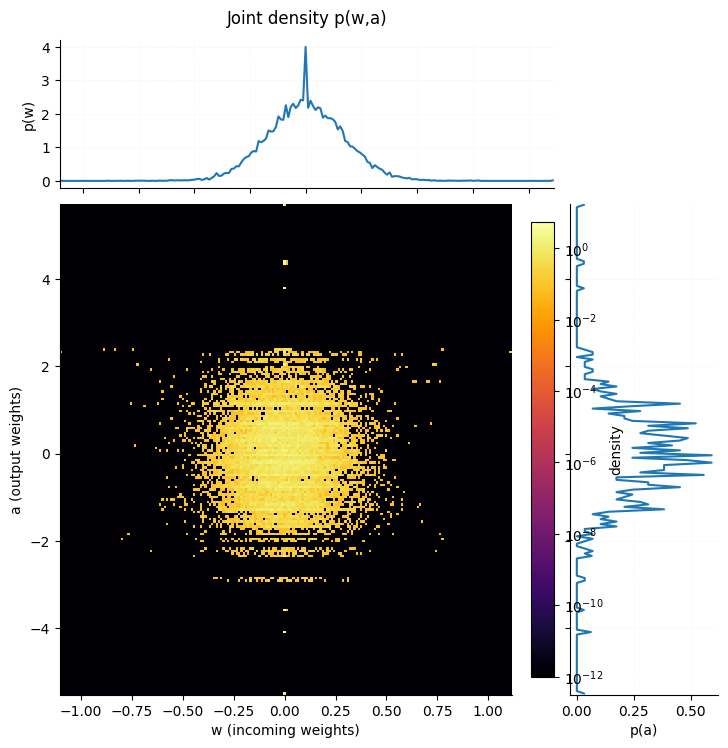

In [1]:
# %% 2D heatmap of p(w, a) with marginal projections (Inferno colormap)
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
from typing import Optional, Tuple

def _get_tensor_from_state_dict(sd, key_name: str):
    """
    Robustly fetch a tensor named `key_name` from a state_dict.
    Handles possible prefixes like 'module.' or nested keys.
    """
    if key_name in sd:
        return sd[key_name]
    # try suffix match (e.g. 'module.w', 'model.w')
    for k in sd.keys():
        if k.endswith(f".{key_name}") or k == key_name:
            return sd[k]
    raise KeyError(f"Could not find '{key_name}' in the provided state_dict keys: {list(sd.keys())[:10]}...")

def load_w_a_pairs(model_path: str, max_pairs: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
    """
    Loads a saved TwoLayerNet state_dict (.pt) and returns flattened pairs (w_ki, a_i).
    For each neuron i, we pair a_i with every incoming weight w_{k,i}, producing d*N pairs.

    Args:
        model_path: path to a .pt file saved from model.state_dict().
        max_pairs: optional cap (subsample without replacement) for extremely large models.

    Returns:
        w_vals (np.ndarray), a_vals (np.ndarray) of equal length.
    """
    sd = torch.load(model_path, map_location="cpu")
    if not isinstance(sd, dict):
        raise ValueError("The loaded file doesn't look like a state_dict dict. "
                         "Make sure you saved with model.state_dict().")

    w = _get_tensor_from_state_dict(sd, "w").detach().cpu().numpy()   # shape (d, N)
    a = _get_tensor_from_state_dict(sd, "a").detach().cpu().numpy()   # shape (N, 1) or (N,)

    # normalize shapes
    w = np.asarray(w, dtype=np.float64)  # (d, N)
    a = np.asarray(a.squeeze(), dtype=np.float64)  # (N,)

    d, N = w.shape
    # Flatten w by columns so weights of neuron i are contiguous, matching repeated a_i:
    w_flat = w.reshape(-1, order="F")     # length d*N
    a_rep  = np.repeat(a, d)              # length d*N

    # Optional subsample for very large models:
    if max_pairs is not None and len(w_flat) > max_pairs:
        idx = np.random.default_rng().choice(len(w_flat), size=max_pairs, replace=False)
        w_flat = w_flat[idx]
        a_rep  = a_rep[idx]

    return w_flat, a_rep

def plot_wa_heatmap(model_path: str,
                    bins: int = 200,
                    clip_percentiles: Tuple[float, float] = (0.1, 99.9),
                    density: bool = True,
                    log_norm: bool = True,
                    max_pairs: Optional[int] = None,
                    figsize: Tuple[float, float] = (8.5, 8.5),
                    title: Optional[str] = None,
                    save_path: Optional[str] = None):
    """
    Plot 2D histogram p(w,a) with marginal projections using the Inferno colormap.

    Args:
        model_path: path to saved .pt state_dict (must contain 'w' (d,N) and 'a' (N,1) or (N,)).
        bins: number of bins for both dimensions (int or [xbins, ybins]).
        clip_percentiles: robust clipping for ranges, e.g. (0.1, 99.9) to ignore extreme outliers.
        density: if True, plot probability density; else raw counts.
        log_norm: if True, apply logarithmic color scaling (good for wide dynamic range).
        max_pairs: cap the number of (w,a) pairs by subsampling (for extremely large models).
        figsize: figure size.
        title: optional title string.
        save_path: if provided, saves the figure to this path.
    """
    model_path = str(model_path)
    assert Path(model_path).exists(), f"File not found: {model_path}"

    # Load and prepare data
    w_vals, a_vals = load_w_a_pairs(model_path, max_pairs=max_pairs)

    # Robust ranges via percentiles
    w_lo, w_hi = np.percentile(w_vals, clip_percentiles)
    a_lo, a_hi = np.percentile(a_vals, clip_percentiles)

    # Build 2D histogram
    H, xedges, yedges = np.histogram2d(
        w_vals, a_vals,
        bins=bins,
        range=[[w_lo, w_hi], [a_lo, a_hi]],
        density=density
    )

    # Compute marginals as projections of the 2D histogram so they match exactly
    x_binwidths = np.diff(xedges)  # shape (xbins,)
    y_binwidths = np.diff(yedges)  # shape (ybins,)

    # H has shape (xbins, ybins) with axes [x, y]
    # For a density 2D PDF, integrate over y (multiply by y bin width) to get 1D PDF in x, and vice versa.
    px = (H * y_binwidths).sum(axis=1)     # length xbins
    py = (H.T * x_binwidths).sum(axis=1)   # length ybins

    # Set up layout: top (px), left-bottom (heatmap), right (py)
    from matplotlib.gridspec import GridSpec
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(2, 2, width_ratios=[4, 1.2], height_ratios=[1.2, 4],
                  wspace=0.05, hspace=0.05, figure=fig)

    ax_top = fig.add_subplot(gs[0, 0])
    ax_hm  = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_hm)

    # Heatmap
    # Add a small epsilon to avoid log(0) when using LogNorm
    epsilon = 1e-12
    norm = LogNorm(vmin=epsilon, vmax=H.max()) if log_norm else None
    mesh = ax_hm.pcolormesh(
        xedges, yedges, H.T + (epsilon if log_norm else 0.0),
        cmap="inferno", shading="auto", norm=norm
    )
    cbar = fig.colorbar(mesh, ax=ax_hm, fraction=0.046, pad=0.04)
    cbar.set_label("density" if density else "count")

    ax_hm.set_xlabel("w (incoming weights)")
    ax_hm.set_ylabel("a (output weights)")

    # Top projection (p(w))
    # Use centers for plotting
    x_centers = 0.5 * (xedges[:-1] + xedges[1:])
    ax_top.plot(x_centers, px, lw=1.5)
    ax_top.set_ylabel("p(w)" if density else "counts")
    ax_top.tick_params(axis='x', labelbottom=False)
    ax_top.grid(alpha=0.2, linestyle=':', linewidth=0.5)

    # Right projection (p(a))
    y_centers = 0.5 * (yedges[:-1] + yedges[1:])
    ax_right.plot(py, y_centers, lw=1.5)
    ax_right.set_xlabel("p(a)" if density else "counts")
    ax_right.tick_params(axis='y', labelleft=False)
    ax_right.grid(alpha=0.2, linestyle=':', linewidth=0.5)

    # Beautify shared axes
    for ax in (ax_hm, ax_top, ax_right):
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

    if title is None:
        title = f"p(w,a) heatmap with projections\n{Path(model_path).name}"
    ax_top.set_title(title, pad=12)

    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    return fig, (ax_hm, ax_top, ax_right)


fig, axes = plot_wa_heatmap(
    model_path="/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4/d35_k4/final_model_P_20000_d_35_k_4_exp_0_kappa_0.000500_eta_5.000000e-04_gamma_0.500000.pt",
    bins=200,
    clip_percentiles=(0.1, 99.9),  # ignore extreme outliers
    density=True,
    log_norm=True,
    max_pairs=None,                # or set e.g. 500_000 for very large models
    title="Joint density p(w,a)",
    save_path=None                 # or "wa_heatmap.png"
)
plt.show()


/tmp/ipykernel_3672977/3820320877.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


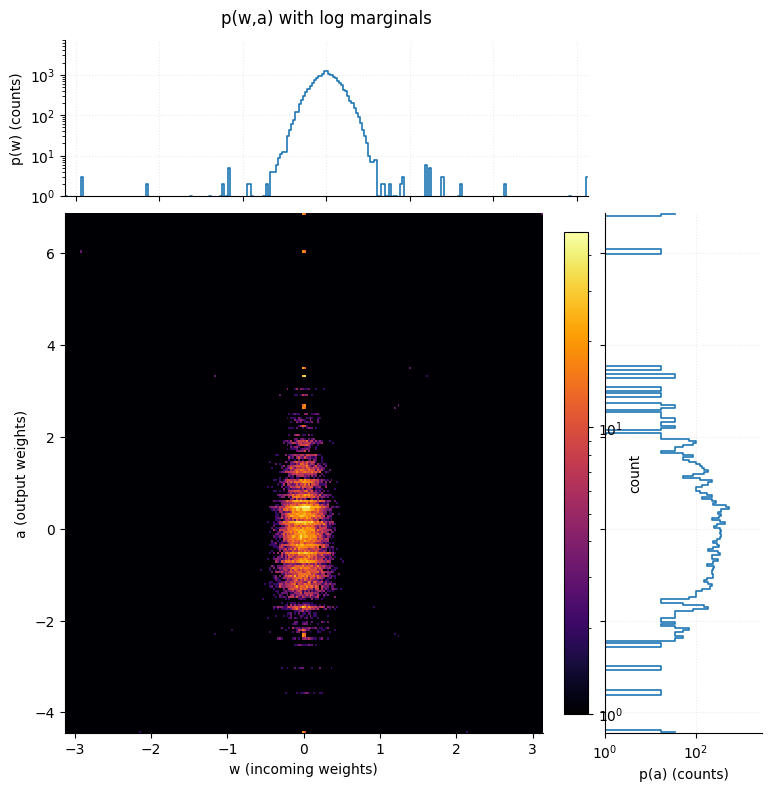

In [3]:
# %% p(w,a) heatmap with log-scaled marginals (Inferno) — notebook-ready
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from pathlib import Path
from typing import Optional, Tuple, Union

# ------------------ loading helpers ------------------
def _get_tensor_from_state_dict(sd, key_name: str):
    """Fetch tensor 'w' or 'a' from a state_dict (handles prefixes like 'module.')."""
    if key_name in sd:
        return sd[key_name]
    for k in sd.keys():
        if k.endswith(f".{key_name}"):
            return sd[k]
    raise KeyError(f"'{key_name}' not found in state_dict keys: {list(sd.keys())[:10]} ...")

def load_wa_from_state_dict(model_path: str) -> Tuple[np.ndarray, np.ndarray]:
    """Return flat arrays (w_vals, a_vals) from a TwoLayerNet state_dict."""
    sd = torch.load(model_path, map_location="cpu")
    if not isinstance(sd, dict):
        raise ValueError("File doesn't look like a state_dict. Save with model.state_dict().")
    w = _get_tensor_from_state_dict(sd, "w").detach().cpu().numpy()  # (d, N)
    a = _get_tensor_from_state_dict(sd, "a").detach().cpu().numpy()  # (N, 1) or (N,)
    w = np.asarray(w, dtype=np.float64)
    a = np.asarray(a.squeeze(), dtype=np.float64)
    d, N = w.shape
    # Pair every a_i with all its incoming weights w_{k,i}  ->  d*N samples
    w_vals = w.reshape(-1, order="F")        # column-major flattens by neuron
    a_vals = np.repeat(a, d)
    return w_vals, a_vals

# ------------------ main plotter ------------------
def plot_wa_heatmap(
    model_or_arrays: Union[str, Tuple[np.ndarray, np.ndarray]],
    bins: int = 200,
    range_mode: str = "full",   # "full" | "quantile"
    clip_percentiles: Tuple[float, float] = (0.05, 99.95),
    log_heatmap: bool = True,
    log_marginals: bool = True,
    max_pairs: Optional[int] = None,     # subsample for huge nets
    scatter_outliers: bool = True,       # overlay outliers when range_mode="quantile"
    outlier_scatter_cap: int = 8000,     # max points to scatter
    figsize: Tuple[float, float] = (9, 9),
    title: Optional[str] = None,
    save_path: Optional[str] = None,
):
    """
    Plot p(w,a) as a 2D histogram with log-scaled marginals.
    - Heatmap uses Inferno + (optional) LogNorm so single-count bins are visible.
    - Marginals use the SAME bin edges and log y-scale so outliers (e.g., a = -4 with count=1) are obvious.
    - If range_mode='quantile', heatmap range is clipped, BUT outliers are (optionally) overlaid as a scatter layer.
    """
    # Load data
    if isinstance(model_or_arrays, str):
        assert Path(model_or_arrays).exists(), f"File not found: {model_or_arrays}"
        w_vals, a_vals = load_wa_from_state_dict(model_or_arrays)
        model_name = Path(model_or_arrays).name
    else:
        w_vals, a_vals = model_or_arrays
        w_vals = np.asarray(w_vals, dtype=np.float64).ravel()
        a_vals = np.asarray(a_vals, dtype=np.float64).ravel()
        model_name = "arrays"

    # Optional subsample (for plotting performance only)
    if max_pairs is not None and len(w_vals) > max_pairs:
        idx = np.random.default_rng().choice(len(w_vals), size=max_pairs, replace=False)
        w_vals, a_vals = w_vals[idx], a_vals[idx]

    # Decide plotting range
    if range_mode == "full":
        x_min, x_max = np.min(w_vals), np.max(w_vals)
        y_min, y_max = np.min(a_vals), np.max(a_vals)
    elif range_mode == "quantile":
        x_min, x_max = np.percentile(w_vals, clip_percentiles)
        y_min, y_max = np.percentile(a_vals, clip_percentiles)
    else:
        raise ValueError("range_mode must be 'full' or 'quantile'.")

    # Build 2D histogram (COUNTS, not density, so '1 count' shows up neatly on log scales)
    H, xedges, yedges = np.histogram2d(
        w_vals, a_vals,
        bins=bins,
        range=[[x_min, x_max], [y_min, y_max]],
        density=False
    )

    # Marginals as projections that match the heatmap binning
    # px: counts per w-bin, py: counts per a-bin
    px = H.sum(axis=1)        # length = xbins
    py = H.sum(axis=0)        # length = ybins
    x_centers = 0.5 * (xedges[:-1] + xedges[1:])
    y_centers = 0.5 * (yedges[:-1] + yedges[1:])

    # Prepare figure layout
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(2, 2, width_ratios=[4, 1.2], height_ratios=[1.2, 4],
                  wspace=0.05, hspace=0.05, figure=fig)
    ax_top   = fig.add_subplot(gs[0, 0])
    ax_hm    = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_hm)

    # Heatmap with log color (single counts visible)
    eps = 1e-12
    norm = LogNorm(vmin=max(H[H>0].min() if (H>0).any() else 1, 1e-12), vmax=H.max()) if log_heatmap else None
    mesh = ax_hm.pcolormesh(
        xedges, yedges, (H.T if norm is None else H.T + eps),
        cmap="inferno", shading="auto", norm=norm
    )
    cbar = fig.colorbar(mesh, ax=ax_hm, fraction=0.046, pad=0.04)
    cbar.set_label("count")

    # If we clipped by quantiles, overlay outliers so nothing is lost
    if range_mode == "quantile" and scatter_outliers:
        outside = (w_vals < x_min) | (w_vals > x_max) | (a_vals < y_min) | (a_vals > y_max)
        if np.any(outside):
            W_out, A_out = w_vals[outside], a_vals[outside]
            # Downsample to keep figure responsive
            if len(W_out) > outlier_scatter_cap:
                sel = np.random.default_rng().choice(len(W_out), outlier_scatter_cap, replace=False)
                W_out, A_out = W_out[sel], A_out[sel]
            ax_hm.scatter(W_out, A_out, s=6, alpha=0.5, linewidths=0.0)

    ax_hm.set_xlabel("w (incoming weights)")
    ax_hm.set_ylabel("a (output weights)")

    # Top histogram p(w) with log y-scale
    # Use step to keep it light; add a tiny epsilon to avoid log(0) complaints.
    px_plot = np.maximum(px, 1e-12)
    ax_top.step(x_centers, px_plot, where="mid", linewidth=1.2)
    ax_top.set_ylabel("p(w) (counts)")
    if log_marginals:
        ax_top.set_yscale("log")
        ax_top.set_ylim(bottom=1)  # show single counts clearly
    ax_top.tick_params(axis='x', labelbottom=False)
    ax_top.grid(alpha=0.25, linestyle=':')

    # Right histogram p(a) with log y-scale
    py_plot = np.maximum(py, 1e-12)
    ax_right.step(py_plot, y_centers, where="mid", linewidth=1.2)
    ax_right.set_xlabel("p(a) (counts)")
    if log_marginals:
        ax_right.set_xscale("log")
        ax_right.set_xlim(left=1)  # show single counts clearly
    ax_right.tick_params(axis='y', labelleft=False)
    ax_right.grid(alpha=0.25, linestyle=':')

    # Cosmetics
    for ax in (ax_hm, ax_top, ax_right):
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)

    if title is None:
        title = f"Joint distribution p(w, a)\n{model_name}"
    ax_top.set_title(title, pad=12)

    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to: {save_path}")
    return fig, (ax_hm, ax_top, ax_right), (xedges, yedges, H)

# ------------------ examples ------------------

fig, axes, edges = plot_wa_heatmap(
    "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta_5.000000e-04_gamma_0.500000.pt",
    bins=250,
    range_mode="full",            # include all outliers in the heatmap range
    log_heatmap=True,
    log_marginals=True,
    max_pairs=None,
    title="p(w,a) with log marginals",
)

# 2) From arrays (e.g., your MCMC output for w[:,0] vs a):
# w_col = W_final[:, 0]     # scalar per sample
# a_samps = A_final         # scalar per sample
# fig, axes, edges = plot_wa_heatmap(
#     (w_col, a_samps),
#     bins=200,
#     range_mode="quantile",        # focus interior...
#     clip_percentiles=(0.5, 99.5), # ...but:
#     scatter_outliers=True,        # overlay points beyond range so none are lost
#     log_heatmap=True,
#     log_marginals=True,
#     title="MCMC p(w1,a) — clipped + outlier overlay",
# )
# plt.show()


/tmp/ipykernel_3672977/3820320877.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


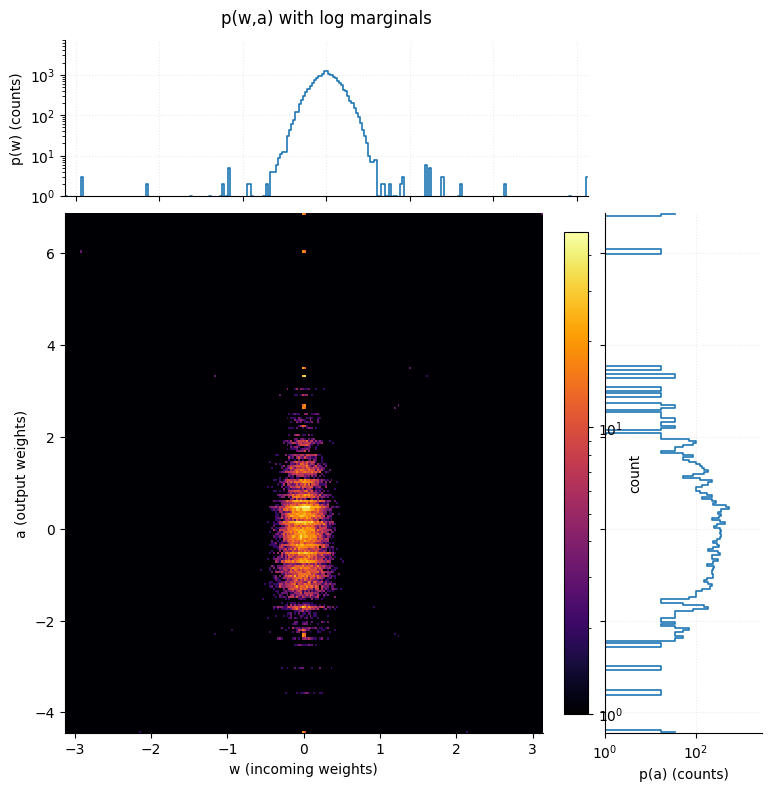

In [6]:
# %% Continuous (KDE) p(w,a) heatmap + log-scaled marginals (Inferno)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from pathlib import Path
from typing import Optional, Tuple
from scipy.stats import gaussian_kde
from typing import Optional, Tuple, Union


def plot_wa_kde_heatmap(
    w_vals: np.ndarray,
    a_vals: np.ndarray,
    bins: int = 220,
    range_mode: str = "quantile",
    clip_percentiles: Tuple[float, float] = (0.1, 99.9),
    bw: Union[str, float] = "scott",   # <-- fix here
    bw_mult: float = 1.0,
    log_heatmap: bool = True,
    log_marginals: bool = True,
    figsize: Tuple[float, float] = (9, 9),
    title: Optional[str] = None,
    save_path: Optional[str] = None,
    overlay_outliers: bool = True,
    outlier_scatter_cap: int = 8000,
):

    """
    Smooth 2D KDE of p(w,a) (continuous heatmap) with aligned, log-scaled marginal histograms.
    The marginal bins match the heatmap grid so projections are faithful.
    """
    w_vals = np.asarray(w_vals, dtype=np.float64).ravel()
    a_vals = np.asarray(a_vals, dtype=np.float64).ravel()
    assert w_vals.shape[0] == a_vals.shape[0], "w and a must have same length."

    # ----- choose plotting range -----
    if range_mode == "full":
        x_min, x_max = np.min(w_vals), np.max(w_vals)
        y_min, y_max = np.min(a_vals), np.max(a_vals)
    elif range_mode == "quantile":
        x_min, x_max = np.percentile(w_vals, clip_percentiles)
        y_min, y_max = np.percentile(a_vals, clip_percentiles)
    else:
        raise ValueError("range_mode must be 'full' or 'quantile'.")

    # Bin edges (used both for heatmap grid & marginals)
    xedges = np.linspace(x_min, x_max, bins + 1)
    yedges = np.linspace(y_min, y_max, bins + 1)
    xcent = 0.5 * (xedges[:-1] + xedges[1:])
    ycent = 0.5 * (yedges[:-1] + yedges[1:])

    # ----- KDE over centers for smooth “continuous” density -----
    points = np.vstack([w_vals, a_vals])
    kde = gaussian_kde(points, bw_method=bw)
    if bw_mult != 1.0:
        # scale the already-computed factor (works for "scott"/"silverman" or numeric)
        kde.set_bandwidth(kde.factor * bw_mult)

    XX, YY = np.meshgrid(xcent, ycent, indexing="xy")
    ZZ = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(YY.shape)  # density

    # ----- matching marginals as hist counts (so singletons show up on log) -----
    Hx, _ = np.histogram(w_vals, bins=xedges)
    Hy, _ = np.histogram(a_vals, bins=yedges)

    # ----- figure layout -----
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(2, 2, width_ratios=[4, 1.25], height_ratios=[1.25, 4],
                  wspace=0.05, hspace=0.05, figure=fig)
    ax_top   = fig.add_subplot(gs[0, 0])
    ax_hm    = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_hm)

    # ----- heatmap (continuous) -----
    # Use pcolormesh with edges + KDE at cell centers; log color makes tails/outliers visible.
    eps = 1e-300  # KDE is >0, but guard for LogNorm
    norm = LogNorm(vmin=max(ZZ.min(), eps), vmax=ZZ.max()) if log_heatmap else None
    mesh = ax_hm.pcolormesh(xedges, yedges, ZZ, cmap="inferno", shading="auto", norm=norm)
    cbar = fig.colorbar(mesh, ax=ax_hm, fraction=0.046, pad=0.04)
    cbar.set_label("density")

    # If we clipped by quantiles, overlay any true outliers so nothing gets lost
    if range_mode == "quantile" and overlay_outliers:
        outside = (w_vals < xedges[0]) | (w_vals > xedges[-1]) | (a_vals < yedges[0]) | (a_vals > yedges[-1])
        if np.any(outside):
            W_out, A_out = w_vals[outside], a_vals[outside]
            if len(W_out) > outlier_scatter_cap:
                sel = np.random.default_rng().choice(len(W_out), outlier_scatter_cap, replace=False)
                W_out, A_out = W_out[sel], A_out[sel]
            ax_hm.scatter(W_out, A_out, s=6, alpha=0.5, linewidths=0.0)

    ax_hm.set_xlabel("w (incoming weights or chosen component)")
    ax_hm.set_ylabel("a (output weight)")

    # ----- top marginal (hist counts, log-y) -----
    ax_top.step(xcent, np.maximum(Hx, 1e-12), where="mid", linewidth=1.2)
    ax_top.set_ylabel("p(w) (counts)")
    if log_marginals:
        ax_top.set_yscale("log")
        ax_top.set_ylim(bottom=1)  # show single counts clearly
    ax_top.tick_params(axis='x', labelbottom=False)
    ax_top.grid(alpha=0.25, linestyle=':')

    # ----- right marginal (hist counts, log-x) -----
    ax_right.step(np.maximum(Hy, 1e-12), ycent, where="mid", linewidth=1.2)
    ax_right.set_xlabel("p(a) (counts)")
    if log_marginals:
        ax_right.set_xscale("log")
        ax_right.set_xlim(left=1)  # show single counts clearly
    ax_right.tick_params(axis='y', labelleft=False)
    ax_right.grid(alpha=0.25, linestyle=':')

    # cosmetics
    for ax in (ax_hm, ax_top, ax_right):
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)

    if title:
        ax_top.set_title(title, pad=12)

    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to: {save_path}")
    return fig, (ax_hm, ax_top, ax_right)


fig, axes, edges = plot_wa_heatmap(
    "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta_5.000000e-04_gamma_0.500000.pt",
    bins=250,
    range_mode="full",            # include all outliers in the heatmap range
    log_heatmap=True,
    log_marginals=True,
    max_pairs=None,
    title="p(w,a) with log marginals",
)


Cumulative energy fraction E(40) = 0.477306903235


/tmp/ipykernel_532438/1606460607.py:389: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


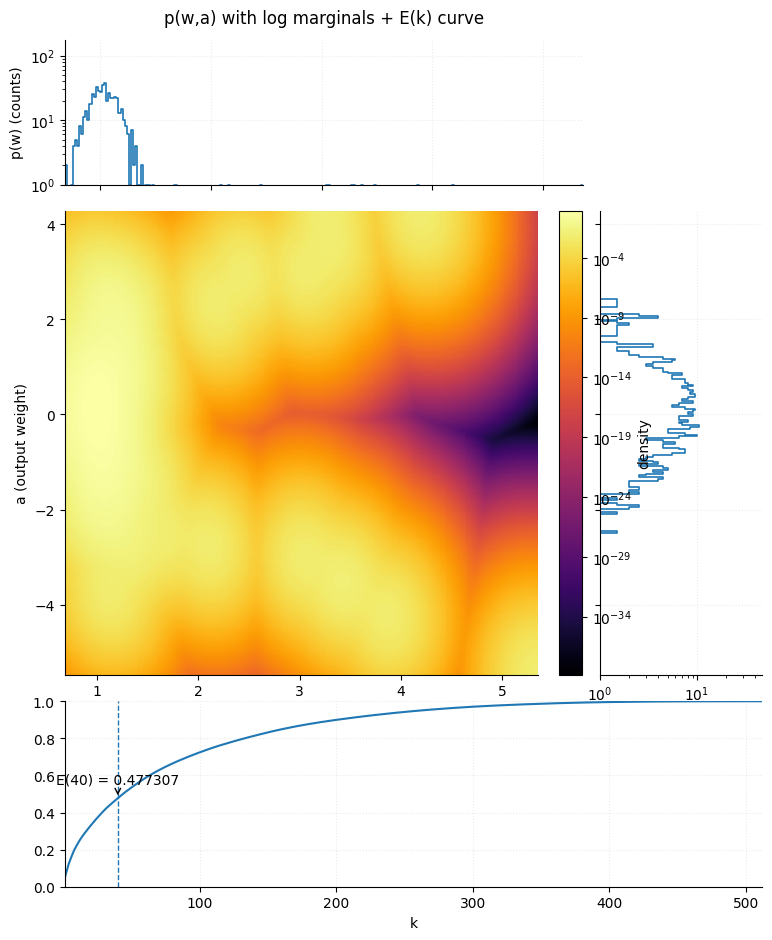

In [9]:
# %% Continuous (KDE) p(w,a) heatmap + log-scaled marginals (Inferno) + E(k) curve
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from pathlib import Path
from typing import Optional, Tuple, Union
from scipy.stats import gaussian_kde

# ------------------------------------------------------------
# Helpers: accept either arrays or a path to load w,a
# ------------------------------------------------------------
def _to_numpy(x):
    """Convert torch/np to a 1D/2D numpy array if possible."""
    try:
        import torch
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

def _find_w_a_in_mapping(mapping) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Try to locate w and a arrays/tensors in a (possibly nested) mapping/dict.
    Heuristics: look for keys like 'w','weights','W' and 'a','alpha','A','coeffs'.
    """
    import collections.abc as cab

    CAND_W = {"w", "weights", "W", "weight", "ws"}
    CAND_A = {"a", "alpha", "alphas", "A", "coeffs", "coefficients"}

    found_w, found_a = None, None

    def walk(obj):
        nonlocal found_w, found_a
        if isinstance(obj, cab.Mapping):
            for k, v in obj.items():
                key = str(k).lower()
                if key in CAND_W and found_w is None:
                    try:
                        found_w = _to_numpy(v)
                    except Exception:
                        pass
                if key in CAND_A and found_a is None:
                    try:
                        found_a = _to_numpy(v)
                    except Exception:
                        pass
                # recurse
                if isinstance(v, cab.Mapping):
                    walk(v)
                elif isinstance(v, (list, tuple)):
                    for vv in v:
                        walk(vv)

    walk(mapping)
    return found_w, found_a

def _load_w_a_from_path(pathlike: Union[str, Path]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load w,a from a file path.
    Supports:
      - .npy: shape (2, N) -> (w,a)
      - .npz: keys like 'w','a' (or first two arrays)
      - .pt/.pth: PyTorch objects (state dicts, pickled dicts/tuples)
    Returns raw arrays; shape reconciliation happens later.
    """
    p = Path(pathlike)
    suffix = p.suffix.lower()

    if suffix == ".npy":
        arr = np.load(p, allow_pickle=True)
        if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[0] == 2:
            w_vals, a_vals = arr[0], arr[1]
            return _to_numpy(w_vals), _to_numpy(a_vals)
        raise ValueError("'.npy' file not recognized: expected shape (2, N) array (first row=w, second row=a).")

    if suffix == ".npz":
        data = np.load(p, allow_pickle=True)
        keys = list(data.keys())
        # prefer named keys
        for wk in ["w", "weights", "W"]:
            if wk in data:
                w_vals = data[wk]
                break
        else:
            w_vals = data[keys[0]]
        for ak in ["a", "alpha", "alphas", "A", "coeffs", "coefficients"]:
            if ak in data:
                a_vals = data[ak]
                break
        else:
            a_vals = data[keys[1 if len(keys) > 1 else 0]]
        return _to_numpy(w_vals), _to_numpy(a_vals)

    if suffix in {".pt", ".pth"}:
        try:
            import torch
        except ImportError as e:
            raise ImportError("Tried to load a .pt/.pth file but torch is not installed.") from e
        obj = torch.load(p, map_location="cpu")

        # tuple/list with two items
        if isinstance(obj, (list, tuple)) and len(obj) >= 2:
            return _to_numpy(obj[0]), _to_numpy(obj[1])

        # dict-like: try keys, then fallbacks
        if isinstance(obj, dict):
            w_raw, a_raw = _find_w_a_in_mapping(obj)

            # fallback: collect 1D/2D arrays and pick a plausible pair
            if w_raw is None or a_raw is None:
                cands = []

                def collect(o):
                    if isinstance(o, dict):
                        for v in o.values():
                            collect(v)
                    elif isinstance(o, (list, tuple)):
                        for v in o:
                            collect(v)
                    else:
                        try:
                            arr = _to_numpy(o)
                            if isinstance(arr, np.ndarray) and arr.ndim in (1, 2) and arr.size > 0:
                                cands.append(arr)
                        except Exception:
                            pass

                collect(obj)

                # try to pick likely (w, a): prefer a 1D candidate as 'a'
                one_d = [x for x in cands if x.ndim == 1]
                two_d = [x for x in cands if x.ndim == 2]

                # choose 'a' first
                if a_raw is None and one_d:
                    # choose the most "sparse-looking" 1D candidate as a heuristic
                    a_raw = max(one_d, key=lambda v: v.shape[0])

                # now choose 'w' that can align with a (either 1D same len or 2D with one dim equal)
                if a_raw is not None and w_raw is None:
                    N = a_raw.shape[0]
                    # exact 1D match
                    matches_1d = [x for x in one_d if x is not a_raw and x.shape[0] == N]
                    if matches_1d:
                        w_raw = matches_1d[0]
                    else:
                        # 2D with a matching dimension
                        matches_2d = [X for X in two_d if N in X.shape]
                        if matches_2d:
                            w_raw = matches_2d[0]

            if w_raw is None or a_raw is None:
                raise ValueError("Could not locate 'w' and 'a' in the .pt/.pth file.")

            return _to_numpy(w_raw), _to_numpy(a_raw)

        raise ValueError("Unsupported object stored in the .pt/.pth file.")

    raise ValueError(f"Unsupported file extension: {suffix}. Provide arrays or a .npy/.npz/.pt/.pth file.")

def _coerce_w_to_vector(w_raw: np.ndarray, a_len: int, w_component: Optional[int], w_reduce: str) -> np.ndarray:
    """
    Ensure w becomes a 1D vector of length a_len.
    If w_raw is 2D and one axis equals a_len, reduce along the other axis.
    Reduction methods:
      - 'norm' (default): L2 norm across feature dim
      - 'mean': mean across feature dim
      - 'sum' : sum across feature dim
      - 'component': select column/row index given by w_component
    """
    w_raw = np.asarray(w_raw)
    if w_raw.ndim == 1:
        if w_raw.shape[0] != a_len:
            raise ValueError(f"w is 1D with length {w_raw.shape[0]}, but a has length {a_len}.")
        return w_raw.astype(np.float64)

    if w_raw.ndim != 2:
        raise ValueError(f"w must be 1D or 2D; got shape {w_raw.shape}.")

    # Identify sample axis (the one matching a_len)
    if w_raw.shape[0] == a_len:
        sample_axis, feat_axis = 0, 1
    elif w_raw.shape[1] == a_len:
        sample_axis, feat_axis = 1, 0
        w_raw = np.swapaxes(w_raw, 0, 1)  # now shape (a_len, D)
    else:
        raise ValueError(f"w is 2D with shape {w_raw.shape}, but neither dimension equals len(a)={a_len}.")

    # Now w_raw is (a_len, D)
    D = w_raw.shape[1]
    if w_reduce == "component":
        idx = 0 if (w_component is None) else int(w_component)
        if idx < 0 or idx >= D:
            raise ValueError(f"w_component={idx} is out of bounds for D={D}.")
        w_vec = w_raw[:, idx]
    elif w_reduce == "norm":
        w_vec = np.linalg.norm(w_raw, axis=1)
    elif w_reduce == "mean":
        w_vec = w_raw.mean(axis=1)
    elif w_reduce == "sum":
        w_vec = w_raw.sum(axis=1)
    else:
        raise ValueError(f"Unknown w_reduce='{w_reduce}'. Use 'norm'|'mean'|'sum'|'component'.")

    return w_vec.astype(np.float64)

# ------------------------------------------------------------
# Main plotting function
# ------------------------------------------------------------
def plot_wa_heatmap(
    data_or_path: Union[np.ndarray, Tuple[np.ndarray, np.ndarray], str, Path],
    bins: int = 220,
    range_mode: str = "quantile",
    clip_percentiles: Tuple[float, float] = (0.1, 99.9),
    bw: Union[str, float] = "scott",
    bw_mult: float = 1.0,
    log_heatmap: bool = True,
    log_marginals: bool = True,
    figsize: Tuple[float, float] = (9, 11),
    title: Optional[str] = None,
    save_path: Optional[str] = None,
    overlay_outliers: bool = True,
    outlier_scatter_cap: int = 8000,
    max_pairs: Optional[int] = None,
    k_mark: int = 40,
    # NEW: control how 2D w is reduced to 1D
    w_reduce: str = "norm",           # 'norm'|'mean'|'sum'|'component'
    w_component: Optional[int] = None # used when w_reduce='component'
):
    """
    Smooth 2D KDE of p(w,a) (continuous heatmap) with aligned, log-scaled marginals,
    plus bottom panel E(k) = sum_{i<=k} a_(i)^2 / sum_i a_i^2 vs k.
    Accepts w either as 1D (len=N) or 2D (Nxd or dxN); 2D is reduced to 1D via w_reduce.
    """
    # --- ingest data ---
    if isinstance(data_or_path, (str, Path)):
        w_raw, a_raw = _load_w_a_from_path(data_or_path)
    else:
        arr = np.asarray(data_or_path, dtype=object)
        if isinstance(data_or_path, (list, tuple)) and len(data_or_path) == 2:
            w_raw, a_raw = _to_numpy(data_or_path[0]), _to_numpy(data_or_path[1])
        elif isinstance(arr, np.ndarray) and arr.ndim >= 2 and arr.shape[0] == 2:
            w_raw, a_raw = _to_numpy(arr[0]), _to_numpy(arr[1])
        else:
            raise ValueError("data_or_path must be (w, a), a (2, N) array, or a path to a supported file.")

    a_vals = np.asarray(a_raw, dtype=np.float64).ravel()
    N = a_vals.shape[0]

    # Coerce w to 1D aligned with a
    w_vals = _coerce_w_to_vector(w_raw, a_len=N, w_component=w_component, w_reduce=w_reduce)

    if w_vals.shape[0] != a_vals.shape[0]:
        raise ValueError(f"w and a must have same length, got w={w_vals.shape} and a={a_vals.shape} "
                         f"(after reduction of w).")

    # Optional subsampling for speed (apply same indices to both)
    if max_pairs is not None and N > max_pairs:
        rng = np.random.default_rng()
        idx = rng.choice(N, size=max_pairs, replace=False)
        w_vals = w_vals[idx]
        a_vals = a_vals[idx]
        N = w_vals.shape[0]

    # ----- choose plotting range -----
    if range_mode == "full":
        x_min, x_max = np.min(w_vals), np.max(w_vals)
        y_min, y_max = np.min(a_vals), np.max(a_vals)
    elif range_mode == "quantile":
        x_min, x_max = np.percentile(w_vals, clip_percentiles)
        y_min, y_max = np.percentile(a_vals, clip_percentiles)
    else:
        raise ValueError("range_mode must be 'full' or 'quantile'.")

    # Bin edges (used both for heatmap grid & marginals)
    bins = int(bins)
    xedges = np.linspace(x_min, x_max, bins + 1)
    yedges = np.linspace(y_min, y_max, bins + 1)
    xcent = 0.5 * (xedges[:-1] + xedges[1:])
    ycent = 0.5 * (yedges[:-1] + yedges[1:])

    # ----- KDE over centers -----
    points = np.vstack([w_vals, a_vals])
    kde = gaussian_kde(points, bw_method=bw)
    if bw_mult != 1.0:
        kde.set_bandwidth(kde.factor * bw_mult)

    XX, YY = np.meshgrid(xcent, ycent, indexing="xy")
    ZZ = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(YY.shape)

    # ----- matching marginals as hist counts -----
    Hx, _ = np.histogram(w_vals, bins=xedges)
    Hy, _ = np.histogram(a_vals, bins=yedges)

    # ----- E(k) curve (sorted by descending |a|) -----
    a_sq = np.square(a_vals)
    order = np.argsort(a_sq)[::-1]
    a_sq_sorted = a_sq[order]
    denom = a_sq_sorted.sum()
    Ek = np.cumsum(a_sq_sorted) / (denom if denom > 0 else 1.0)

    # Guard k_mark within [1, N]
    k_mark_clamped = int(np.clip(k_mark, 1, len(Ek)))
    Ek_kmark = Ek[k_mark_clamped - 1]

    # ----- figure layout (add third row for E(k)) -----
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        3, 2,
        width_ratios=[4, 1.25],
        height_ratios=[1.25, 4, 1.6],
        wspace=0.05, hspace=0.1,
        figure=fig
    )
    ax_top   = fig.add_subplot(gs[0, 0])
    ax_hm    = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_hm)
    ax_ek    = fig.add_subplot(gs[2, 0:2])

    # ----- heatmap -----
    eps = 1e-300
    norm = LogNorm(vmin=max(ZZ.min(), eps), vmax=ZZ.max()) if log_heatmap else None
    mesh = ax_hm.pcolormesh(xedges, yedges, ZZ, cmap="inferno", shading="auto", norm=norm)
    cbar = fig.colorbar(mesh, ax=ax_hm, fraction=0.046, pad=0.04)
    cbar.set_label("density")

    # Overlay true outliers if we clipped
    if range_mode == "quantile" and overlay_outliers:
        outside = (w_vals < xedges[0]) | (w_vals > xedges[-1]) | (a_vals < yedges[0]) | (a_vals > yedges[-1])
        if np.any(outside):
            W_out, A_out = w_vals[outside], a_vals[outside]
            if len(W_out) > outlier_scatter_cap:
                sel = np.random.default_rng().choice(len(W_out), outlier_scatter_cap, replace=False)
                W_out, A_out = W_out[sel], A_out[sel]
            ax_hm.scatter(W_out, A_out, s=6, alpha=0.5, linewidths=0.0)

    ax_hm.set_xlabel("w (incoming weights or chosen component/reduction)")
    ax_hm.set_ylabel("a (output weight)")

    # ----- top marginal (hist counts, log-y) -----
    ax_top.step(xcent, np.maximum(Hx, 1e-12), where="mid", linewidth=1.2)
    ax_top.set_ylabel("p(w) (counts)")
    if log_marginals:
        ax_top.set_yscale("log")
        ax_top.set_ylim(bottom=1)
    ax_top.tick_params(axis='x', labelbottom=False)
    ax_top.grid(alpha=0.25, linestyle=':')

    # ----- right marginal (hist counts, log-x) -----
    ax_right.step(np.maximum(Hy, 1e-12), ycent, where="mid", linewidth=1.2)
    ax_right.set_xlabel("p(a) (counts)")
    if log_marginals:
        ax_right.set_xscale("log")
        ax_right.set_xlim(left=1)
    ax_right.tick_params(axis='y', labelleft=False)
    ax_right.grid(alpha=0.25, linestyle=':')

    # ----- bottom E(k) plot -----
    k_axis = np.arange(1, len(Ek) + 1)
    ax_ek.plot(k_axis, Ek, linewidth=1.5)
    ax_ek.set_xlim(1, max(10, len(Ek)))
    ax_ek.set_ylim(0, 1.0)
    ax_ek.set_xlabel("k")
    ax_ek.set_ylabel(r"")
    ax_ek.grid(alpha=0.25, linestyle=':')

    # Mark k=40 (clamped), and print the value
    ax_ek.axvline(k_mark_clamped, linestyle="--", linewidth=1.0)
    ax_ek.annotate(
        f"E({k_mark_clamped}) = {Ek_kmark:.6f}",
        xy=(k_mark_clamped, Ek_kmark),
        xytext=(k_mark_clamped, min(1.0, Ek_kmark + 0.08)),
        arrowprops=dict(arrowstyle="->", lw=1.0),
        ha="center"
    )
    print(f"Cumulative energy fraction E({k_mark_clamped}) = {Ek_kmark:.12f}")

    # cosmetics
    for ax in (ax_hm, ax_top, ax_right, ax_ek):
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)

    if title:
        ax_top.set_title(title, pad=12)

    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to: {save_path}")

    # Return edges for heatmap grid
    return fig, (ax_hm, ax_top, ax_right, ax_ek), (xedges, yedges)


# ----------------------------------------------------------------
# Example call (your original path) — now robust to 2D w
#   If your 'w' in the .pt file is (N, d) or (d, N), we'll take L2 norm across features.
#   To use a specific incoming-weight component instead, set w_reduce='component', w_component=<idx>.
# ----------------------------------------------------------------
fig, axes, edges = plot_wa_heatmap(
    "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4/d35_k4/final_model_P_7500_d_35_k_4_exp_2_kappa_0.000500_eta_5.000000e-04_gamma_0.500000.pt",
    bins=250,
    range_mode="full",
    log_heatmap=True,
    log_marginals=True,
    max_pairs=None,
    title="p(w,a) with log marginals + E(k) curve",
    k_mark=40,
    w_reduce="norm",        # or 'component'
    w_component=None        # e.g. 0 if w_reduce='component'
)


In [12]:
# %% Continuous (counts) p(w,a) heatmap + log-scaled marginals (Inferno) + energy curves for a & w
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from pathlib import Path
from typing import Optional, Tuple, Union
from scipy.stats import gaussian_kde

# ------------------------------------------------------------
# Helpers: accept arrays or a path; allow 2D w -> 1D via reduction
# ------------------------------------------------------------
def _to_numpy(x):
    """Convert torch/np to numpy array if possible."""
    try:
        import torch
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

def _find_w_a_in_mapping(mapping) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """Heuristically locate 'w' and 'a' inside nested dict-like objects."""
    import collections.abc as cab
    CAND_W = {"w", "weights", "W", "weight", "ws"}
    CAND_A = {"a", "alpha", "alphas", "A", "coeffs", "coefficients"}
    found_w, found_a = None, None

    def walk(obj):
        nonlocal found_w, found_a
        if isinstance(obj, cab.Mapping):
            for k, v in obj.items():
                key = str(k).lower()
                if key in CAND_W and found_w is None:
                    try: found_w = _to_numpy(v)
                    except Exception: pass
                if key in CAND_A and found_a is None:
                    try: found_a = _to_numpy(v)
                    except Exception: pass
                if isinstance(v, cab.Mapping):
                    walk(v)
                elif isinstance(v, (list, tuple)):
                    for vv in v: walk(vv)
    walk(mapping)
    return found_w, found_a

def _load_w_a_from_path(pathlike: Union[str, Path]) -> Tuple[np.ndarray, np.ndarray]:
    """Load w,a from .npy/.npz/.pt/.pth files."""
    p = Path(pathlike)
    suffix = p.suffix.lower()

    if suffix == ".npy":
        arr = np.load(p, allow_pickle=True)
        if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[0] == 2:
            return _to_numpy(arr[0]), _to_numpy(arr[1])
        raise ValueError("'.npy' expected shape (2, N): first row=w, second row=a.")

    if suffix == ".npz":
        data = np.load(p, allow_pickle=True)
        keys = list(data.keys())
        for wk in ["w", "weights", "W"]:
            if wk in data: w_vals = data[wk]; break
        else: w_vals = data[keys[0]]
        for ak in ["a", "alpha", "alphas", "A", "coeffs", "coefficients"]:
            if ak in data: a_vals = data[ak]; break
        else: a_vals = data[keys[1 if len(keys) > 1 else 0]]
        return _to_numpy(w_vals), _to_numpy(a_vals)

    if suffix in {".pt", ".pth"}:
        try:
            import torch
        except ImportError as e:
            raise ImportError("Torch is required to load .pt/.pth files.") from e
        obj = torch.load(p, map_location="cpu")

        if isinstance(obj, (list, tuple)) and len(obj) >= 2:
            return _to_numpy(obj[0]), _to_numpy(obj[1])

        if isinstance(obj, dict):
            w_raw, a_raw = _find_w_a_in_mapping(obj)
            if w_raw is None or a_raw is None:
                # Fallback: collect 1D/2D arrays and pick plausible pair
                cands = []

                def collect(o):
                    if isinstance(o, dict):
                        for v in o.values(): collect(v)
                    elif isinstance(o, (list, tuple)):
                        for v in o: collect(v)
                    else:
                        try:
                            arr = _to_numpy(o)
                            if isinstance(arr, np.ndarray) and arr.ndim in (1, 2) and arr.size > 0:
                                cands.append(arr)
                        except Exception:
                            pass
                collect(obj)

                one_d = [x for x in cands if x.ndim == 1]
                two_d = [x for x in cands if x.ndim == 2]

                if a_raw is None and one_d:
                    a_raw = max(one_d, key=lambda v: v.shape[0])

                if a_raw is not None and w_raw is None:
                    N = a_raw.shape[0]
                    matches_1d = [x for x in one_d if x is not a_raw and x.shape[0] == N]
                    if matches_1d:
                        w_raw = matches_1d[0]
                    else:
                        matches_2d = [X for X in two_d if N in X.shape]
                        if matches_2d: w_raw = matches_2d[0]

            if w_raw is None or a_raw is None:
                raise ValueError("Could not locate 'w' and 'a' in the .pt/.pth file.")
            return _to_numpy(w_raw), _to_numpy(a_raw)

        raise ValueError("Unsupported object stored in the .pt/.pth file.")
    raise ValueError(f"Unsupported file extension: {suffix}")

def _coerce_w_to_vector(w_raw: np.ndarray, a_len: int, w_reduce: str, w_component: Optional[int]) -> np.ndarray:
    """
    Make w a 1D vector of length a_len.
    If w_raw is 2D and one axis equals a_len, reduce along the other axis using:
      - 'norm' (L2 across features) [default]
      - 'mean' | 'sum'
      - 'component' (select a specific feature by index)
    """
    w_raw = np.asarray(w_raw)
    if w_raw.ndim == 1:
        if w_raw.shape[0] != a_len:
            raise ValueError(f"w is 1D length {w_raw.shape[0]} but a is length {a_len}.")
        return w_raw.astype(np.float64)

    if w_raw.ndim != 2:
        raise ValueError(f"w must be 1D or 2D; got shape {w_raw.shape}.")

    # Align so w_raw is (a_len, D)
    if w_raw.shape[0] == a_len:
        pass
    elif w_raw.shape[1] == a_len:
        w_raw = np.swapaxes(w_raw, 0, 1)
    else:
        raise ValueError(f"w is 2D {w_raw.shape}, but neither dimension equals len(a)={a_len}.")

    D = w_raw.shape[1]
    if w_reduce == "component":
        idx = 0 if (w_component is None) else int(w_component)
        if not (0 <= idx < D):
            raise ValueError(f"w_component {idx} out of range for D={D}.")
        w_vec = w_raw[:, idx]
    elif w_reduce == "norm":
        w_vec = np.linalg.norm(w_raw, axis=1)
    elif w_reduce == "mean":
        w_vec = w_raw.mean(axis=1)
    elif w_reduce == "sum":
        w_vec = w_raw.sum(axis=1)
    else:
        raise ValueError("w_reduce must be one of: 'norm'|'mean'|'sum'|'component'")
    return w_vec.astype(np.float64)

# ------------------------------------------------------------
# Main plotting function
# ------------------------------------------------------------
def plot_wa_heatmap(
    data_or_path: Union[Tuple[np.ndarray, np.ndarray], np.ndarray, str, Path],
    bins: int = 220,
    range_mode: str = "quantile",
    clip_percentiles: Tuple[float, float] = (0.1, 99.9),
    heatmap_mode: str = "hist2d",      # 'hist2d' (default) or 'kde'
    bw: Union[str, float] = "scott",   # used only if heatmap_mode='kde'
    bw_mult: float = 1.0,
    log_heatmap: bool = True,
    log_marginals: bool = True,
    figsize: Tuple[float, float] = (9, 11),  # taller to fit energy plot
    title: Optional[str] = None,
    save_path: Optional[str] = None,
    overlay_outliers: bool = True,
    outlier_scatter_cap: int = 8000,
    max_pairs: Optional[int] = None,
    k_mark: int = 40,
    # control 2D->1D reduction for w
    w_reduce: str = "norm",
    w_component: Optional[int] = None,
):
    """
    p(w,a) heatmap with step-style, log-scaled marginals, plus bottom E(k) curves for both a and w.
    Accepts (w,a) arrays or a path to a file (.npy/.npz/.pt/.pth).
    heatmap_mode:
      - 'hist2d' : 2D histogram counts (robust, no smoothing)
      - 'kde'    : smooth Gaussian KDE over the grid
    """
    # --- ingest data ---
    if isinstance(data_or_path, (str, Path)):
        w_raw, a_raw = _load_w_a_from_path(data_or_path)
    else:
        arr = np.asarray(data_or_path, dtype=object)
        if isinstance(data_or_path, (list, tuple)) and len(data_or_path) == 2:
            w_raw, a_raw = _to_numpy(data_or_path[0]), _to_numpy(data_or_path[1])
        elif isinstance(arr, np.ndarray) and arr.ndim >= 2 and arr.shape[0] == 2:
            w_raw, a_raw = _to_numpy(arr[0]), _to_numpy(arr[1])
        else:
            raise ValueError("data_or_path must be (w,a), a (2,N) array, or a path.")

    a_vals = np.asarray(a_raw, dtype=np.float64).ravel()
    N = a_vals.shape[0]
    w_vals = _coerce_w_to_vector(_to_numpy(w_raw), a_len=N, w_reduce=w_reduce, w_component=w_component)

    if w_vals.shape[0] != N:
        raise ValueError(f"w and a must have same length, got w={w_vals.shape} and a={a_vals.shape}.")

    # Optional subsampling for speed (apply same indices to both)
    if max_pairs is not None and N > max_pairs:
        rng = np.random.default_rng()
        idx = rng.choice(N, size=max_pairs, replace=False)
        w_vals = w_vals[idx]
        a_vals = a_vals[idx]
        N = w_vals.shape[0]

    # ----- choose plotting range -----
    if range_mode == "full":
        x_min, x_max = np.min(w_vals), np.max(w_vals)
        y_min, y_max = np.min(a_vals), np.max(a_vals)
    elif range_mode == "quantile":
        x_min, x_max = np.percentile(w_vals, clip_percentiles)
        y_min, y_max = np.percentile(a_vals, clip_percentiles)
    else:
        raise ValueError("range_mode must be 'full' or 'quantile'.")

    # Bin edges (used both for heatmap grid & marginals)
    bins = int(bins)
    xedges = np.linspace(x_min, x_max, bins + 1)
    yedges = np.linspace(y_min, y_max, bins + 1)
    xcent = 0.5 * (xedges[:-1] + xedges[1:])
    ycent = 0.5 * (yedges[:-1] + yedges[1:])

    # ----- figure layout -----
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(3, 2, width_ratios=[4, 1.25], height_ratios=[1.25, 4, 1.8],
                  wspace=0.05, hspace=0.1, figure=fig)
    ax_top   = fig.add_subplot(gs[0, 0])
    ax_hm    = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_hm)
    ax_ek    = fig.add_subplot(gs[2, 0:2])

    # ----- heatmap -----
    if heatmap_mode.lower() == "kde":
        # Smooth KDE on centers; drawn with edges via pcolormesh
        points = np.vstack([w_vals, a_vals])
        kde = gaussian_kde(points, bw_method=bw)
        if bw_mult != 1.0:
            kde.set_bandwidth(kde.factor * bw_mult)
        XX, YY = np.meshgrid(xcent, ycent, indexing="xy")
        ZZ = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(YY.shape)
        eps = 1e-300
        norm = LogNorm(vmin=max(ZZ.min(), eps), vmax=ZZ.max()) if log_heatmap else None
        mesh = ax_hm.pcolormesh(xedges, yedges, ZZ, cmap="inferno", shading="auto", norm=norm)
    else:
        # 2D histogram counts; mask zeros if using LogNorm
        H, xe, ye = np.histogram2d(w_vals, a_vals, bins=[xedges, yedges])
        H = H.T  # shape (len(yedges)-1, len(xedges)-1) for pcolormesh
        if log_heatmap:
            H_plot = np.ma.masked_less_equal(H, 0)
            # vmin at least 1 for counts; avoid issues if all masked
            vmin = 1 if H_plot.count() else 1
            norm = LogNorm(vmin=vmin, vmax=H.max() if H.size else 1)
        else:
            H_plot = H
            norm = None
        mesh = ax_hm.pcolormesh(xedges, yedges, H_plot, cmap="inferno", shading="auto", norm=norm)

    cbar = fig.colorbar(mesh, ax=ax_hm, fraction=0.046, pad=0.04)
    cbar.set_label("density" if heatmap_mode == "kde" else "count")

    # If we clipped by quantiles, overlay any true outliers so nothing gets lost
    if range_mode == "quantile" and overlay_outliers:
        outside = (w_vals < xedges[0]) | (w_vals > xedges[-1]) | (a_vals < yedges[0]) | (a_vals > yedges[-1])
        if np.any(outside):
            W_out, A_out = w_vals[outside], a_vals[outside]
            if len(W_out) > outlier_scatter_cap:
                sel = np.random.default_rng().choice(len(W_out), outlier_scatter_cap, replace=False)
                W_out, A_out = W_out[sel], A_out[sel]
            ax_hm.scatter(W_out, A_out, s=6, alpha=0.5, linewidths=0.0)

    ax_hm.set_xlabel("w (incoming weights or reduction/component)")
    ax_hm.set_ylabel("a (output weight)")

    # ----- marginals (step hist counts, log axes like your form) -----
    Hx, _ = np.histogram(w_vals, bins=xedges)
    Hy, _ = np.histogram(a_vals, bins=yedges)

    ax_top.step(xcent, np.maximum(Hx, 1e-12), where="mid", linewidth=1.2)
    ax_top.set_ylabel("p(w) (counts)")
    if log_marginals:
        ax_top.set_yscale("log")
        ax_top.set_ylim(bottom=1)
    ax_top.tick_params(axis='x', labelbottom=False)
    ax_top.grid(alpha=0.25, linestyle=':')

    ax_right.step(np.maximum(Hy, 1e-12), ycent, where="mid", linewidth=1.2)
    ax_right.set_xlabel("p(a) (counts)")
    if log_marginals:
        ax_right.set_xscale("log")
        ax_right.set_xlim(left=1)
    ax_right.tick_params(axis='y', labelleft=False)
    ax_right.grid(alpha=0.25, linestyle=':')

    # ----- energy curves E_a(k) and E_w(k) -----
    def energy_curve(x: np.ndarray):
        x2 = np.square(x)
        s = np.sort(x2)[::-1]
        denom = s.sum()
        if denom <= 0:
            return np.zeros_like(s)
        return np.cumsum(s) / denom

    Ek_a = energy_curve(a_vals)
    Ek_w = energy_curve(w_vals)

    k_axis = np.arange(1, len(Ek_a) + 1)  # len(Ek_a) == len(Ek_w) == N
    ax_ek.plot(k_axis, Ek_a, linewidth=1.5, label=r"$E_a(k)$")
    ax_ek.plot(k_axis, Ek_w, linewidth=1.5, linestyle="--", label=r"$E_w(k)$")
    ax_ek.set_xlim(1, max(10, len(k_axis)))
    ax_ek.set_ylim(0, 1.0)
    ax_ek.set_xlabel("k")
    ax_ek.set_ylabel(r"")
    ax_ek.grid(alpha=0.25, linestyle=':')
    ax_ek.legend(frameon=False)

    # Mark & print E(40) for both
    k_clamped = int(np.clip(k_mark, 1, len(k_axis)))
    Ea_k = Ek_a[k_clamped - 1]
    Ew_k = Ek_w[k_clamped - 1]
    ax_ek.axvline(k_clamped, linestyle=":", linewidth=1.0)
    ax_ek.annotate(f"E_a({k_clamped})={Ea_k:.6f}",
                   xy=(k_clamped, Ea_k),
                   xytext=(k_clamped, min(1.0, Ea_k + 0.08)),
                   ha="center", arrowprops=dict(arrowstyle="->", lw=1.0))
    ax_ek.annotate(f"E_w({k_clamped})={Ew_k:.6f}",
                   xy=(k_clamped, Ew_k),
                   xytext=(k_clamped, max(0.0, Ew_k - 0.12)),
                   ha="center", arrowprops=dict(arrowstyle="->", lw=1.0))
    print(f"E_a({k_clamped}) = {Ea_k:.12f}")
    print(f"E_w({k_clamped}) = {Ew_k:.12f}")

    # cosmetics
    for ax in (ax_hm, ax_top, ax_right, ax_ek):
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)

    if title:
        ax_top.set_title(title, pad=12)

    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to: {save_path}")

    return fig, (ax_hm, ax_top, ax_right, ax_ek), (xedges, yedges)


# ----------------------------------------------------------------
# Example call (your path). By default uses robust 2D histogram heatmap.
# Switch to KDE by passing heatmap_mode='kde'.
# For 2D w, choose reduction via w_reduce='norm'|'mean'|'sum' or 'component' + w_component.
# ----------------------------------------------------------------



E_a(40) = 0.376372377043
E_w(40) = 0.116126674449


/tmp/ipykernel_532438/3092625951.py:355: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


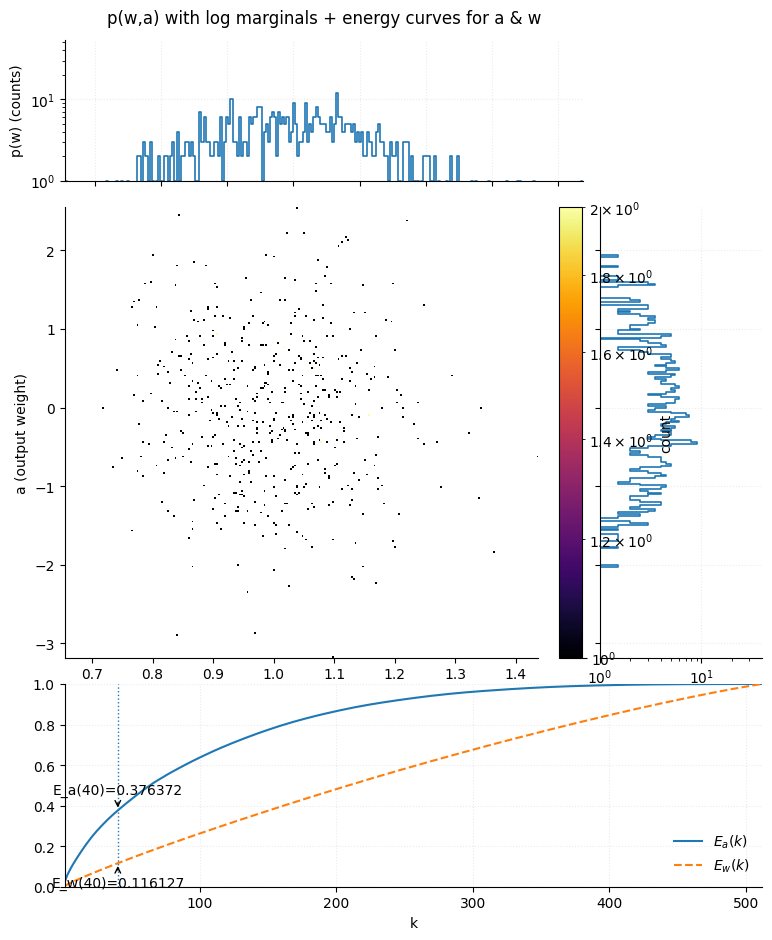

In [20]:
fig, axes, edges = plot_wa_heatmap(
"/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4_histo/d35_k4/init_model_P_10000_d_35_k_4_exp_0_kappa_0.007500_eta_5.000000e-04_gamma_0.500000.pt",
    bins=250,
    range_mode="full",            # include all outliers in the heatmap range
    heatmap_mode="hist2d",        # 'hist2d' is default; use 'kde' if you want smoothing
    log_heatmap=True,
    log_marginals=True,
    max_pairs=None,
    title="p(w,a) with log marginals + energy curves for a & w",
    k_mark=40,
    w_reduce="norm",
    w_component=None
)

E_a(40) = 0.616274331130
E_w(40) = 0.217448451092


/tmp/ipykernel_532438/3092625951.py:355: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


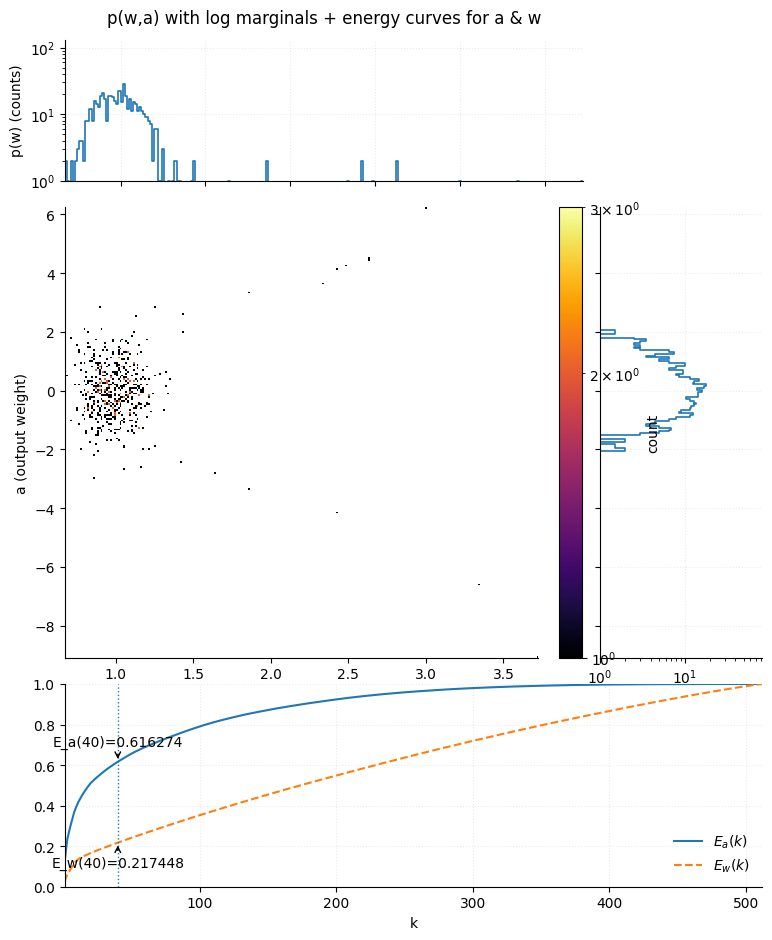

In [21]:
fig, axes, edges = plot_wa_heatmap(
"/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4_histo/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.007500_eta_5.000000e-04_gamma_0.500000.pt",
    bins=250,
    range_mode="full",            # include all outliers in the heatmap range
    heatmap_mode="hist2d",        # 'hist2d' is default; use 'kde' if you want smoothing
    log_heatmap=True,
    log_marginals=True,
    max_pairs=None,
    title="p(w,a) with log marginals + energy curves for a & w",
    k_mark=40,
    w_reduce="norm",
    w_component=None
)

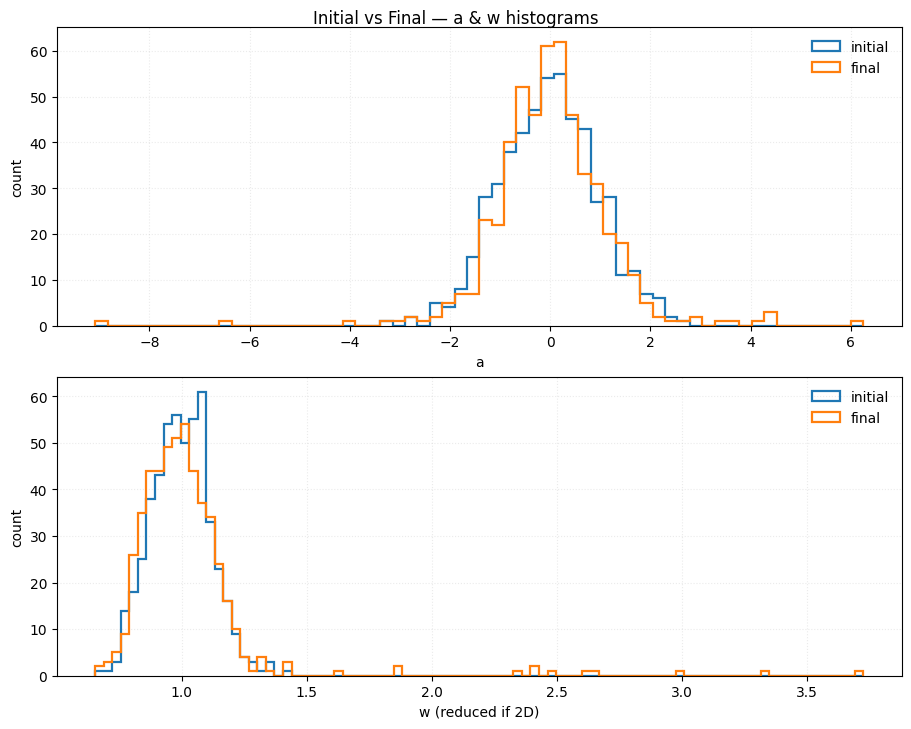

In [22]:
# %% Overlay histograms of a and w (initial vs final) — clear, unsmoothed
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional, Tuple, Union

# -------------------------
# Loading & coercion helpers
# -------------------------
def _to_numpy(x):
    """Convert torch/np to numpy array if possible."""
    try:
        import torch
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

def _find_w_a_in_mapping(mapping) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """Heuristically locate 'w' and 'a' inside nested dict-like objects."""
    import collections.abc as cab
    CAND_W = {"w", "weights", "W", "weight", "ws"}
    CAND_A = {"a", "alpha", "alphas", "A", "coeffs", "coefficients"}
    found_w, found_a = None, None

    def walk(obj):
        nonlocal found_w, found_a
        if isinstance(obj, cab.Mapping):
            for k, v in obj.items():
                key = str(k).lower()
                if key in CAND_W and found_w is None:
                    try: found_w = _to_numpy(v)
                    except Exception: pass
                if key in CAND_A and found_a is None:
                    try: found_a = _to_numpy(v)
                    except Exception: pass
                if isinstance(v, cab.Mapping):
                    walk(v)
                elif isinstance(v, (list, tuple)):
                    for vv in v: walk(vv)
    walk(mapping)
    return found_w, found_a

def _load_w_a_from_path(pathlike: Union[str, Path]) -> Tuple[np.ndarray, np.ndarray]:
    """Load w,a from .npy/.npz/.pt/.pth files."""
    p = Path(pathlike)
    suffix = p.suffix.lower()

    if suffix == ".npy":
        arr = np.load(p, allow_pickle=True)
        if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[0] == 2:
            return _to_numpy(arr[0]), _to_numpy(arr[1])
        raise ValueError("'.npy' expected shape (2, N): first row=w, second row=a.")

    if suffix == ".npz":
        data = np.load(p, allow_pickle=True)
        keys = list(data.keys())
        for wk in ["w", "weights", "W"]:
            if wk in data: w_vals = data[wk]; break
        else: w_vals = data[keys[0]]
        for ak in ["a", "alpha", "alphas", "A", "coeffs", "coefficients"]:
            if ak in data: a_vals = data[ak]; break
        else: a_vals = data[keys[1 if len(keys) > 1 else 0]]
        return _to_numpy(w_vals), _to_numpy(a_vals)

    if suffix in {".pt", ".pth"}:
        try:
            import torch
        except ImportError as e:
            raise ImportError("Torch is required to load .pt/.pth files.") from e
        obj = torch.load(p, map_location="cpu")

        if isinstance(obj, (list, tuple)) and len(obj) >= 2:
            return _to_numpy(obj[0]), _to_numpy(obj[1])

        if isinstance(obj, dict):
            w_raw, a_raw = _find_w_a_in_mapping(obj)
            if w_raw is None or a_raw is None:
                # Fallback: scan for plausible arrays
                cands = []

                def collect(o):
                    if isinstance(o, dict):
                        for v in o.values(): collect(v)
                    elif isinstance(o, (list, tuple)):
                        for v in o: collect(v)
                    else:
                        try:
                            arr = _to_numpy(o)
                            if isinstance(arr, np.ndarray) and arr.ndim in (1, 2) and arr.size > 0:
                                cands.append(arr)
                        except Exception:
                            pass
                collect(obj)

                one_d = [x for x in cands if x.ndim == 1]
                two_d = [x for x in cands if x.ndim == 2]
                if a_raw is None and one_d:
                    a_raw = max(one_d, key=lambda v: v.shape[0])
                if a_raw is not None and w_raw is None:
                    N = a_raw.shape[0]
                    matches_1d = [x for x in one_d if x is not a_raw and x.shape[0] == N]
                    if matches_1d:
                        w_raw = matches_1d[0]
                    else:
                        matches_2d = [X for X in two_d if N in X.shape]
                        if matches_2d: w_raw = matches_2d[0]
            if w_raw is None or a_raw is None:
                raise ValueError("Could not locate 'w' and 'a' in the .pt/.pth file.")
            return _to_numpy(w_raw), _to_numpy(a_raw)

        raise ValueError("Unsupported object stored in the .pt/.pth file.")

    raise ValueError(f"Unsupported file extension: {suffix}")

def _coerce_w_to_vector(w_raw: np.ndarray, a_len: int, w_reduce: str, w_component: Optional[int]) -> np.ndarray:
    """
    Make w a 1D vector of length a_len.
    If w_raw is 2D and one axis equals a_len, reduce along the other axis using:
      - 'norm' (L2 across features) [default]
      - 'mean' | 'sum'
      - 'component' (select a specific feature by index)
    """
    w_raw = np.asarray(w_raw)
    if w_raw.ndim == 1:
        if w_raw.shape[0] != a_len:
            raise ValueError(f"w is 1D length {w_raw.shape[0]} but a is length {a_len}.")
        return w_raw.astype(np.float64)

    if w_raw.ndim != 2:
        raise ValueError(f"w must be 1D or 2D; got shape {w_raw.shape}.")

    # Align so w_raw is (a_len, D)
    if w_raw.shape[0] == a_len:
        pass
    elif w_raw.shape[1] == a_len:
        w_raw = np.swapaxes(w_raw, 0, 1)
    else:
        raise ValueError(f"w is 2D {w_raw.shape}, but neither dimension equals len(a)={a_len}.")

    D = w_raw.shape[1]
    if w_reduce == "component":
        idx = 0 if (w_component is None) else int(w_component)
        if not (0 <= idx < D):
            raise ValueError(f"w_component {idx} out of range for D={D}.")
        w_vec = w_raw[:, idx]
    elif w_reduce == "norm":
        w_vec = np.linalg.norm(w_raw, axis=1)
    elif w_reduce == "mean":
        w_vec = w_raw.mean(axis=1)
    elif w_reduce == "sum":
        w_vec = w_raw.sum(axis=1)
    else:
        raise ValueError("w_reduce must be one of: 'norm'|'mean'|'sum'|'component'")
    return w_vec.astype(np.float64)

def _get_arrays(data_or_path, expect_pair=True):
    """
    Accept:
      - (w, a) arrays
      - a (2, N) array
      - a path to a supported file
    Return (w_raw, a_raw).
    """
    if isinstance(data_or_path, (str, Path)):
        return _load_w_a_from_path(data_or_path)
    arr = np.asarray(data_or_path, dtype=object)
    if isinstance(data_or_path, (list, tuple)) and len(data_or_path) == 2:
        return _to_numpy(data_or_path[0]), _to_numpy(data_or_path[1])
    if isinstance(arr, np.ndarray) and arr.ndim >= 2 and arr.shape[0] == 2:
        return _to_numpy(arr[0]), _to_numpy(arr[1])
    raise ValueError("data_or_path must be (w,a), a (2,N) array, or a path to a supported file.")

# -------------------------
# Main plotting function
# -------------------------
def plot_aw_hist_overlays(
    init_data: Union[Tuple[np.ndarray, np.ndarray], np.ndarray, str, Path],
    final_data: Union[Tuple[np.ndarray, np.ndarray], np.ndarray, str, Path],
    bins: Union[int, str] = "fd",          # integer or 'auto'/'fd'/'sqrt'/...
    range_mode: str = "full",              # 'full' or 'quantile'
    clip_percentiles: Tuple[float, float] = (0.1, 99.9),
    density: bool = False,                 # counts by default
    figsize: Tuple[float, float] = (9, 7),
    title: Optional[str] = "Initial vs Final — histograms of a and w",
    w_reduce: str = "norm",                # handling 2D w: 'norm'|'mean'|'sum'|'component'
    w_component: Optional[int] = None,     # used if w_reduce='component'
    save_path: Optional[str] = None,
):
    """
    Make two clear overlays:
      (1) histogram of a (initial vs final)
      (2) histogram of w (initial vs final; w reduced to 1D if needed)
    """
    # Load both models
    w0_raw, a0_raw = _get_arrays(init_data)
    w1_raw, a1_raw = _get_arrays(final_data)

    # Coerce arrays
    a0 = np.asarray(a0_raw, dtype=np.float64).ravel()
    a1 = np.asarray(a1_raw, dtype=np.float64).ravel()
    if a0.shape[0] != a1.shape[0]:
        # Not required to match, but warn if wildly different
        pass

    w0 = _coerce_w_to_vector(w0_raw, a_len=a0.shape[0], w_reduce=w_reduce, w_component=w_component)
    w1 = _coerce_w_to_vector(w1_raw, a_len=a1.shape[0], w_reduce=w_reduce, w_component=w_component)

    # Ranges & common bin edges (per variable)
    def common_edges(x, y, bins, range_mode, clip_percentiles):
        xy = np.concatenate([x, y])
        if range_mode == "full":
            r = (xy.min(), xy.max())
        elif range_mode == "quantile":
            r = tuple(np.percentile(xy, clip_percentiles))
        else:
            raise ValueError("range_mode must be 'full' or 'quantile'.")
        if isinstance(bins, (int, np.integer)):
            edges = np.linspace(r[0], r[1], int(bins) + 1)
        else:
            edges = np.histogram_bin_edges(xy, bins=bins, range=r)
        # degenerate range guard
        if not np.all(np.isfinite(edges)) or np.unique(edges).size < 2:
            lo, hi = float(np.nanmin(xy)), float(np.nanmax(xy))
            if hi == lo: hi = lo + 1e-9
            edges = np.linspace(lo, hi, 51)
        return edges

    a_edges = common_edges(a0, a1, bins, range_mode, clip_percentiles)
    w_edges = common_edges(w0, w1, bins, range_mode, clip_percentiles)

    # Plot
    fig, (ax_a, ax_w) = plt.subplots(2, 1, figsize=figsize, constrained_layout=True)

    # a hist overlay
    ax_a.hist(a0, bins=a_edges, density=density, histtype="step", linewidth=1.6, label="initial")
    ax_a.hist(a1, bins=a_edges, density=density, histtype="step", linewidth=1.6, label="final")
    ax_a.set_xlabel("a")
    ax_a.set_ylabel("count" if not density else "density")
    ax_a.grid(alpha=0.25, linestyle=":")
    ax_a.legend(frameon=False)

    # w hist overlay
    ax_w.hist(w0, bins=w_edges, density=density, histtype="step", linewidth=1.6, label="initial")
    ax_w.hist(w1, bins=w_edges, density=density, histtype="step", linewidth=1.6, label="final")
    ax_w.set_xlabel("w (reduced if 2D)")
    ax_w.set_ylabel("count" if not density else "density")
    ax_w.grid(alpha=0.25, linestyle=":")
    ax_w.legend(frameon=False)

    if title:
        fig.suptitle(title, y=1.02)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to: {save_path}")

    return fig, (ax_a, ax_w)

# -------------------------
# Example usage
# -------------------------
# Replace with your actual initial + final paths (or (w,a) arrays)
init_path  = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4_histo/d35_k4/init_model_P_10000_d_35_k_4_exp_0_kappa_0.007500_eta_5.000000e-04_gamma_0.500000.pt"
final_path = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4_histo/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.007500_eta_5.000000e-04_gamma_0.500000.pt"
fig, axes = plot_aw_hist_overlays(
    init_path,
    final_path,
    bins="fd",                 # or an int like 200
    range_mode="full",         # show ALL weights
    density=False,             # counts
    title="Initial vs Final — a & w histograms",
    w_reduce="norm",           # or 'component'
    w_component=None,          # e.g., 0 if w_reduce='component'
    save_path=None
)
plt.show()


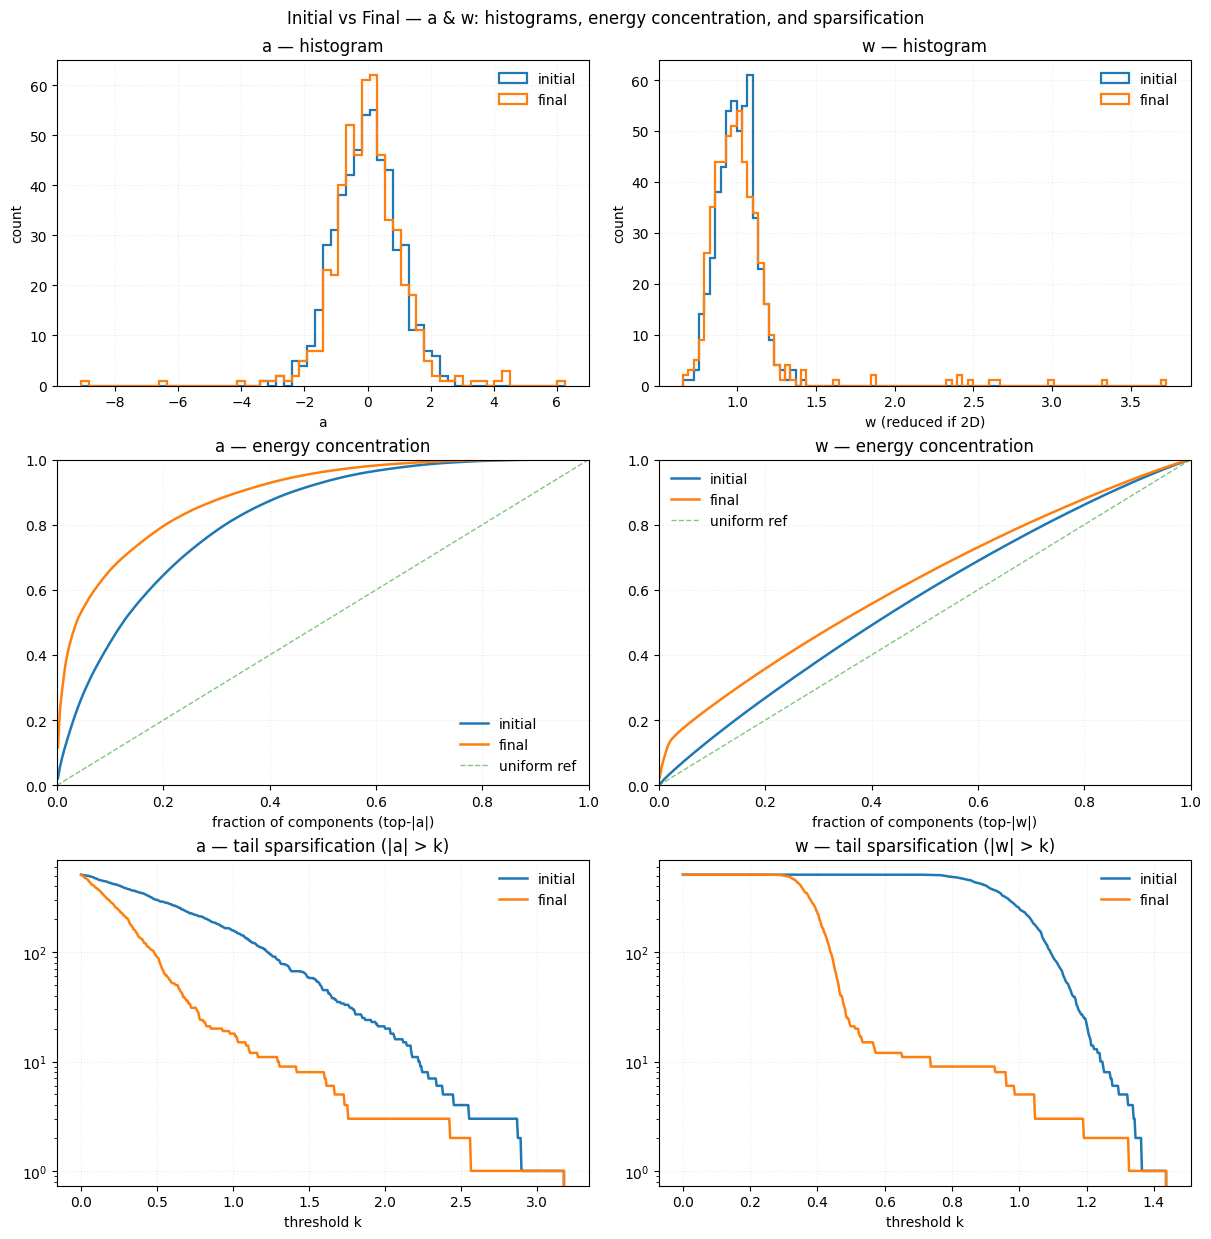

In [ ]:
# %% Overlay histograms of a and w (initial vs final) + energy concentration & sparsification + metrics
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional, Tuple, Union

# -------------------------
# Loading & coercion helpers
# -------------------------
def _to_numpy(x):
    """Convert torch/np to numpy array if possible."""
    try:
        import torch
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

def _find_w_a_in_mapping(mapping) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """Heuristically locate 'w' and 'a' inside nested dict-like objects."""
    import collections.abc as cab
    CAND_W = {"w", "weights", "W", "weight", "ws"}
    CAND_A = {"a", "alpha", "alphas", "A", "coeffs", "coefficients"}
    found_w, found_a = None, None

    def walk(obj):
        nonlocal found_w, found_a
        if isinstance(obj, cab.Mapping):
            for k, v in obj.items():
                key = str(k).lower()
                if key in CAND_W and found_w is None:
                    try: found_w = _to_numpy(v)
                    except Exception: pass
                if key in CAND_A and found_a is None:
                    try: found_a = _to_numpy(v)
                    except Exception: pass
                if isinstance(v, cab.Mapping):
                    walk(v)
                elif isinstance(v, (list, tuple)):
                    for vv in v: walk(vv)
    walk(mapping)
    return found_w, found_a

def _load_w_a_from_path(pathlike: Union[str, Path]) -> Tuple[np.ndarray, np.ndarray]:
    """Load w,a from .npy/.npz/.pt/.pth files."""
    p = Path(pathlike)
    suffix = p.suffix.lower()

    if suffix == ".npy":
        arr = np.load(p, allow_pickle=True)
        if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[0] == 2:
            return _to_numpy(arr[0]), _to_numpy(arr[1])
        raise ValueError("'.npy' expected shape (2, N): first row=w, second row=a.")

    if suffix == ".npz":
        data = np.load(p, allow_pickle=True)
        keys = list(data.keys())
        for wk in ["w", "weights", "W"]:
            if wk in data: w_vals = data[wk]; break
        else: w_vals = data[keys[0]]
        for ak in ["a", "alpha", "alphas", "A", "coeffs", "coefficients"]:
            if ak in data: a_vals = data[ak]; break
        else: a_vals = data[keys[1 if len(keys) > 1 else 0]]
        return _to_numpy(w_vals), _to_numpy(a_vals)

    if suffix in {".pt", ".pth"}:
        try:
            import torch
        except ImportError as e:
            raise ImportError("Torch is required to load .pt/.pth files.") from e
        obj = torch.load(p, map_location="cpu")

        if isinstance(obj, (list, tuple)) and len(obj) >= 2:
            return _to_numpy(obj[0]), _to_numpy(obj[1])

        if isinstance(obj, dict):
            w_raw, a_raw = _find_w_a_in_mapping(obj)
            if w_raw is None or a_raw is None:
                # Fallback: scan for plausible arrays
                cands = []

                def collect(o):
                    if isinstance(o, dict):
                        for v in o.values(): collect(v)
                    elif isinstance(o, (list, tuple)):
                        for v in o: collect(v)
                    else:
                        try:
                            arr = _to_numpy(o)
                            if isinstance(arr, np.ndarray) and arr.ndim in (1, 2) and arr.size > 0:
                                cands.append(arr)
                        except Exception:
                            pass
                collect(obj)

                one_d = [x for x in cands if x.ndim == 1]
                two_d = [x for x in cands if x.ndim == 2]
                if a_raw is None and one_d:
                    a_raw = max(one_d, key=lambda v: v.shape[0])
                if a_raw is not None and w_raw is None:
                    N = a_raw.shape[0]
                    matches_1d = [x for x in one_d if x is not a_raw and x.shape[0] == N]
                    if matches_1d:
                        w_raw = matches_1d[0]
                    else:
                        matches_2d = [X for X in two_d if N in X.shape]
                        if matches_2d: w_raw = matches_2d[0]
            if w_raw is None or a_raw is None:
                raise ValueError("Could not locate 'w' and 'a' in the .pt/.pth file.")
            return _to_numpy(w_raw), _to_numpy(a_raw)

        raise ValueError("Unsupported object stored in the .pt/.pth file.")

    raise ValueError(f"Unsupported file extension: {suffix}")

def _coerce_w_to_vector(w_raw: np.ndarray, a_len: int, w_reduce: str, w_component: Optional[int]) -> np.ndarray:
    """
    Make w a 1D vector of length a_len.
    If w_raw is 2D and one axis equals a_len, reduce along the other axis using:
      - 'norm' (L2 across features) [default]
      - 'mean' | 'sum'
      - 'component' (select a specific feature by index)
    """
    w_raw = np.asarray(w_raw)
    if w_raw.ndim == 1:
        if w_raw.shape[0] != a_len:
            raise ValueError(f"w is 1D length {w_raw.shape[0]} but a is length {a_len}.")
        return w_raw.astype(np.float64)

    if w_raw.ndim != 2:
        raise ValueError(f"w must be 1D or 2D; got shape {w_raw.shape}.")

    # Align so w_raw is (a_len, D)
    if w_raw.shape[0] == a_len:
        pass
    elif w_raw.shape[1] == a_len:
        w_raw = np.swapaxes(w_raw, 0, 1)
    else:
        raise ValueError(f"w is 2D {w_raw.shape}, but neither dimension equals len(a)={a_len}.")

    D = w_raw.shape[1]
    if w_reduce == "component":
        idx = 0 if (w_component is None) else int(w_component)
        if not (0 <= idx < D):
            raise ValueError(f"w_component {idx} out of range for D={D}.")
        w_vec = w_raw[:, idx]
    elif w_reduce == "norm":
        w_vec = np.linalg.norm(w_raw, axis=1)
    elif w_reduce == "mean":
        w_vec = w_raw.mean(axis=1)
    elif w_reduce == "sum":
        w_vec = w_raw.sum(axis=1)
    else:
        raise ValueError("w_reduce must be one of: 'norm'|'mean'|'sum'|'component'")
    return w_vec.astype(np.float64)

def _get_arrays(data_or_path, expect_pair=True):
    """
    Accept:
      - (w, a) arrays
      - a (2, N) array
      - a path to a supported file
    Return (w_raw, a_raw).
    """
    if isinstance(data_or_path, (str, Path)):
        return _load_w_a_from_path(data_or_path)
    arr = np.asarray(data_or_path, dtype=object)
    if isinstance(data_or_path, (list, tuple)) and len(data_or_path) == 2:
        return _to_numpy(data_or_path[0]), _to_numpy(data_or_path[1])
    if isinstance(arr, np.ndarray) and arr.ndim >= 2 and arr.shape[0] == 2:
        return _to_numpy(arr[0]), _to_numpy(arr[1])
    raise ValueError("data_or_path must be (w,a), a (2,N) array, or a path to a supported file.")

# -------------------------
# Metrics helpers
# -------------------------
def _energy_concentration_curve(x: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return (x_frac, energy_cum_frac):
      - sort |x| descending
      - energy_cum_frac[k] = sum_{i<=k} x_i^2 / sum_j x_j^2
      - x_frac[k] = (k+1)/N
    """
    x = np.asarray(x).ravel()
    mags = np.abs(x)
    order = np.argsort(-mags)  # descending by magnitude
    x_sorted = x[order]
    energy = x_sorted.astype(np.float64) ** 2
    total = energy.sum()
    if total <= 0:
        N = x.size if x.size else 1
        return np.linspace(1/N, 1.0, N), np.zeros(N)
    cum = np.cumsum(energy)
    N = x.size
    return np.linspace(1/N, 1.0, N), (cum / total)

def _top_p_energy(x: np.ndarray, p: float = 0.1) -> float:
    """Fraction of total L2 energy captured by the top p fraction of |x| (sorted by magnitude)."""
    x = np.asarray(x).ravel()
    N = x.size
    if N == 0:
        return 0.0
    k = max(1, int(np.ceil(p * N)))
    mags2 = np.sort(np.abs(x))**2
    top = mags2[-k:].sum()
    tot = mags2.sum()
    return 0.0 if tot <= 0 else float(top / tot)

def _hoyer_sparsity(x: np.ndarray) -> float:
    """
    Hoyer sparsity in [0,1]: (sqrt(N) - ||x||_1/||x||_2) / (sqrt(N) - 1).
    Define as 1.0 if x is the zero vector (maximally sparse).
    """
    x = np.asarray(x).ravel().astype(np.float64)
    N = x.size if x.size else 1
    l1 = np.sum(np.abs(x))
    l2 = np.linalg.norm(x)
    if l2 == 0:
        return 1.0
    return float((np.sqrt(N) - (l1 / l2)) / (np.sqrt(N) - 1.0))

def _gini_coefficient(x: np.ndarray) -> float:
    """
    Gini coefficient of |x| (0==equal, 1==all mass in one entry).
    """
    x = np.abs(np.asarray(x).ravel().astype(np.float64))
    N = x.size
    if N == 0:
        return 0.0
    mean = x.mean()
    if mean == 0:
        return 0.0
    # Based on the mean absolute difference formulation:
    # G = MAD / (2 * mean), where MAD = average of |xi - xj|
    diffs = np.abs(x[:, None] - x[None, :])
    mad = diffs.mean()
    return float(mad / (2.0 * mean))

def _tail_counts_over_thresholds(x: np.ndarray, num_k: int = 512, mode: str = "quantile+max") -> Tuple[np.ndarray, np.ndarray]:
    """
    Build a threshold grid k and count how many entries satisfy |x| > k.
    - mode='quantile+max': dense grid up to high quantile, and ensure inclusion of the true max to capture outliers.
    """
    x = np.asarray(x).ravel()
    mags = np.abs(x)
    if mags.size == 0:
        return np.array([0.0]), np.array([0])
    q_hi = np.nanpercentile(mags, 99.9)
    k_min = 0.0
    k_max = float(np.nanmax(mags))
    if not np.isfinite(k_max): k_max = 0.0
    base = np.linspace(k_min, max(q_hi, k_min), num_k, endpoint=True)
    tail = np.linspace(max(q_hi, k_min), k_max, max(8, num_k // 16), endpoint=True)
    k = np.unique(np.concatenate([base, tail]))
    mags_sorted = np.sort(mags)
    idx = np.searchsorted(mags_sorted, k, side='right')
    counts = mags_sorted.size - idx
    return k, counts

# -------------------------
# Main plotting function
# -------------------------
def plot_aw_hist_overlays(
    init_data: Union[Tuple[np.ndarray, np.ndarray], np.ndarray, str, Path],
    final_data: Union[Tuple[np.ndarray, np.ndarray], np.ndarray, str, Path],
    bins: Union[int, str] = "fd",          # integer or 'auto'/'fd'/'sqrt'/...
    range_mode: str = "full",              # 'full' or 'quantile'
    clip_percentiles: Tuple[float, float] = (0.1, 99.9),
    density: bool = False,                 # counts by default
    figsize: Tuple[float, float] = (12, 12),
    title: Optional[str] = "Initial vs Final — a & w: histograms, energy concentration, and sparsification",
    w_reduce: str = "norm",                # handling 2D w: 'norm'|'mean'|'sum'|'component'
    w_component: Optional[int] = None,     # used if w_reduce='component'
    save_path: Optional[str] = None,
    log_tail_y: bool = True,               # log-scale the y-axis for tail-count plots
    # --- New metric parameters ---
    top_p: float = 0.10,                   # top-p energy (fraction, e.g., 0.10 == top 10%)
    a_thresh: float = 2.0,                 # count |a| > a_thresh
    w_thresh: float = 1.0,                 # count |w| > w_thresh
):
    """
    Make six overlays + metric annotations:
      Row 1: histogram of a; histogram of w (initial vs final)  [annotate Hoyer & Gini]
      Row 2: energy concentration of a; energy concentration of w  [annotate Top-p energy]
      Row 3: tail counts (# {|a|>k} vs k); tail counts (# {|w|>k} vs k)  [annotate fixed-threshold counts]
    """
    # Load both models
    w0_raw, a0_raw = _get_arrays(init_data)
    w1_raw, a1_raw = _get_arrays(final_data)

    # Coerce arrays
    a0 = np.asarray(a0_raw, dtype=np.float64).ravel()
    a1 = np.asarray(a1_raw, dtype=np.float64).ravel()

    w0 = _coerce_w_to_vector(w0_raw, a_len=a0.shape[0], w_reduce=w_reduce, w_component=w_component)
    w1 = _coerce_w_to_vector(w1_raw, a_len=a1.shape[0], w_reduce=w_reduce, w_component=w_component)

    # Ranges & common bin edges (per variable)
    def common_edges(x, y, bins, range_mode, clip_percentiles):
        xy = np.concatenate([x, y])
        if range_mode == "full":
            r = (np.nanmin(xy), np.nanmax(xy))
        elif range_mode == "quantile":
            r = tuple(np.nanpercentile(xy, clip_percentiles))
        else:
            raise ValueError("range_mode must be 'full' or 'quantile'.")
        if isinstance(bins, (int, np.integer)):
            edges = np.linspace(r[0], r[1], int(bins) + 1)
        else:
            edges = np.histogram_bin_edges(xy, bins=bins, range=r)
        if not np.all(np.isfinite(edges)) or np.unique(edges).size < 2:
            lo, hi = float(np.nanmin(xy)), float(np.nanmax(xy))
            if hi == lo: hi = lo + 1e-9
            edges = np.linspace(lo, hi, 51)
        return edges

    a_edges = common_edges(a0, a1, bins, range_mode, clip_percentiles)
    w_edges = common_edges(w0, w1, bins, range_mode, clip_percentiles)

    # Compute curves
    a0_xfrac, a0_ec = _energy_concentration_curve(a0)
    a1_xfrac, a1_ec = _energy_concentration_curve(a1)
    w0_xfrac, w0_ec = _energy_concentration_curve(w0)
    w1_xfrac, w1_ec = _energy_concentration_curve(w1)

    ak, a_cnt0 = _tail_counts_over_thresholds(a0)
    _,  a_cnt1 = _tail_counts_over_thresholds(a1)
    wk, w_cnt0 = _tail_counts_over_thresholds(w0)
    _,  w_cnt1 = _tail_counts_over_thresholds(w1)

    # --- Metrics
    # Top-p energy
    a_top_init = _top_p_energy(a0, top_p)
    a_top_final = _top_p_energy(a1, top_p)
    w_top_init = _top_p_energy(w0, top_p)
    w_top_final = _top_p_energy(w1, top_p)

    # Hoyer & Gini
    a_h_init, a_h_final = _hoyer_sparsity(a0), _hoyer_sparsity(a1)
    w_h_init, w_h_final = _hoyer_sparsity(w0), _hoyer_sparsity(w1)
    a_g_init, a_g_final = _gini_coefficient(a0), _gini_coefficient(a1)
    w_g_init, w_g_final = _gini_coefficient(w0), _gini_coefficient(w1)

    # Fixed-threshold counts
    a_cnt_init_thr = int((np.abs(a0) > a_thresh).sum())
    a_cnt_final_thr = int((np.abs(a1) > a_thresh).sum())
    w_cnt_init_thr = int((np.abs(w0) > w_thresh).sum())
    w_cnt_final_thr = int((np.abs(w1) > w_thresh).sum())

    # Plot (3 rows x 2 cols)
    fig, axes = plt.subplots(3, 2, figsize=figsize, constrained_layout=True)
    (ax_a_hist, ax_w_hist), (ax_a_ec, ax_w_ec), (ax_a_tail, ax_w_tail) = axes

    # --- Row 1: histograms
    ax_a_hist.hist(a0, bins=a_edges, density=density, histtype="step", linewidth=1.6, label="initial")
    ax_a_hist.hist(a1, bins=a_edges, density=density, histtype="step", linewidth=1.6, label="final")
    ax_a_hist.set_xlabel("a")
    ax_a_hist.set_ylabel("count" if not density else "density")
    ax_a_hist.grid(alpha=0.25, linestyle=":")
    ax_a_hist.legend(frameon=False)
    ax_a_hist.set_title("a — histogram")
    # annotate Hoyer & Gini (a)
    txt = (f"Init  H={a_h_init:.3f}, G={a_g_init:.3f}\n"
           f"Final H={a_h_final:.3f}, G={a_g_final:.3f}")
    ax_a_hist.text(0.02, 0.98, txt, transform=ax_a_hist.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    ax_w_hist.hist(w0, bins=w_edges, density=density, histtype="step", linewidth=1.6, label="initial")
    ax_w_hist.hist(w1, bins=w_edges, density=density, histtype="step", linewidth=1.6, label="final")
    ax_w_hist.set_xlabel("w (reduced if 2D)")
    ax_w_hist.set_ylabel("count" if not density else "density")
    ax_w_hist.grid(alpha=0.25, linestyle=":")
    ax_w_hist.legend(frameon=False)
    ax_w_hist.set_title("w — histogram")
    # annotate Hoyer & Gini (w)
    txt = (f"Init  H={w_h_init:.3f}, G={w_g_init:.3f}\n"
           f"Final H={w_h_final:.3f}, G={w_g_final:.3f}")
    ax_w_hist.text(0.02, 0.98, txt, transform=ax_w_hist.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    # --- Row 2: energy concentration (Lorenz-like) curves
    ax_a_ec.plot(a0_xfrac, a0_ec, lw=1.8, label="initial")
    ax_a_ec.plot(a1_xfrac, a1_ec, lw=1.8, label="final")
    ax_a_ec.plot([0,1], [0,1], lw=1.0, linestyle="--", alpha=0.6, label="uniform ref")
    ax_a_ec.set_xlabel("fraction of components (top-|a|)")
    ax_a_ec.set_ylabel(r"cumulative energy  $\sum_{i\le k} a_{(i)}^2 / \sum_j a_j^2$")
    ax_a_ec.set_xlim(0, 1)
    ax_a_ec.set_ylim(0, 1)
    ax_a_ec.grid(alpha=0.25, linestyle=":")
    ax_a_ec.legend(frameon=False)
    ax_a_ec.set_title("a — energy concentration")
    # annotate top-p energy (a)
    ax_a_ec.text(0.02, 0.98,
                 f"Top-{int(top_p*100)}% energy:\n"
                 f"Init {a_top_init:.3f}, Final {a_top_final:.3f}",
                 transform=ax_a_ec.transAxes, va="top", ha="left",
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    ax_w_ec.plot(w0_xfrac, w0_ec, lw=1.8, label="initial")
    ax_w_ec.plot(w1_xfrac, w1_ec, lw=1.8, label="final")
    ax_w_ec.plot([0,1], [0,1], lw=1.0, linestyle="--", alpha=0.6, label="uniform ref")
    ax_w_ec.set_xlabel("fraction of components (top-|w|)")
    ax_w_ec.set_ylabel(r"cumulative energy  $\sum_{i\le k} w_{(i)}^2 / \sum_j w_j^2$")
    ax_w_ec.set_xlim(0, 1)
    ax_w_ec.set_ylim(0, 1)
    ax_w_ec.grid(alpha=0.25, linestyle=":")
    ax_w_ec.legend(frameon=False)
    ax_w_ec.set_title("w — energy concentration")
    # annotate top-p energy (w)
    ax_w_ec.text(0.02, 0.98,
                 f"Top-{int(top_p*100)}% energy:\n"
                 f"Init {w_top_init:.3f}, Final {w_top_final:.3f}",
                 transform=ax_w_ec.transAxes, va="top", ha="left",
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    # --- Row 3: tail counts (# {|x| > k} vs k)
    ax_a_tail.plot(ak, a_cnt0, lw=1.8, label="initial")
    ax_a_tail.plot(ak, a_cnt1, lw=1.8, label="final")
    ax_a_tail.axvline(a_thresh, ls="--", alpha=0.5)
    ax_a_tail.set_xlabel("threshold k")
    ax_a_tail.set_ylabel(r"count of $\{|a|>k\}$")
    if log_tail_y:
        ax_a_tail.set_yscale("log")
    ax_a_tail.grid(alpha=0.25, linestyle=":")
    ax_a_tail.legend(frameon=False)
    ax_a_tail.set_title("a — tail sparsification (|a| > k)")
    # annotate fixed-threshold counts (a)
    ax_a_tail.text(0.02, 0.98,
                   f"|a|>{a_thresh:g}:\n"
                   f"Init {a_cnt_init_thr}, Final {a_cnt_final_thr}",
                   transform=ax_a_tail.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    ax_w_tail.plot(wk, w_cnt0, lw=1.8, label="initial")
    ax_w_tail.plot(wk, w_cnt1, lw=1.8, label="final")
    ax_w_tail.axvline(w_thresh, ls="--", alpha=0.5)
    ax_w_tail.set_xlabel("threshold k")
    ax_w_tail.set_ylabel(r"count of $\{|w|>k\}$")
    if log_tail_y:
        ax_w_tail.set_yscale("log")
    ax_w_tail.grid(alpha=0.25, linestyle=":")
    ax_w_tail.legend(frameon=False)
    ax_w_tail.set_title("w — tail sparsification (|w| > k)")
    # annotate fixed-threshold counts (w)
    ax_w_tail.text(0.02, 0.98,
                   f"|w|>{w_thresh:g}:\n"
                   f"Init {w_cnt_init_thr}, Final {w_cnt_final_thr}",
                   transform=ax_w_tail.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    if title:
        fig.suptitle(title, y=1.02)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to: {save_path}")

    # Also print a concise summary to stdout
    print(f"[Top-{int(top_p*100)}% energy]  a: init={a_top_init:.4f}, final={a_top_final:.4f} | "
          f"w: init={w_top_init:.4f}, final={w_top_final:.4f}")
    print(f"[Hoyer] a: init={a_h_init:.4f}, final={a_h_final:.4f} | w: init={w_h_init:.4f}, final={w_h_final:.4f}")
    print(f"[Gini ] a: init={a_g_init:.4f}, final={a_g_final:.4f} | w: init={w_g_init:.4f}, final={w_g_final:.4f}")
    print(f"[Counts > thr]  |a|>{a_thresh:g}: init={a_cnt_init_thr}, final={a_cnt_final_thr} | "
          f"|w|>{w_thresh:g}: init={w_cnt_init_thr}, final={w_cnt_final_thr}")

    return fig, axes

# -------------------------
# Example usage
# -------------------------
if __name__ == "__main__":
    # Replace with your actual initial + final paths (or (w,a) arrays)
    init_path  = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4_histo/d35_k4/init_model_P_10000_d_35_k_4_exp_0_kappa_0.007500_eta_5.000000e-04_gamma_0.500000.pt"
    final_path = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4_histo/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.007500_eta_5.000000e-04_gamma_0.500000e-04_gamma_0.500000.pt".replace("0.500000e-04_gamma_0.500000.pt","0.500000.pt")
    fig, axes = plot_aw_hist_overlays(
        init_path,
        final_path,
        bins="fd",
        range_mode="full",
        density=False,
        title="Initial vs Final — a & w: histograms, energy concentration, sparsification + metrics",
        w_reduce="norm",
        w_component=None,
        save_path=None,
        log_tail_y=True,
        top_p=0.10,        # Top-10% energy
        a_thresh=2.0,      # Count |a|>2
        w_thresh=1.0       # Count |w|>1
    )
    import matplotlib.pyplot as plt
    plt.show()


In [3]:
# %% Overlay histograms of a and w (initial vs final) + energy concentration, sparsification, and correlation counts
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional, Tuple, Union, Callable

# -------------------------
# Loading & coercion helpers
# -------------------------
def _to_numpy(x):
    """Convert torch/np to numpy array if possible."""
    try:
        import torch
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

def _find_w_a_in_mapping(mapping) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """Heuristically locate 'w' and 'a' inside nested dict-like objects."""
    import collections.abc as cab
    CAND_W = {"w", "weights", "W", "weight", "ws"}
    CAND_A = {"a", "alpha", "alphas", "A", "coeffs", "coefficients"}
    found_w, found_a = None, None

    def walk(obj):
        nonlocal found_w, found_a
        if isinstance(obj, cab.Mapping):
            for k, v in obj.items():
                key = str(k).lower()
                if key in CAND_W and found_w is None:
                    try: found_w = _to_numpy(v)
                    except Exception: pass
                if key in CAND_A and found_a is None:
                    try: found_a = _to_numpy(v)
                    except Exception: pass
                if isinstance(v, cab.Mapping):
                    walk(v)
                elif isinstance(v, (list, tuple)):
                    for vv in v: walk(vv)
    walk(mapping)
    return found_w, found_a

def _load_w_a_from_path(pathlike: Union[str, Path]) -> Tuple[np.ndarray, np.ndarray]:
    """Load w,a from .npy/.npz/.pt/.pth files."""
    p = Path(pathlike)
    suffix = p.suffix.lower()

    if suffix == ".npy":
        arr = np.load(p, allow_pickle=True)
        if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[0] == 2:
            return _to_numpy(arr[0]), _to_numpy(arr[1])
        raise ValueError("'.npy' expected shape (2, N): first row=w, second row=a.")

    if suffix == ".npz":
        data = np.load(p, allow_pickle=True)
        keys = list(data.keys())
        for wk in ["w", "weights", "W"]:
            if wk in data: w_vals = data[wk]; break
        else: w_vals = data[keys[0]]
        for ak in ["a", "alpha", "alphas", "A", "coeffs", "coefficients"]:
            if ak in data: a_vals = data[ak]; break
        else: a_vals = data[keys[1 if len(keys) > 1 else 0]]
        return _to_numpy(w_vals), _to_numpy(a_vals)

    if suffix in {".pt", ".pth"}:
        try:
            import torch
        except ImportError as e:
            raise ImportError("Torch is required to load .pt/.pth files.") from e
        obj = torch.load(p, map_location="cpu")

        if isinstance(obj, (list, tuple)) and len(obj) >= 2:
            return _to_numpy(obj[0]), _to_numpy(obj[1])

        if isinstance(obj, dict):
            w_raw, a_raw = _find_w_a_in_mapping(obj)
            if w_raw is None or a_raw is None:
                # Fallback: scan for plausible arrays
                cands = []

                def collect(o):
                    if isinstance(o, dict):
                        for v in o.values(): collect(v)
                    elif isinstance(o, (list, tuple)):
                        for v in o: collect(v)
                    else:
                        try:
                            arr = _to_numpy(o)
                            if isinstance(arr, np.ndarray) and arr.ndim in (1, 2) and arr.size > 0:
                                cands.append(arr)
                        except Exception:
                            pass
                collect(obj)

                one_d = [x for x in cands if x.ndim == 1]
                two_d = [x for x in cands if x.ndim == 2]
                if a_raw is None and one_d:
                    a_raw = max(one_d, key=lambda v: v.shape[0])
                if a_raw is not None and w_raw is None:
                    N = a_raw.shape[0]
                    matches_1d = [x for x in one_d if x is not a_raw and x.shape[0] == N]
                    if matches_1d:
                        w_raw = matches_1d[0]
                    else:
                        matches_2d = [X for X in two_d if N in X.shape]
                        if matches_2d: w_raw = matches_2d[0]
            if w_raw is None or a_raw is None:
                raise ValueError("Could not locate 'w' and 'a' in the .pt/.pth file.")
            return _to_numpy(w_raw), _to_numpy(a_raw)

        raise ValueError("Unsupported object stored in the .pt/.pth file.")

    raise ValueError(f"Unsupported file extension: {suffix}")

# --- w coercions
def _coerce_w_to_vector(w_raw: np.ndarray, a_len: int, w_reduce: str, w_component: Optional[int]) -> np.ndarray:
    """
    Make w a 1D vector of length a_len.
    If w_raw is 2D and one axis equals a_len, reduce along the other axis using:
      - 'norm' (L2 across features) [default]
      - 'mean' | 'sum'
      - 'component' (select a specific feature by index)
    """
    w_raw = np.asarray(w_raw)
    if w_raw.ndim == 1:
        if w_raw.shape[0] != a_len:
            raise ValueError(f"w is 1D length {w_raw.shape[0]} but a is length {a_len}.")
        return w_raw.astype(np.float64)

    if w_raw.ndim != 2:
        raise ValueError(f"w must be 1D or 2D; got shape {w_raw.shape}.")

    # Align so w_raw is (a_len, D)
    if w_raw.shape[0] == a_len:
        pass
    elif w_raw.shape[1] == a_len:
        w_raw = np.swapaxes(w_raw, 0, 1)
    else:
        raise ValueError(f"w is 2D {w_raw.shape}, but neither dimension equals len(a)={a_len}.")

    D = w_raw.shape[1]
    if w_reduce == "component":
        idx = 0 if (w_component is None) else int(w_component)
        if not (0 <= idx < D):
            raise ValueError(f"w_component {idx} out of range for D={D}.")
        w_vec = w_raw[:, idx]
    elif w_reduce == "norm":
        w_vec = np.linalg.norm(w_raw, axis=1)
    elif w_reduce == "mean":
        w_vec = w_raw.mean(axis=1)
    elif w_reduce == "sum":
        w_vec = w_raw.sum(axis=1)
    else:
        raise ValueError("w_reduce must be one of: 'norm'|'mean'|'sum'|'component'")
    return w_vec.astype(np.float64)

def _coerce_w_to_matrix_for_X(w_raw: np.ndarray, a_len: int, x_dim: int) -> Optional[np.ndarray]:
    """
    Align w into a matrix W of shape (N=a_len, D=x_dim) for computing phi(Wx).
    Returns None if alignment is impossible.
    """
    W = np.asarray(w_raw)
    if W.ndim == 1:
        if W.shape[0] == a_len and x_dim == 1:
            return W.reshape(-1, 1).astype(np.float64)
        # Rare case: a single neuron with D features
        if a_len == 1 and W.shape[0] == x_dim:
            return W.reshape(1, -1).astype(np.float64)
        return None

    if W.ndim != 2:
        return None

    # Try to orient so rows are neurons and columns match x_dim
    if W.shape[0] == a_len and W.shape[1] == x_dim:
        return W.astype(np.float64)
    if W.shape[1] == a_len and W.shape[0] == x_dim:
        return W.T.astype(np.float64)

    # If one axis is a_len, we can't guess D if it doesn't equal x_dim
    return None

def _get_arrays(data_or_path, expect_pair=True):
    """
    Accept:
      - (w, a) arrays
      - a (2, N) array
      - a path to a supported file
    Return (w_raw, a_raw).
    """
    if isinstance(data_or_path, (str, Path)):
        return _load_w_a_from_path(data_or_path)
    arr = np.asarray(data_or_path, dtype=object)
    if isinstance(data_or_path, (list, tuple)) and len(data_or_path) == 2:
        return _to_numpy(data_or_path[0]), _to_numpy(data_or_path[1])
    if isinstance(arr, np.ndarray) and arr.ndim >= 2 and arr.shape[0] == 2:
        return _to_numpy(arr[0]), _to_numpy(arr[1])
    raise ValueError("data_or_path must be (w,a), a (2,N) array, or a path to a supported file.")

# -------------------------
# Metrics helpers
# -------------------------
def _energy_concentration_curve(x: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Return (x_frac, cumulative energy fraction) for components sorted by |x| desc."""
    x = np.asarray(x).ravel()
    mags = np.abs(x)
    order = np.argsort(-mags)
    energy = (x[order].astype(np.float64)) ** 2
    total = energy.sum()
    if total <= 0:
        N = x.size if x.size else 1
        return np.linspace(1/N, 1.0, N), np.zeros(N)
    cum = np.cumsum(energy)
    N = x.size
    return np.linspace(1/N, 1.0, N), (cum / total)

def _top_p_energy(x: np.ndarray, p: float = 0.1) -> float:
    """Fraction of total L2 energy captured by the top p fraction of |x|."""
    x = np.asarray(x).ravel()
    N = x.size
    if N == 0:
        return 0.0
    k = max(1, int(np.ceil(p * N)))
    mags2 = np.sort(np.abs(x))**2
    top = mags2[-k:].sum()
    tot = mags2.sum()
    return 0.0 if tot <= 0 else float(top / tot)

def _hoyer_sparsity(x: np.ndarray) -> float:
    """Hoyer sparsity in [0,1]."""
    x = np.asarray(x).ravel().astype(np.float64)
    N = x.size if x.size else 1
    l1 = np.sum(np.abs(x))
    l2 = np.linalg.norm(x)
    if l2 == 0:
        return 1.0
    return float((np.sqrt(N) - (l1 / l2)) / (np.sqrt(N) - 1.0))

def _gini_coefficient(x: np.ndarray) -> float:
    """Gini coefficient of |x|."""
    x = np.abs(np.asarray(x).ravel().astype(np.float64))
    N = x.size
    if N == 0:
        return 0.0
    mean = x.mean()
    if mean == 0:
        return 0.0
    diffs = np.abs(x[:, None] - x[None, :])
    mad = diffs.mean()
    return float(mad / (2.0 * mean))

def _tail_counts_over_thresholds(x: np.ndarray, num_k: int = 512) -> Tuple[np.ndarray, np.ndarray]:
    """Threshold grid k and counts of |x|>k, ensuring we include the global max to show outliers."""
    x = np.asarray(x).ravel()
    mags = np.abs(x)
    if mags.size == 0:
        return np.array([0.0]), np.array([0])
    q_hi = np.nanpercentile(mags, 99.9)
    k_min = 0.0
    k_max = float(np.nanmax(mags))
    if not np.isfinite(k_max): k_max = 0.0
    base = np.linspace(k_min, max(q_hi, k_min), num_k, endpoint=True)
    tail = np.linspace(max(q_hi, k_min), k_max, max(8, num_k // 16), endpoint=True)
    k = np.unique(np.concatenate([base, tail]))
    mags_sorted = np.sort(mags)
    idx = np.searchsorted(mags_sorted, k, side='right')
    counts = mags_sorted.size - idx
    return k, counts

# -------------------------
# Correlation helpers (needs X, y)
# -------------------------
def _get_phi(phi: Union[str, Callable[[np.ndarray], np.ndarray]]) -> Callable[[np.ndarray], np.ndarray]:
    """Return an activation function."""
    if callable(phi):
        return phi
    key = str(phi).lower()
    if key == "tanh":
        return np.tanh
    if key == "relu":
        return lambda z: np.maximum(0.0, z)
    if key == "sigmoid":
        return lambda z: 1.0 / (1.0 + np.exp(-z))
    if key == "gelu":
        # tanh-based GELU approximation (no scipy needed)
        return lambda z: 0.5 * z * (1.0 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))
    if key == "identity":
        return lambda z: z
    raise ValueError(f"Unknown activation '{phi}'. Provide 'tanh', 'relu', 'sigmoid', 'gelu', 'identity', or a callable.")

def _pearson_colwise(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Column-wise Pearson correlation between columns of A (M x N) and vector y (M,)."""
    A = np.asarray(A, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64).ravel()
    if A.ndim != 2:
        raise ValueError("A must be 2D (M x N).")
    if y.ndim != 1 or y.shape[0] != A.shape[0]:
        raise ValueError("y must be shape (M,) matching A.shape[0].")
    y_c = y - y.mean()
    y_den = np.sqrt(np.sum(y_c**2))
    if y_den == 0:
        return np.zeros(A.shape[1], dtype=np.float64)
    A_c = A - A.mean(axis=0, keepdims=True)
    A_den = np.sqrt(np.sum(A_c**2, axis=0)) + 1e-12
    num = np.sum(A_c * y_c[:, None], axis=0)
    r = num / (A_den * y_den)
    return np.clip(r, -1.0, 1.0)

def _corr_counts_k(W: np.ndarray,
                   a: np.ndarray,
                   X: np.ndarray,
                   y: np.ndarray,
                   phi: Callable[[np.ndarray], np.ndarray],
                   abs_corr: bool = True,
                   num_k: int = 400) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute thresholds k in [0,1] and counts of neurons whose correlation exceeds k:
      - h_i(x)   = phi(w_i^T x)
      - s_i(x)   = a_i * phi(w_i^T x)
    Returns (k_grid, counts_phi, counts_a_phi).
    """
    M, D = X.shape
    N, D_check = W.shape
    if D_check != D or a.shape[0] != N:
        raise ValueError(f"Shape mismatch: W({W.shape}), a({a.shape}), X({X.shape}).")

    Z = X @ W.T            # (M, N)
    H = phi(Z)             # (M, N)
    S = H * a.reshape(1, -1)  # (M, N)

    r_h = _pearson_colwise(H, y)
    r_s = _pearson_colwise(S, y)

    r_h = np.abs(r_h) if abs_corr else r_h
    r_s = np.abs(r_s) if abs_corr else r_s

    k = np.linspace(0.0, 1.0, num_k, endpoint=True)
    # counts of correlations strictly greater than k
    r_h_sorted = np.sort(r_h)
    r_s_sorted = np.sort(r_s)
    # Using searchsorted on sorted ascending arrays
    idx_h = np.searchsorted(r_h_sorted, k, side="right")
    idx_s = np.searchsorted(r_s_sorted, k, side="right")
    cnt_h = r_h_sorted.size - idx_h
    cnt_s = r_s_sorted.size - idx_s
    return k, cnt_h, cnt_s

# -------------------------
# Main plotting function
# -------------------------
def plot_aw_hist_overlays(
    init_data: Union[Tuple[np.ndarray, np.ndarray], np.ndarray, str, Path],
    final_data: Union[Tuple[np.ndarray, np.ndarray], np.ndarray, str, Path],
    bins: Union[int, str] = "fd",          # integer or 'auto'/'fd'/'sqrt'/...
    range_mode: str = "full",              # 'full' or 'quantile'
    clip_percentiles: Tuple[float, float] = (0.1, 99.9),
    density: bool = False,                 # counts by default
    figsize: Tuple[float, float] = (12, 16),
    title: Optional[str] = "Initial vs Final — a & w: histograms, energy, sparsification, and correlations",
    w_reduce: str = "norm",                # handling 2D w -> 1D: 'norm'|'mean'|'sum'|'component'
    w_component: Optional[int] = None,     # used if w_reduce='component'
    save_path: Optional[str] = None,
    log_tail_y: bool = True,               # log-scale the y-axis for tail-count plots

    # --- Metric parameters ---
    top_p: float = 0.10,                   # top-p energy (fraction, e.g., 0.10 == top 10%)
    a_thresh: float = 2.0,                 # count |a| > a_thresh
    w_thresh: float = 1.0,                 # count |w| > w_thresh

    # --- Correlation plot parameters (requires X and y) ---
    X: Optional[np.ndarray] = None,        # shape (num_samples, input_dim)
    y: Optional[np.ndarray] = None,        # shape (num_samples,)
    phi: Union[str, Callable[[np.ndarray], np.ndarray]] = "tanh",
    corr_abs: bool = True,
    corr_num_k: int = 400,
    corr_k_lines: Tuple[float, ...] = (0.2, 0.5, 0.8),
    corr_report_k: float = 0.5,
):
    """
    Creates eight panels:
      Row 1: histogram of a; histogram of w (initial vs final)  [annotate Hoyer & Gini]
      Row 2: energy concentration of a; energy concentration of w  [annotate Top-p energy]
      Row 3: tail counts (# {|a|>k}); tail counts (# {|w|>k})      [annotate fixed-threshold counts]
      Row 4: counts of neurons with corr_y(phi(w·x)) > k; counts with corr_y(a_i·phi(w_i·x)) > k (if X,y provided)
    """
    # Load both models
    w0_raw, a0_raw = _get_arrays(init_data)
    w1_raw, a1_raw = _get_arrays(final_data)

    # Coerce arrays for histogram/tail/energy
    a0 = np.asarray(a0_raw, dtype=np.float64).ravel()
    a1 = np.asarray(a1_raw, dtype=np.float64).ravel()
    w0 = _coerce_w_to_vector(w0_raw, a_len=a0.shape[0], w_reduce=w_reduce, w_component=w_component)
    w1 = _coerce_w_to_vector(w1_raw, a_len=a1.shape[0], w_reduce=w_reduce, w_component=w_component)

    # Ranges & common bin edges (per variable)
    def common_edges(x, y, bins, range_mode, clip_percentiles):
        xy = np.concatenate([x, y])
        if range_mode == "full":
            r = (np.nanmin(xy), np.nanmax(xy))
        elif range_mode == "quantile":
            r = tuple(np.nanpercentile(xy, clip_percentiles))
        else:
            raise ValueError("range_mode must be 'full' or 'quantile'.")
        if isinstance(bins, (int, np.integer)):
            edges = np.linspace(r[0], r[1], int(bins) + 1)
        else:
            edges = np.histogram_bin_edges(xy, bins=bins, range=r)
        if not np.all(np.isfinite(edges)) or np.unique(edges).size < 2:
            lo, hi = float(np.nanmin(xy)), float(np.nanmax(xy))
            if hi == lo: hi = lo + 1e-9
            edges = np.linspace(lo, hi, 51)
        return edges

    a_edges = common_edges(a0, a1, bins, range_mode, clip_percentiles)
    w_edges = common_edges(w0, w1, bins, range_mode, clip_percentiles)

    # Compute curves
    a0_xfrac, a0_ec = _energy_concentration_curve(a0)
    a1_xfrac, a1_ec = _energy_concentration_curve(a1)
    w0_xfrac, w0_ec = _energy_concentration_curve(w0)
    w1_xfrac, w1_ec = _energy_concentration_curve(w1)

    ak, a_cnt0 = _tail_counts_over_thresholds(a0)
    _,  a_cnt1 = _tail_counts_over_thresholds(a1)
    wk, w_cnt0 = _tail_counts_over_thresholds(w0)
    _,  w_cnt1 = _tail_counts_over_thresholds(w1)

    # --- Metrics
    # Top-p energy
    a_top_init = _top_p_energy(a0, top_p)
    a_top_final = _top_p_energy(a1, top_p)
    w_top_init = _top_p_energy(w0, top_p)
    w_top_final = _top_p_energy(w1, top_p)

    # Hoyer & Gini
    a_h_init, a_h_final = _hoyer_sparsity(a0), _hoyer_sparsity(a1)
    w_h_init, w_h_final = _hoyer_sparsity(w0), _hoyer_sparsity(w1)
    a_g_init, a_g_final = _gini_coefficient(a0), _gini_coefficient(a1)
    w_g_init, w_g_final = _gini_coefficient(w0), _gini_coefficient(w1)

    # Fixed-threshold counts
    a_cnt_init_thr = int((np.abs(a0) > a_thresh).sum())
    a_cnt_final_thr = int((np.abs(a1) > a_thresh).sum())
    w_cnt_init_thr = int((np.abs(w0) > w_thresh).sum())
    w_cnt_final_thr = int((np.abs(w1) > w_thresh).sum())

    # --- Correlation counts (if X and y provided)
    have_xy = (X is not None) and (y is not None)
    if have_xy:
        X = np.asarray(X, dtype=np.float64)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        y = np.asarray(y, dtype=np.float64).ravel()
        act = _get_phi(phi)
        W0_mat = _coerce_w_to_matrix_for_X(w0_raw, a_len=a0.shape[0], x_dim=X.shape[1])
        W1_mat = _coerce_w_to_matrix_for_X(w1_raw, a_len=a1.shape[0], x_dim=X.shape[1])
        if W0_mat is None or W1_mat is None:
            print("[warning] Could not align w into (N,D) for phi(w·x). Skipping correlation panels.")
            have_xy = False

    if have_xy:
        k_corr, cnt_phi0, cnt_a_phi0 = _corr_counts_k(W0_mat, a0, X, y, act, abs_corr=corr_abs, num_k=corr_num_k)
        _,      cnt_phi1, cnt_a_phi1 = _corr_counts_k(W1_mat, a1, X, y, act, abs_corr=corr_abs, num_k=corr_num_k)

    # Plot (4 rows x 2 cols)
    fig, axes = plt.subplots(4, 2, figsize=figsize, constrained_layout=True)
    (ax_a_hist, ax_w_hist), (ax_a_ec, ax_w_ec), (ax_a_tail, ax_w_tail), (ax_corr_phi, ax_corr_a_phi) = axes

    # --- Row 1: histograms
    ax_a_hist.hist(a0, bins=a_edges, density=density, histtype="step", linewidth=1.6, label="initial")
    ax_a_hist.hist(a1, bins=a_edges, density=density, histtype="step", linewidth=1.6, label="final")
    ax_a_hist.set_xlabel("a")
    ax_a_hist.set_ylabel("count" if not density else "density")
    ax_a_hist.grid(alpha=0.25, linestyle=":")
    ax_a_hist.legend(frameon=False)
    ax_a_hist.set_title("a — histogram")
    txt = (f"Init  H={a_h_init:.3f}, G={a_g_init:.3f}\n"
           f"Final H={a_h_final:.3f}, G={a_g_final:.3f}")
    ax_a_hist.text(0.02, 0.98, txt, transform=ax_a_hist.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    ax_w_hist.hist(w0, bins=w_edges, density=density, histtype="step", linewidth=1.6, label="initial")
    ax_w_hist.hist(w1, bins=w_edges, density=density, histtype="step", linewidth=1.6, label="final")
    ax_w_hist.set_xlabel("w (reduced if 2D)")
    ax_w_hist.set_ylabel("count" if not density else "density")
    ax_w_hist.grid(alpha=0.25, linestyle=":")
    ax_w_hist.legend(frameon=False)
    ax_w_hist.set_title("w — histogram")
    txt = (f"Init  H={w_h_init:.3f}, G={w_g_init:.3f}\n"
           f"Final H={w_h_final:.3f}, G={w_g_final:.3f}")
    ax_w_hist.text(0.02, 0.98, txt, transform=ax_w_hist.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    # --- Row 2: energy concentration
    ax_a_ec.plot(a0_xfrac, a0_ec, lw=1.8, label="initial")
    ax_a_ec.plot(a1_xfrac, a1_ec, lw=1.8, label="final")
    ax_a_ec.plot([0,1], [0,1], lw=1.0, linestyle="--", alpha=0.6, label="uniform ref")
    ax_a_ec.set_xlabel("fraction of components (top-|a|)")
    ax_a_ec.set_ylabel(r"cumulative energy  $\sum_{i\le k} a_{(i)}^2 / \sum_j a_j^2$")
    ax_a_ec.set_xlim(0, 1); ax_a_ec.set_ylim(0, 1)
    ax_a_ec.grid(alpha=0.25, linestyle=":"); ax_a_ec.legend(frameon=False)
    ax_a_ec.set_title("a — energy concentration")
    ax_a_ec.text(0.02, 0.98,
                 f"Top-{int(top_p*100)}% energy:\n"
                 f"Init {a_top_init:.3f}, Final {a_top_final:.3f}",
                 transform=ax_a_ec.transAxes, va="top", ha="left",
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    ax_w_ec.plot(w0_xfrac, w0_ec, lw=1.8, label="initial")
    ax_w_ec.plot(w1_xfrac, w1_ec, lw=1.8, label="final")
    ax_w_ec.plot([0,1], [0,1], lw=1.0, linestyle="--", alpha=0.6, label="uniform ref")
    ax_w_ec.set_xlabel("fraction of components (top-|w|)")
    ax_w_ec.set_ylabel(r"cumulative energy  $\sum_{i\le k} w_{(i)}^2 / \sum_j w_j^2$")
    ax_w_ec.set_xlim(0, 1); ax_w_ec.set_ylim(0, 1)
    ax_w_ec.grid(alpha=0.25, linestyle=":"); ax_w_ec.legend(frameon=False)
    ax_w_ec.set_title("w — energy concentration")
    ax_w_ec.text(0.02, 0.98,
                 f"Top-{int(top_p*100)}% energy:\n"
                 f"Init {w_top_init:.3f}, Final {w_top_final:.3f}",
                 transform=ax_w_ec.transAxes, va="top", ha="left",
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    # --- Row 3: tail counts
    ax_a_tail.plot(ak, a_cnt0, lw=1.8, label="initial")
    ax_a_tail.plot(ak, a_cnt1, lw=1.8, label="final")
    ax_a_tail.axvline(a_thresh, ls="--", alpha=0.5)
    ax_a_tail.set_xlabel("threshold k")
    ax_a_tail.set_ylabel(r"count of $\{|a|>k\}$")
    if log_tail_y: ax_a_tail.set_yscale("log")
    ax_a_tail.grid(alpha=0.25, linestyle=":"); ax_a_tail.legend(frameon=False)
    ax_a_tail.set_title("a — tail sparsification (|a| > k)")
    ax_a_tail.text(0.02, 0.98,
                   f"|a|>{a_thresh:g}:\n"
                   f"Init {a_cnt_init_thr}, Final {a_cnt_final_thr}",
                   transform=ax_a_tail.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    ax_w_tail.plot(wk, w_cnt0, lw=1.8, label="initial")
    ax_w_tail.plot(wk, w_cnt1, lw=1.8, label="final")
    ax_w_tail.axvline(w_thresh, ls="--", alpha=0.5)
    ax_w_tail.set_xlabel("threshold k")
    ax_w_tail.set_ylabel(r"count of $\{|w|>k\}$")
    if log_tail_y: ax_w_tail.set_yscale("log")
    ax_w_tail.grid(alpha=0.25, linestyle=":"); ax_w_tail.legend(frameon=False)
    ax_w_tail.set_title("w — tail sparsification (|w| > k)")
    ax_w_tail.text(0.02, 0.98,
                   f"|w|>{w_thresh:g}:\n"
                   f"Init {w_cnt_init_thr}, Final {w_cnt_final_thr}",
                   transform=ax_w_tail.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    # --- Row 4: correlation counts
    if have_xy:
        # phi(w·x) vs y
        ax_corr_phi.plot(k_corr, cnt_phi0, lw=1.8, label="initial")
        ax_corr_phi.plot(k_corr, cnt_phi1, lw=1.8, label="final")
        for kline in corr_k_lines:
            ax_corr_phi.axvline(kline, ls="--", alpha=0.35)
        ax_corr_phi.set_xlabel("correlation threshold k" + (" (|r|)" if corr_abs else " (r)"))
        ax_corr_phi.set_ylabel(r"count of units with corr$(\phi(w\cdot x),\,y)>k$")
        ax_corr_phi.grid(alpha=0.25, linestyle=":")
        ax_corr_phi.legend(frameon=False)
        ax_corr_phi.set_title("neurons — correlation with target (φ(w·x), y)")
        # annotate at corr_report_k
        i = np.searchsorted(k_corr, corr_report_k, side="right") - 1
        i = max(0, min(i, k_corr.size-1))
        ax_corr_phi.text(0.02, 0.98,
                         f"k={corr_report_k:.2f} ⇒\nInit {int(cnt_phi0[i])}, Final {int(cnt_phi1[i])}",
                         transform=ax_corr_phi.transAxes, va="top", ha="left",
                         bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

        # a_i*phi(w_i·x) vs y
        ax_corr_a_phi.plot(k_corr, cnt_a_phi0, lw=1.8, label="initial")
        ax_corr_a_phi.plot(k_corr, cnt_a_phi1, lw=1.8, label="final")
        for kline in corr_k_lines:
            ax_corr_a_phi.axvline(kline, ls="--", alpha=0.35)
        ax_corr_a_phi.set_xlabel("correlation threshold k" + (" (|r|)" if corr_abs else " (r)"))
        ax_corr_a_phi.set_ylabel(r"count with corr$(a_i\cdot \phi(w_i\cdot x),\,y)>k$")
        ax_corr_a_phi.grid(alpha=0.25, linestyle=":")
        ax_corr_a_phi.legend(frameon=False)
        ax_corr_a_phi.set_title("neurons — correlation with target (a·φ(w·x), y)")
        i = np.searchsorted(k_corr, corr_report_k, side="right") - 1
        i = max(0, min(i, k_corr.size-1))
        ax_corr_a_phi.text(0.02, 0.98,
                           f"k={corr_report_k:.2f} ⇒\nInit {int(cnt_a_phi0[i])}, Final {int(cnt_a_phi1[i])}",
                           transform=ax_corr_a_phi.transAxes, va="top", ha="left",
                           bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)
    else:
        # Friendly note if X,y not provided / not alignable
        for ax, title in [(ax_corr_phi, "neurons — correlation with target (φ(w·x), y)"),
                          (ax_corr_a_phi, "neurons — correlation with target (a·φ(w·x), y)")]:
            ax.axis("off")
            ax.text(0.5, 0.5,
                    "Provide X (M×D) and y (M,) to compute correlation plots.",
                    ha="center", va="center", fontsize=10,
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
            ax.set_title(title)

    if title:
        fig.suptitle(title, y=1.02)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to: {save_path}")

    # Console summary
    print(f"[Top-{int(top_p*100)}% energy]  a: init={a_top_init:.4f}, final={a_top_final:.4f} | "
          f"w: init={w_top_init:.4f}, final={w_top_final:.4f}")
    print(f"[Hoyer] a: init={a_h_init:.4f}, final={a_h_final:.4f} | w: init={w_h_init:.4f}, final={w_h_final:.4f}")
    print(f"[Gini ] a: init={a_g_init:.4f}, final={a_g_final:.4f} | w: init={w_g_init:.4f}, final={w_g_final:.4f}")
    print(f"[Counts > thr]  |a|>{a_thresh:g}: init={a_cnt_init_thr}, final={a_cnt_final_thr} | "
          f"|w|>{w_thresh:g}: init={w_cnt_init_thr}, final={w_cnt_final_thr}")
    if have_xy:
        # Report at corr_report_k
        i = np.searchsorted(k_corr, corr_report_k, side="right") - 1
        i = max(0, min(i, k_corr.size-1))
        print(f"[Corr counts @ k={corr_report_k:.2f}, {'|r|' if corr_abs else 'r'}]  "
              f"phi(wx): init={int(cnt_phi0[i])}, final={int(cnt_phi1[i])} | "
              f"a·phi(wx): init={int(cnt_a_phi0[i])}, final={int(cnt_a_phi1[i])}")

    return fig, axes

# -------------------------
# Example usage
# -------------------------
if __name__ == "__main__":
    import torch
    # Replace with your actual initial + final paths (or (w,a) arrays)
    init_path  = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_1000_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    final_path = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_1000_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"

    # OPTIONAL: supply your dataset here for correlation plots
    # X should be shape (num_samples, input_dim), y shape (num_samples,)
    X, y = None, None
    P=10000
    d=35
    k=4
    X = torch.randint(2, size=(P, d), dtype=torch.float32) * 2 - 1
    relevant = X[:, :k]
    y = torch.prod(relevant, dim=1, keepdim=True)

    fig, axes = plot_aw_hist_overlays(
        init_path,
        final_path,
        bins="fd",
        range_mode="full",
        density=False,
        title="Initial vs Final — a & w: histograms, energy, sparsification, and correlations",
        w_reduce="norm",
        w_component=None,
        save_path=None,
        log_tail_y=True,
        top_p=0.10,        # Top-10% energy
        a_thresh=2.0,      # Count |a|>2
        w_thresh=1.0,      # Count |w|>1
        # Correlation plots:
        X=X, y=y,          # <-- provide your real dataset here
        phi="tanh",        # or 'relu'/'sigmoid'/'gelu'/callable
        corr_abs=True,
        corr_num_k=400,
        corr_k_lines=(0.2, 0.5, 0.8),
        corr_report_k=0.5
    )
    import matplotlib.pyplot as plt
    plt.show()


ValueError: Could not locate 'w' and 'a' in the .pt/.pth file.

[Top-10% energy]  a: init=0.4804, final=0.5640 | w: init=0.1462, final=0.3181
[Hoyer] a: init=0.2305, final=0.2708 | w: init=0.0073, final=0.0685
[Gini ] a: init=0.4331, final=0.4544 | w: init=0.0673, final=0.1127
[Counts > thr]  |a|>2: init=29, final=40 | |w|>1: init=232, final=278
[Corr counts @ k=0.50, |r|]  phi(wx): init=0, final=0 | a·phi(wx): init=0, final=0


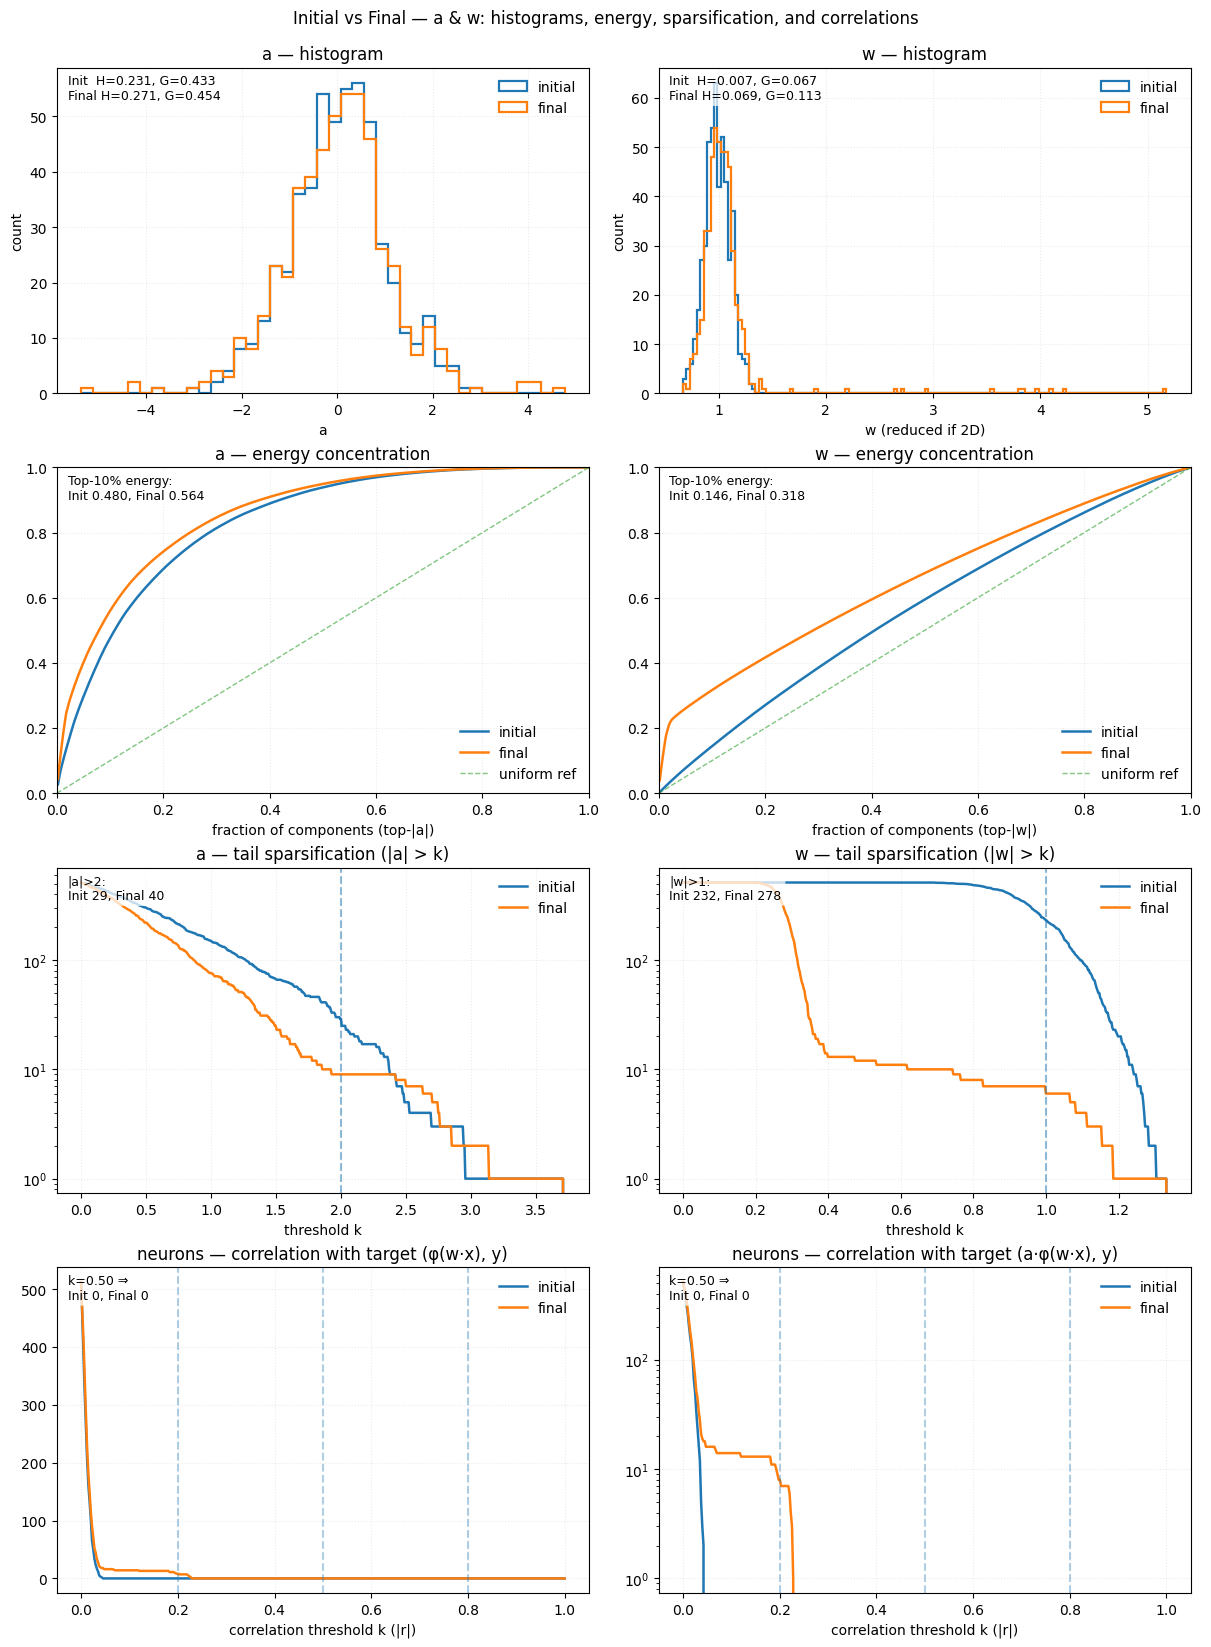

In [1]:
# %% a & w diagnostics: histograms, energy concentration, sparsification, and correlation counts
# Requires: numpy, matplotlib, (optional) torch for loading .pt/.pth and for passing X/y tensors
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional, Tuple, Union, Callable

# -------------------------
# Torch-safe to-numpy
# -------------------------
def _to_numpy(x):
    """Convert torch/np to numpy array (detaches + moves to CPU if torch)."""
    try:
        import torch
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

# -------------------------
# Find w,a in nested state dicts (robust to prefixes)
# -------------------------
def _find_w_a_in_mapping(mapping) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Heuristically locate 'w' and 'a' inside (possibly nested) dict-like objects.
    Works with keys like: 'w', 'a', 'module.w', '_orig_mod.a', 'weights', 'alpha', etc.
    """
    import collections.abc as cab
    CAND_W = {"w", "weights", "weight", "ws"}
    CAND_A = {"a", "alpha", "alphas", "coeffs", "coefficients"}

    def is_w_key(k: str) -> bool:
        parts = k.replace("/", ".").lower().split(".")
        return any(p in CAND_W for p in parts)

    def is_a_key(k: str) -> bool:
        parts = k.replace("/", ".").lower().split(".")
        return any(p in CAND_A for p in parts)

    found_w, found_a = None, None

    def walk(obj):
        nonlocal found_w, found_a
        if isinstance(obj, cab.Mapping):
            for k, v in obj.items():
                ks = str(k)
                if found_w is None and is_w_key(ks):
                    try: found_w = _to_numpy(v)
                    except Exception: pass
                if found_a is None and is_a_key(ks):
                    try: found_a = _to_numpy(v)
                    except Exception: pass
                if isinstance(v, cab.Mapping):
                    walk(v)
                elif isinstance(v, (list, tuple)):
                    for vv in v: walk(vv)

    walk(mapping)
    return found_w, found_a

# -------------------------
# Loaders
# -------------------------
def _load_w_a_from_path(pathlike: Union[str, Path]) -> Tuple[np.ndarray, np.ndarray]:
    """Load w,a from .npy/.npz/.pt/.pth files."""
    p = Path(pathlike)
    suffix = p.suffix.lower()

    if suffix == ".npy":
        arr = np.load(p, allow_pickle=True)
        if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[0] == 2:
            return _to_numpy(arr[0]), _to_numpy(arr[1])
        raise ValueError("'.npy' expected shape (2, N): first row=w, second row=a.")

    if suffix == ".npz":
        data = np.load(p, allow_pickle=True)
        keys = list(data.keys())
        for wk in ["w", "weights", "W", "weight", "ws"]:
            if wk in data: w_vals = data[wk]; break
        else: w_vals = data[keys[0]]
        for ak in ["a", "alpha", "alphas", "A", "coeffs", "coefficients"]:
            if ak in data: a_vals = data[ak]; break
        else: a_vals = data[keys[1 if len(keys) > 1 else 0]]
        return _to_numpy(w_vals), _to_numpy(a_vals)

    if suffix in {".pt", ".pth"}:
        try:
            import torch
        except ImportError as e:
            raise ImportError("Torch is required to load .pt/.pth files.") from e
        obj = torch.load(p, map_location="cpu")

        # (w, a) as tuple/list
        if isinstance(obj, (list, tuple)) and len(obj) >= 2:
            return _to_numpy(obj[0]), _to_numpy(obj[1])

        # state_dict or nested dict
        if isinstance(obj, dict):
            w_raw, a_raw = _find_w_a_in_mapping(obj)

            # Fallback: scan for plausible arrays
            if w_raw is None or a_raw is None:
                cands = []
                def collect(o):
                    if isinstance(o, dict):
                        for v in o.values(): collect(v)
                    elif isinstance(o, (list, tuple)):
                        for v in o: collect(v)
                    else:
                        try:
                            arr = _to_numpy(o)
                            if isinstance(arr, np.ndarray) and arr.ndim in (1, 2) and arr.size > 0:
                                cands.append(arr)
                        except Exception:
                            pass
                collect(obj)

                one_d = [x for x in cands if x.ndim == 1]
                two_d = [x for x in cands if x.ndim == 2]

                # Prefer a as 1D; else vector-like 2D (N,1)/(1,N); else tallest 2D.
                if a_raw is None:
                    if one_d:
                        a_raw = max(one_d, key=lambda v: v.shape[0])
                    else:
                        vec_like = [X for X in two_d if 1 in X.shape]  # (N,1) or (1,N)
                        if vec_like:
                            a_raw = max(vec_like, key=lambda V: max(V.shape))
                        elif two_d:
                            a_raw = max(two_d, key=lambda V: max(V.shape))  # last resort

                # Choose w to share N with a (row or col)
                if a_raw is not None and w_raw is None:
                    N = a_raw.shape[0] if a_raw.ndim == 1 else max(a_raw.shape)
                    matches_1d = [x for x in one_d if x is not a_raw and x.shape[0] == N]
                    if matches_1d:
                        w_raw = matches_1d[0]
                    else:
                        matches_2d = [X for X in two_d if N in X.shape]
                        if matches_2d:
                            w_raw = matches_2d[0]

            if w_raw is None or a_raw is None:
                raise ValueError("Could not locate 'w' and 'a' in the .pt/.pth file.")

            return _to_numpy(w_raw), _to_numpy(a_raw)

        raise ValueError("Unsupported object stored in the .pt/.pth file.")

    raise ValueError(f"Unsupported file extension: {suffix}")

def _get_arrays(data_or_path, expect_pair=True):
    """
    Accept:
      - (w, a) arrays
      - a (2, N) array
      - a path to a supported file
    Return (w_raw, a_raw).
    """
    if isinstance(data_or_path, (str, Path)):
        return _load_w_a_from_path(data_or_path)
    arr = np.asarray(data_or_path, dtype=object)
    if isinstance(data_or_path, (list, tuple)) and len(data_or_path) == 2:
        return _to_numpy(data_or_path[0]), _to_numpy(data_or_path[1])
    if isinstance(arr, np.ndarray) and arr.ndim >= 2 and arr.shape[0] == 2:
        return _to_numpy(arr[0]), _to_numpy(arr[1])
    raise ValueError("data_or_path must be (w,a), a (2,N) array, or a path to a supported file.")

# -------------------------
# w coercions
# -------------------------
def _coerce_w_to_vector(w_raw: np.ndarray, a_len: int, w_reduce: str, w_component: Optional[int]) -> np.ndarray:
    """
    Make w a 1D vector of length a_len.
    If w_raw is 2D and one axis equals a_len, reduce along the other axis using:
      - 'norm' (L2 across features) [default]
      - 'mean' | 'sum'
      - 'component' (select a specific feature by index)
    """
    w_raw = np.asarray(w_raw)
    if w_raw.ndim == 1:
        if w_raw.shape[0] != a_len:
            raise ValueError(f"w is 1D length {w_raw.shape[0]} but a is length {a_len}.")
        return w_raw.astype(np.float64)

    if w_raw.ndim != 2:
        raise ValueError(f"w must be 1D or 2D; got shape {w_raw.shape}.")

    # Align so w_raw is (a_len, D)
    if w_raw.shape[0] == a_len:
        pass
    elif w_raw.shape[1] == a_len:
        w_raw = np.swapaxes(w_raw, 0, 1)
    else:
        raise ValueError(f"w is 2D {w_raw.shape}, but neither dimension equals len(a)={a_len}.")

    D = w_raw.shape[1]
    if w_reduce == "component":
        idx = 0 if (w_component is None) else int(w_component)
        if not (0 <= idx < D):
            raise ValueError(f"w_component {idx} out of range for D={D}.")
        w_vec = w_raw[:, idx]
    elif w_reduce == "norm":
        w_vec = np.linalg.norm(w_raw, axis=1)
    elif w_reduce == "mean":
        w_vec = w_raw.mean(axis=1)
    elif w_reduce == "sum":
        w_vec = w_raw.sum(axis=1)
    else:
        raise ValueError("w_reduce must be one of: 'norm'|'mean'|'sum'|'component'")
    return w_vec.astype(np.float64)

def _coerce_w_to_matrix_for_X(w_raw: np.ndarray, a_len: int, x_dim: int) -> Optional[np.ndarray]:
    """
    Align w into a matrix W of shape (N=a_len, D=x_dim) for computing phi(Wx).
    Returns None if alignment is impossible.
    """
    W = np.asarray(w_raw)
    if W.ndim == 1:
        if W.shape[0] == a_len and x_dim == 1:
            return W.reshape(-1, 1).astype(np.float64)
        if a_len == 1 and W.shape[0] == x_dim:
            return W.reshape(1, -1).astype(np.float64)
        return None

    if W.ndim != 2:
        return None

    if W.shape[0] == a_len and W.shape[1] == x_dim:
        return W.astype(np.float64)
    if W.shape[1] == a_len and W.shape[0] == x_dim:
        return W.T.astype(np.float64)
    return None

# -------------------------
# Metrics
# -------------------------
def _energy_concentration_curve(x: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Return (x_frac, cumulative energy fraction) for components sorted by |x| desc."""
    x = np.asarray(x).ravel()
    mags = np.abs(x)
    order = np.argsort(-mags)
    energy = (x[order].astype(np.float64)) ** 2
    total = energy.sum()
    if total <= 0:
        N = x.size if x.size else 1
        return np.linspace(1/N, 1.0, N), np.zeros(N)
    cum = np.cumsum(energy)
    N = x.size
    return np.linspace(1/N, 1.0, N), (cum / total)

def _top_p_energy(x: np.ndarray, p: float = 0.1) -> float:
    """Fraction of total L2 energy captured by the top p fraction of |x|."""
    x = np.asarray(x).ravel()
    N = x.size
    if N == 0:
        return 0.0
    k = max(1, int(np.ceil(p * N)))
    mags2 = np.sort(np.abs(x))**2
    top = mags2[-k:].sum()
    tot = mags2.sum()
    return 0.0 if tot <= 0 else float(top / tot)

def _hoyer_sparsity(x: np.ndarray) -> float:
    """Hoyer sparsity in [0,1]."""
    x = np.asarray(x).ravel().astype(np.float64)
    N = x.size if x.size else 1
    l1 = np.sum(np.abs(x))
    l2 = np.linalg.norm(x)
    if l2 == 0:
        return 1.0
    return float((np.sqrt(N) - (l1 / l2)) / (np.sqrt(N) - 1.0))

def _gini_coefficient(x: np.ndarray) -> float:
    """Gini coefficient of |x|."""
    x = np.abs(np.asarray(x).ravel().astype(np.float64))
    N = x.size
    if N == 0:
        return 0.0
    mean = x.mean()
    if mean == 0:
        return 0.0
    diffs = np.abs(x[:, None] - x[None, :])
    mad = diffs.mean()
    return float(mad / (2.0 * mean))

def _tail_counts_over_thresholds(x: np.ndarray, num_k: int = 512) -> Tuple[np.ndarray, np.ndarray]:
    """Threshold grid k and counts of |x|>k, ensuring we include the global max to show outliers."""
    x = np.asarray(x).ravel()
    mags = np.abs(x)
    if mags.size == 0:
        return np.array([0.0]), np.array([0])
    q_hi = np.nanpercentile(mags, 99.9)
    k_min = 0.0
    k_max = float(np.nanmax(mags))
    if not np.isfinite(k_max): k_max = 0.0
    base = np.linspace(k_min, max(q_hi, k_min), num_k, endpoint=True)
    tail = np.linspace(max(q_hi, k_min), k_max, max(8, num_k // 16), endpoint=True)
    k = np.unique(np.concatenate([base, tail]))
    mags_sorted = np.sort(mags)
    idx = np.searchsorted(mags_sorted, k, side='right')
    counts = mags_sorted.size - idx
    return k, counts

# -------------------------
# Correlations (need X,y)
# -------------------------
def _get_phi(phi: Union[str, Callable[[np.ndarray], np.ndarray]]) -> Callable[[np.ndarray], np.ndarray]:
    """Return an activation function."""
    if callable(phi):
        return phi
    key = str(phi).lower()
    if key == "tanh":
        return np.tanh
    if key == "relu":
        return lambda z: np.maximum(0.0, z)
    if key == "sigmoid":
        return lambda z: 1.0 / (1.0 + np.exp(-z))
    if key == "gelu":
        return lambda z: 0.5 * z * (1.0 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))
    if key == "identity":
        return lambda z: z
    raise ValueError(f"Unknown activation '{phi}'. Provide 'tanh', 'relu', 'sigmoid', 'gelu', 'identity', or a callable.")

def _pearson_colwise(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Column-wise Pearson correlation between columns of A (M x N) and vector y (M,)."""
    A = np.asarray(A, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64).ravel()
    if A.ndim != 2:
        raise ValueError("A must be 2D (M x N).")
    if y.ndim != 1 or y.shape[0] != A.shape[0]:
        raise ValueError("y must be shape (M,) matching A.shape[0].")
    y_c = y - y.mean()
    y_den = np.sqrt(np.sum(y_c**2))
    if y_den == 0:
        return np.zeros(A.shape[1], dtype=np.float64)
    A_c = A - A.mean(axis=0, keepdims=True)
    A_den = np.sqrt(np.sum(A_c**2, axis=0)) + 1e-12
    num = np.sum(A_c * y_c[:, None], axis=0)
    r = num / (A_den * y_den)
    return np.clip(r, -1.0, 1.0)

def _corr_counts_k(W: np.ndarray,
                   a: np.ndarray,
                   X: np.ndarray,
                   y: np.ndarray,
                   phi: Callable[[np.ndarray], np.ndarray],
                   abs_corr: bool = True,
                   num_k: int = 400) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute thresholds k in [0,1] and counts of neurons whose correlation exceeds k:
      - h_i(x) = phi(w_i^T x)
      - s_i(x) = a_i * phi(w_i^T x)
    Returns (k_grid, counts_phi, counts_a_phi).
    """
    M, D = X.shape
    N, D_check = W.shape
    if D_check != D or a.shape[0] != N:
        raise ValueError(f"Shape mismatch: W({W.shape}), a({a.shape}), X({X.shape}).")

    Z = X @ W.T            # (M, N)
    H = phi(Z)             # (M, N)
    S = H * a.reshape(1, -1)  # (M, N)

    r_h = _pearson_colwise(H, y)
    r_s = _pearson_colwise(S, y)

    r_h = np.abs(r_h) if abs_corr else r_h
    r_s = np.abs(r_s) if abs_corr else r_s

    k = np.linspace(0.0, 1.0, num_k, endpoint=True)
    r_h_sorted = np.sort(r_h)
    r_s_sorted = np.sort(r_s)
    idx_h = np.searchsorted(r_h_sorted, k, side="right")
    idx_s = np.searchsorted(r_s_sorted, k, side="right")
    cnt_h = r_h_sorted.size - idx_h
    cnt_s = r_s_sorted.size - idx_s
    return k, cnt_h, cnt_s

# -------------------------
# Main plotting function
# -------------------------
def plot_aw_hist_overlays(
    init_data: Union[Tuple[np.ndarray, np.ndarray], np.ndarray, str, Path],
    final_data: Union[Tuple[np.ndarray, np.ndarray], np.ndarray, str, Path],
    bins: Union[int, str] = "fd",          # integer or 'auto'/'fd'/'sqrt'/...
    range_mode: str = "full",              # 'full' or 'quantile'
    clip_percentiles: Tuple[float, float] = (0.1, 99.9),
    density: bool = False,                 # counts by default
    figsize: Tuple[float, float] = (12, 16),
    title: Optional[str] = "Initial vs Final — a & w: histograms, energy, sparsification, and correlations",
    w_reduce: str = "norm",                # handling 2D w -> 1D: 'norm'|'mean'|'sum'|'component'
    w_component: Optional[int] = None,     # used if w_reduce='component'
    save_path: Optional[str] = None,
    log_tail_y: bool = True,               # log-scale the y-axis for tail-count plots

    # Metrics:
    top_p: float = 0.10,                   # top-p energy (fraction, e.g., 0.10 == top 10%)
    a_thresh: float = 2.0,                 # count |a| > a_thresh
    w_thresh: float = 1.0,                 # count |w| > w_thresh

    # Correlation plot parameters (requires X and y):
    X: Optional[Union[np.ndarray, "torch.Tensor"]] = None,  # shape (M, D)
    y: Optional[Union[np.ndarray, "torch.Tensor"]] = None,  # shape (M,)
    phi: Union[str, Callable[[np.ndarray], np.ndarray]] = "tanh",
    corr_abs: bool = True,
    corr_num_k: int = 400,
    corr_k_lines: Tuple[float, ...] = (0.2, 0.5, 0.8),
    corr_report_k: float = 0.5,
):
    """
    Creates eight panels:
      Row 1: histogram of a; histogram of w (initial vs final)  [annotate Hoyer & Gini]
      Row 2: energy concentration of a; energy concentration of w  [annotate Top-p energy]
      Row 3: tail counts (# {|a|>k}); tail counts (# {|w|>k})      [annotate fixed-threshold counts]
      Row 4: counts of corr_y(phi(w·x)) > k; counts of corr_y(a_i·phi(w_i·x)) > k (if X,y provided)
    """
    # Load both models
    w0_raw, a0_raw = _get_arrays(init_data)
    w1_raw, a1_raw = _get_arrays(final_data)

    # Coerce arrays for histogram/tail/energy
    a0 = np.asarray(a0_raw, dtype=np.float64).ravel()
    a1 = np.asarray(a1_raw, dtype=np.float64).ravel()
    w0 = _coerce_w_to_vector(w0_raw, a_len=a0.shape[0], w_reduce=w_reduce, w_component=w_component)
    w1 = _coerce_w_to_vector(w1_raw, a_len=a1.shape[0], w_reduce=w_reduce, w_component=w_component)

    # Ranges & common bin edges (per variable)
    def common_edges(x, y, bins, range_mode, clip_percentiles):
        xy = np.concatenate([x, y])
        if range_mode == "full":
            r = (np.nanmin(xy), np.nanmax(xy))
        elif range_mode == "quantile":
            r = tuple(np.nanpercentile(xy, clip_percentiles))
        else:
            raise ValueError("range_mode must be 'full' or 'quantile'.")
        if isinstance(bins, (int, np.integer)):
            edges = np.linspace(r[0], r[1], int(bins) + 1)
        else:
            edges = np.histogram_bin_edges(xy, bins=bins, range=r)
        if not np.all(np.isfinite(edges)) or np.unique(edges).size < 2:
            lo, hi = float(np.nanmin(xy)), float(np.nanmax(xy))
            if hi == lo: hi = lo + 1e-9
            edges = np.linspace(lo, hi, 51)
        return edges

    a_edges = common_edges(a0, a1, bins, range_mode, clip_percentiles)
    w_edges = common_edges(w0, w1, bins, range_mode, clip_percentiles)

    # Compute curves
    a0_xfrac, a0_ec = _energy_concentration_curve(a0)
    a1_xfrac, a1_ec = _energy_concentration_curve(a1)
    w0_xfrac, w0_ec = _energy_concentration_curve(w0)
    w1_xfrac, w1_ec = _energy_concentration_curve(w1)

    ak, a_cnt0 = _tail_counts_over_thresholds(a0)
    _,  a_cnt1 = _tail_counts_over_thresholds(a1)
    wk, w_cnt0 = _tail_counts_over_thresholds(w0)
    _,  w_cnt1 = _tail_counts_over_thresholds(w1)

    # --- Metrics
    # Top-p energy
    a_top_init = _top_p_energy(a0, top_p)
    a_top_final = _top_p_energy(a1, top_p)
    w_top_init = _top_p_energy(w0, top_p)
    w_top_final = _top_p_energy(w1, top_p)

    # Hoyer & Gini
    a_h_init, a_h_final = _hoyer_sparsity(a0), _hoyer_sparsity(a1)
    w_h_init, w_h_final = _hoyer_sparsity(w0), _hoyer_sparsity(w1)
    a_g_init, a_g_final = _gini_coefficient(a0), _gini_coefficient(a1)
    w_g_init, w_g_final = _gini_coefficient(w0), _gini_coefficient(w1)

    # Fixed-threshold counts
    a_cnt_init_thr = int((np.abs(a0) > a_thresh).sum())
    a_cnt_final_thr = int((np.abs(a1) > a_thresh).sum())
    w_cnt_init_thr = int((np.abs(w0) > w_thresh).sum())
    w_cnt_final_thr = int((np.abs(w1) > w_thresh).sum())

    # --- Correlation counts (if X and y provided)
    have_xy = (X is not None) and (y is not None)
    if have_xy:
        X = _to_numpy(X).astype(np.float64)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        y = _to_numpy(y).astype(np.float64).ravel()
        act = _get_phi(phi)
        W0_mat = _coerce_w_to_matrix_for_X(w0_raw, a_len=a0.shape[0], x_dim=X.shape[1])
        W1_mat = _coerce_w_to_matrix_for_X(w1_raw, a_len=a1.shape[0], x_dim=X.shape[1])
        if W0_mat is None or W1_mat is None:
            print("[warning] Could not align w into (N,D) for phi(w·x). Skipping correlation panels.")
            have_xy = False

    if have_xy:
        k_corr, cnt_phi0, cnt_a_phi0 = _corr_counts_k(W0_mat, a0, X, y, act, abs_corr=corr_abs, num_k=corr_num_k)
        _,      cnt_phi1, cnt_a_phi1 = _corr_counts_k(W1_mat, a1, X, y, act, abs_corr=corr_abs, num_k=corr_num_k)

    # Plot (4 rows x 2 cols)
    fig, axes = plt.subplots(4, 2, figsize=figsize, constrained_layout=True)
    (ax_a_hist, ax_w_hist), (ax_a_ec, ax_w_ec), (ax_a_tail, ax_w_tail), (ax_corr_phi, ax_corr_a_phi) = axes

    # --- Row 1: histograms
    ax_a_hist.hist(a0, bins=a_edges, density=density, histtype="step", linewidth=1.6, label="initial")
    ax_a_hist.hist(a1, bins=a_edges, density=density, histtype="step", linewidth=1.6, label="final")
    ax_a_hist.set_xlabel("a")
    ax_a_hist.set_ylabel("count" if not density else "density")
    ax_a_hist.grid(alpha=0.25, linestyle=":")
    ax_a_hist.legend(frameon=False)
    ax_a_hist.set_title("a — histogram")
    txt = (f"Init  H={a_h_init:.3f}, G={a_g_init:.3f}\n"
           f"Final H={a_h_final:.3f}, G={a_g_final:.3f}")
    ax_a_hist.text(0.02, 0.98, txt, transform=ax_a_hist.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    ax_w_hist.hist(w0, bins=w_edges, density=density, histtype="step", linewidth=1.6, label="initial")
    ax_w_hist.hist(w1, bins=w_edges, density=density, histtype="step", linewidth=1.6, label="final")
    ax_w_hist.set_xlabel("w (reduced if 2D)")
    ax_w_hist.set_ylabel("count" if not density else "density")
    ax_w_hist.grid(alpha=0.25, linestyle=":")
    ax_w_hist.legend(frameon=False)
    ax_w_hist.set_title("w — histogram")
    txt = (f"Init  H={w_h_init:.3f}, G={w_g_init:.3f}\n"
           f"Final H={w_h_final:.3f}, G={w_g_final:.3f}")
    ax_w_hist.text(0.02, 0.98, txt, transform=ax_w_hist.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    # --- Row 2: energy concentration
    ax_a_ec.plot(a0_xfrac, a0_ec, lw=1.8, label="initial")
    ax_a_ec.plot(a1_xfrac, a1_ec, lw=1.8, label="final")
    ax_a_ec.plot([0,1], [0,1], lw=1.0, linestyle="--", alpha=0.6, label="uniform ref")
    ax_a_ec.set_xlabel("fraction of components (top-|a|)")
    #ax_a_ec.set_ylabel(r"cumulative energy  $\sum_{i\le k} a_{(i)}^2 / \sum_j a_j^2$")
    ax_a_ec.set_xlim(0, 1); ax_a_ec.set_ylim(0, 1)
    ax_a_ec.grid(alpha=0.25, linestyle=":"); ax_a_ec.legend(frameon=False)
    ax_a_ec.set_title("a — energy concentration")
    ax_a_ec.text(0.02, 0.98,
                 f"Top-{int(top_p*100)}% energy:\n"
                 f"Init {a_top_init:.3f}, Final {a_top_final:.3f}",
                 transform=ax_a_ec.transAxes, va="top", ha="left",
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    ax_w_ec.plot(w0_xfrac, w0_ec, lw=1.8, label="initial")
    ax_w_ec.plot(w1_xfrac, w1_ec, lw=1.8, label="final")
    ax_w_ec.plot([0,1], [0,1], lw=1.0, linestyle="--", alpha=0.6, label="uniform ref")
    ax_w_ec.set_xlabel("fraction of components (top-|w|)")
    #ax_w_ec.set_ylabel(r"cumulative energy  $\sum_{i\le k} w_{(i)}^2 / \sum_j w_j^2$")
    ax_w_ec.set_xlim(0, 1); ax_w_ec.set_ylim(0, 1)
    ax_w_ec.grid(alpha=0.25, linestyle=":"); ax_w_ec.legend(frameon=False)
    ax_w_ec.set_title("w — energy concentration")
    ax_w_ec.text(0.02, 0.98,
                 f"Top-{int(top_p*100)}% energy:\n"
                 f"Init {w_top_init:.3f}, Final {w_top_final:.3f}",
                 transform=ax_w_ec.transAxes, va="top", ha="left",
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    # --- Row 3: tail counts
    ax_a_tail.plot(ak, a_cnt0, lw=1.8, label="initial")
    ax_a_tail.plot(ak, a_cnt1, lw=1.8, label="final")
    ax_a_tail.axvline(a_thresh, ls="--", alpha=0.5)
    ax_a_tail.set_xlabel("threshold k")
    #ax_a_tail.set_ylabel(r"count of $\{|a|>k\}$")
    if log_tail_y: ax_a_tail.set_yscale("log")
    ax_a_tail.grid(alpha=0.25, linestyle=":"); ax_a_tail.legend(frameon=False)
    ax_a_tail.set_title("a — tail sparsification (|a| > k)")
    ax_a_tail.text(0.02, 0.98,
                   f"|a|>{a_thresh:g}:\n"
                   f"Init {a_cnt_init_thr}, Final {a_cnt_final_thr}",
                   transform=ax_a_tail.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    ax_w_tail.plot(wk, w_cnt0, lw=1.8, label="initial")
    ax_w_tail.plot(wk, w_cnt1, lw=1.8, label="final")
    ax_w_tail.axvline(w_thresh, ls="--", alpha=0.5)
    ax_w_tail.set_xlabel("threshold k")
    #ax_w_tail.set_ylabel(r"count of $\{|w|>k\}$")
    if log_tail_y: ax_w_tail.set_yscale("log")
    ax_w_tail.grid(alpha=0.25, linestyle=":"); ax_w_tail.legend(frameon=False)
    ax_w_tail.set_title("w — tail sparsification (|w| > k)")
    ax_w_tail.text(0.02, 0.98,
                   f"|w|>{w_thresh:g}:\n"
                   f"Init {w_cnt_init_thr}, Final {w_cnt_final_thr}",
                   transform=ax_w_tail.transAxes, va="top", ha="left",
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

    # --- Row 4: correlation counts
    if have_xy:
        # phi(w·x) vs y
        ax_corr_phi.plot(k_corr, cnt_phi0, lw=1.8, label="initial")
        ax_corr_phi.plot(k_corr, cnt_phi1, lw=1.8, label="final")
        for kline in corr_k_lines:
            ax_corr_phi.axvline(kline, ls="--", alpha=0.35)
        ax_corr_phi.set_xlabel("correlation threshold k" + (" (|r|)" if corr_abs else " (r)"))
        #ax_corr_phi.set_ylabel(r"count of units with corr$(\phi(w\cdot x),\,y)>k$")
        ax_corr_phi.grid(alpha=0.25, linestyle=":")
        ax_corr_phi.legend(frameon=False)
        ax_corr_phi.set_title("neurons — correlation with target (φ(w·x), y)")
        i = np.searchsorted(k_corr, corr_report_k, side="right") - 1
        i = max(0, min(i, k_corr.size-1))
        ax_corr_phi.text(0.02, 0.98,
                         f"k={corr_report_k:.2f} ⇒\nInit {int(cnt_phi0[i])}, Final {int(cnt_phi1[i])}",
                         transform=ax_corr_phi.transAxes, va="top", ha="left",
                         bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)

        # a_i*phi(w_i·x) vs y
        ax_corr_a_phi.plot(k_corr, cnt_a_phi0, lw=1.8, label="initial")
        ax_corr_a_phi.plot(k_corr, cnt_a_phi1, lw=1.8, label="final")
        for kline in corr_k_lines:
            ax_corr_a_phi.axvline(kline, ls="--", alpha=0.35)
        ax_corr_a_phi.set_xlabel("correlation threshold k" + (" (|r|)" if corr_abs else " (r)"))
        #ax_corr_a_phi.set_ylabel(r"count with corr$(a_i\cdot \phi(w_i\cdot x),\,y)>k$")
        ax_corr_a_phi.grid(alpha=0.25, linestyle=":")
        ax_corr_a_phi.legend(frameon=False)
        ax_corr_a_phi.set_yscale("log")
        ax_corr_a_phi.set_title("neurons — correlation with target (a·φ(w·x), y)")
        i = np.searchsorted(k_corr, corr_report_k, side="right") - 1
        i = max(0, min(i, k_corr.size-1))
        ax_corr_a_phi.text(0.02, 0.98,
                           f"k={corr_report_k:.2f} ⇒\nInit {int(cnt_a_phi0[i])}, Final {int(cnt_a_phi1[i])}",
                           transform=ax_corr_a_phi.transAxes, va="top", ha="left",
                           bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), fontsize=9)
    else:
        for ax, title in [(ax_corr_phi, "neurons — correlation with target (φ(w·x), y)"),
                          (ax_corr_a_phi, "neurons — correlation with target (a·φ(w·x), y)")]:
            ax.axis("off")
            ax.text(0.5, 0.5,
                    "Provide X (M×D) and y (M,) to compute correlation plots.",
                    ha="center", va="center", fontsize=10,
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
            ax.set_title(title)

    if title:
        fig.suptitle(title, y=1.02)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to: {save_path}")

    # Console summary
    print(f"[Top-{int(top_p*100)}% energy]  a: init={a_top_init:.4f}, final={a_top_final:.4f} | "
          f"w: init={w_top_init:.4f}, final={w_top_final:.4f}")
    print(f"[Hoyer] a: init={a_h_init:.4f}, final={a_h_final:.4f} | w: init={w_h_init:.4f}, final={w_h_final:.4f}")
    print(f"[Gini ] a: init={a_g_init:.4f}, final={a_g_final:.4f} | w: init={w_g_init:.4f}, final={w_g_final:.4f}")
    print(f"[Counts > thr]  |a|>{a_thresh:g}: init={a_cnt_init_thr}, final={a_cnt_final_thr} | "
          f"|w|>{w_thresh:g}: init={w_cnt_init_thr}, final={w_cnt_final_thr}")
    if have_xy:
        i = np.searchsorted(k_corr, corr_report_k, side="right") - 1
        i = max(0, min(i, k_corr.size-1))
        print(f"[Corr counts @ k={corr_report_k:.2f}, {'|r|' if corr_abs else 'r'}]  "
              f"phi(wx): init={int(cnt_phi0[i])}, final={int(cnt_phi1[i])} | "
              f"a·phi(wx): init={int(cnt_a_phi0[i])}, final={int(cnt_a_phi1[i])}")

    return fig, axes

# -------------------------
# Example usage
# -------------------------
if __name__ == "__main__":
    # Update these to your actual saved models (from your training script)
    init_path  = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/init_model_P_10000_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    final_path = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"

    # Option A: use your real dataset tensors (Torch CPU/GPU) — this works directly:
    #X, y = None, None
    # Example (synthetic): k-sparse parity on first 4 bits, X in {-1,+1}^{M×35}
    import torch
    M, d, k = 5000, 35, 4
    X_t = (torch.randint(2, (M, d)) * 2 - 1).to(torch.float32)   # {-1,+1}
    y_t = torch.prod(X_t[:, :k], dim=1)                           # {-1,+1}
    X, y = X_t, y_t  # pass torch tensors directly

    fig, axes = plot_aw_hist_overlays(
        init_path,
        final_path,
        bins="fd",
        range_mode="full",
        density=False,
        title="Initial vs Final — a & w: histograms, energy, sparsification, and correlations",
        w_reduce="norm",
        w_component=None,
        save_path=None,
        log_tail_y=True,
        top_p=0.10,        # Top-10% energy
        a_thresh=2.0,      # Count |a|>2
        w_thresh=1.0,      # Count |w|>1
        # Correlation plots (optional):
        X=X, y=y,
        phi="relu",        # your model uses ReLU in the hidden layer
        corr_abs=True,
        corr_num_k=400,
        corr_k_lines=(0.2, 0.5, 0.8),
        corr_report_k=0.5
    )
    import matplotlib.pyplot as plt
    plt.show()


[Top-10% energy]  a: init=0.4804, final=0.4108 | w: init=0.1462, final=0.2097
[Hoyer] a: init=0.2305, final=0.1900 | w: init=0.0073, final=0.0274
[Gini ] a: init=0.4331, final=0.3896 | w: init=0.0673, final=0.1305
[Counts > thr]  |a|>2: init=29, final=77 | |w|>1: init=232, final=423
[Corr counts @ k=0.05, |r|]  phi(wx): init=0, final=1 | a·phi(wx): init=0, final=1


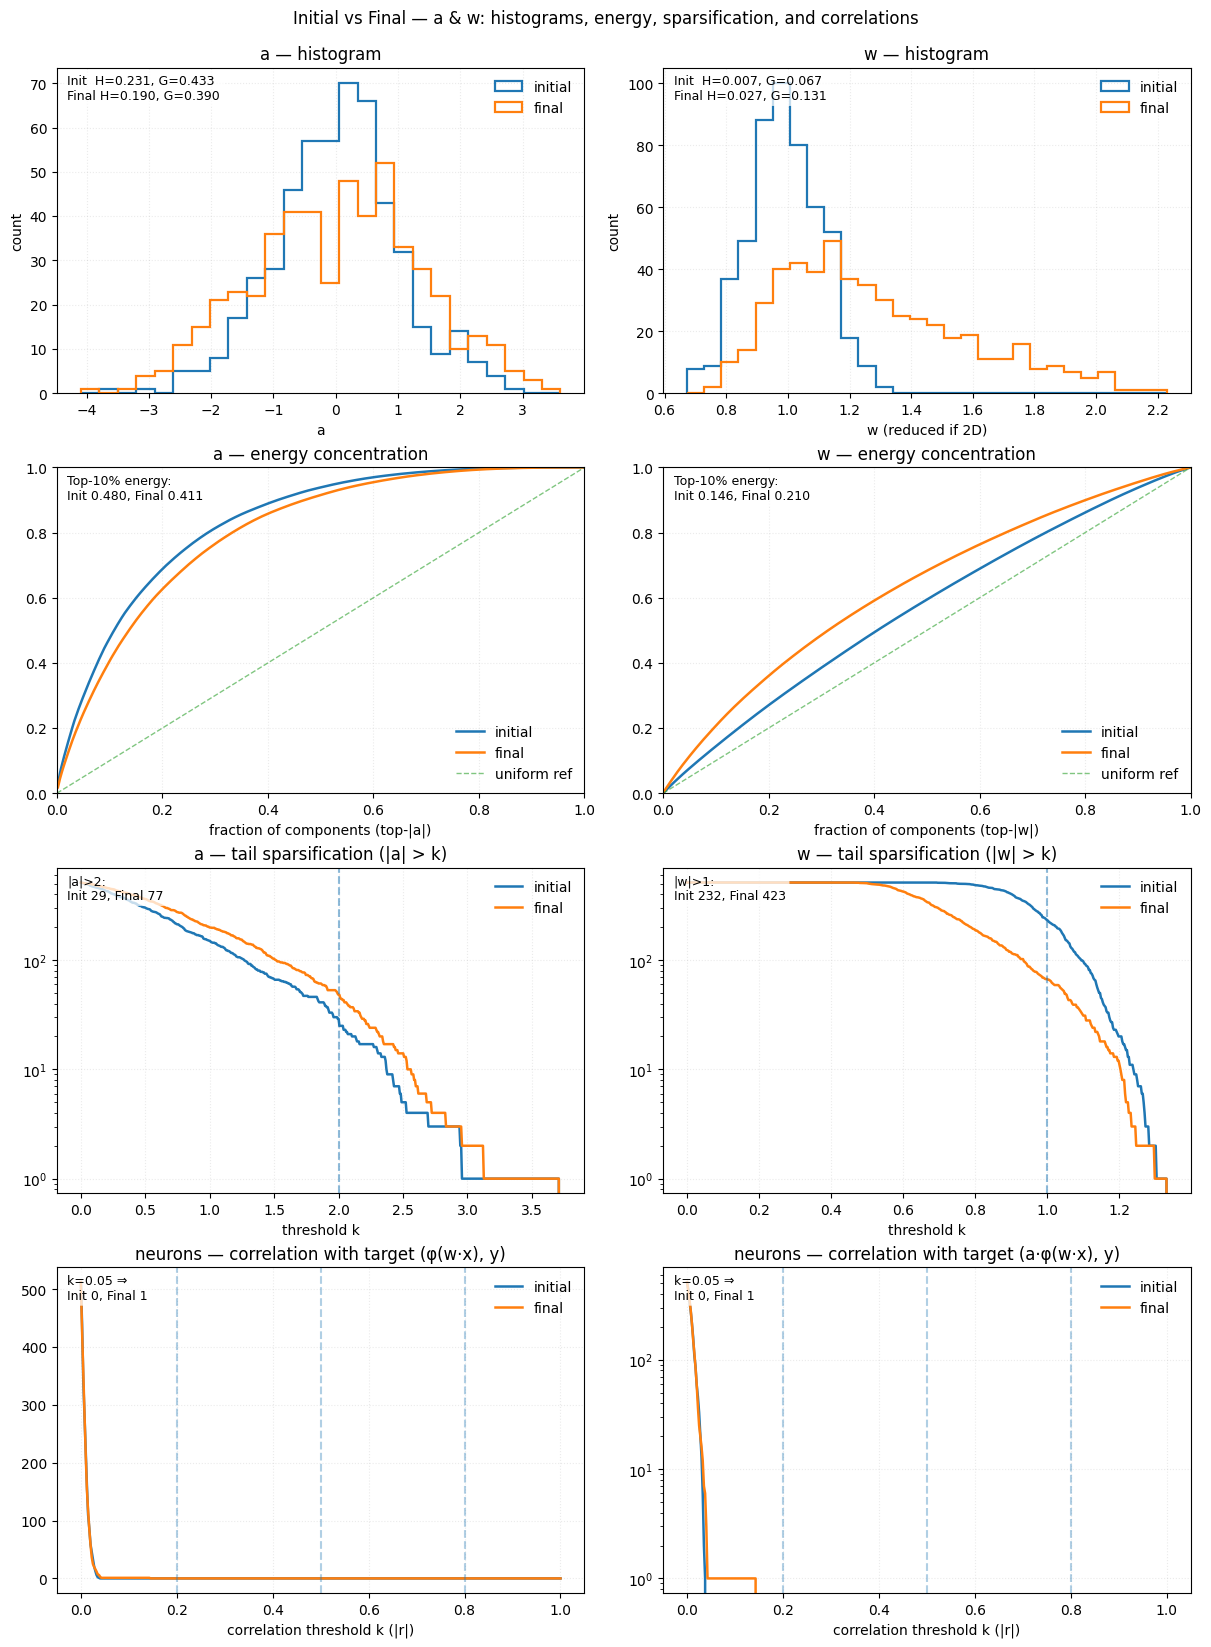

In [9]:
if __name__ == "__main__":
    # Update these to your actual saved models (from your training script)
    init_path  = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/init_model_P_1000_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    final_path = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_1000_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"

    # Option A: use your real dataset tensors (Torch CPU/GPU) — this works directly:
    #X, y = None, None
    # Example (synthetic): k-sparse parity on first 4 bits, X in {-1,+1}^{M×35}
    import torch
    M, d, k = 5000, 35, 4
    X_t = (torch.randint(2, (M, d)) * 2 - 1).to(torch.float32)   # {-1,+1}
    y_t = torch.prod(X_t[:, :k], dim=1)                           # {-1,+1}
    X, y = X_t, y_t  # pass torch tensors directly

    fig, axes = plot_aw_hist_overlays(
        init_path,
        final_path,
        bins="fd",
        range_mode="full",
        density=False,
        title="Initial vs Final — a & w: histograms, energy, sparsification, and correlations",
        w_reduce="norm",
        w_component=None,
        save_path=None,
        log_tail_y=True,
        top_p=0.10,        # Top-10% energy
        a_thresh=2.0,      # Count |a|>2
        w_thresh=1.0,      # Count |w|>1
        # Correlation plots (optional):
        X=X, y=y,
        phi="relu",        # your model uses ReLU in the hidden layer
        corr_abs=True,
        corr_num_k=400,
        corr_k_lines=(0.2, 0.5, 0.8),
        corr_report_k=0.05
    )
    import matplotlib.pyplot as plt
    plt.show()


Loading: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt
W shape: (35, 512)  (d x N)
a shape: (512, 1)  (N x 1 or N,)


/tmp/ipykernel_1215097/1907317422.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


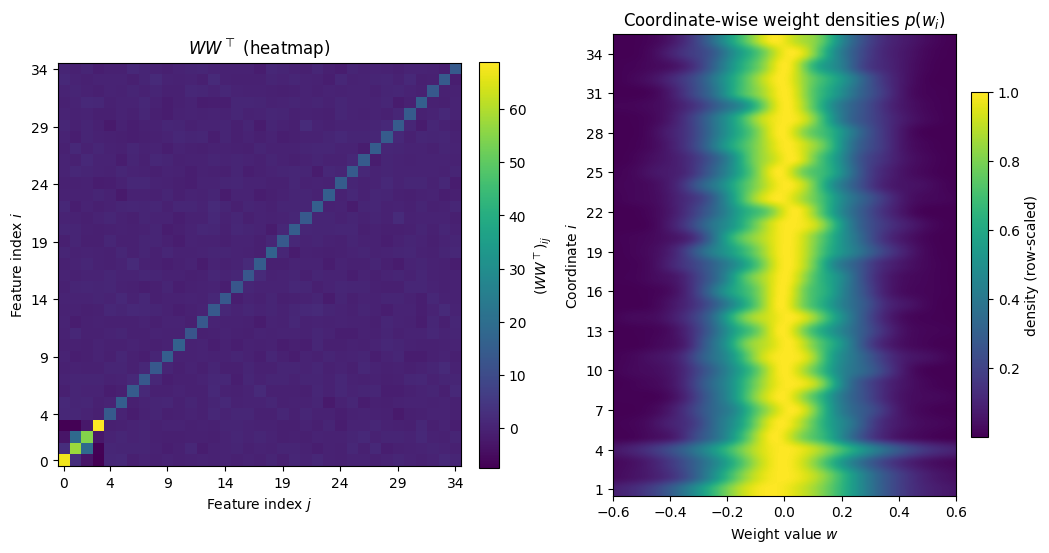

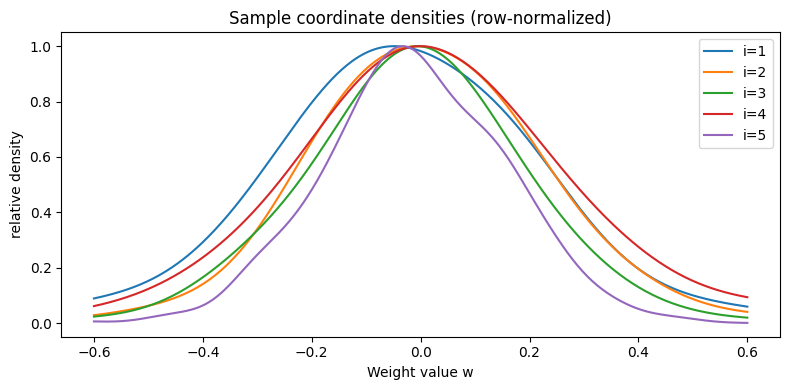

In [8]:
# --- Imports
import os, glob, math
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------- Loading helpers ----------
def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_WA_from_state_dict(path, map_location="cpu"):
    """
    Loads a state_dict saved like in your script and returns (W, a) as torch.Tensors on CPU.
    Expects keys 'w' (d x N) and 'a' (N x 1).
    """
    sd = torch.load(path, map_location=map_location)
    # If the file was saved as a plain state_dict, it's a dict with 'w' and 'a'.
    # If it was saved as a full checkpoint, try to get 'state_dict' inside.
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        # Heuristic: look for keys ending with '.w' or exactly 'w'
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a

# ---------- Minimal 1D Gaussian KDE (no SciPy needed) ----------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    """
    samples: (n,) array
    grid: (G,) array where we evaluate the density
    bandwidth: optional float; if None uses Scott's rule
    Returns: (G,) array, integrates ~1 over R (approx on grid).
    """
    x = np.asarray(samples, dtype=np.float64).reshape(-1)
    G = np.asarray(grid, dtype=np.float64).reshape(-1)
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if n == 1:
        # single sample: very small bandwidth spike
        bw = 1e-3 if bandwidth is None else float(bandwidth)
    else:
        if bandwidth is None:
            std = np.std(x, ddof=1)
            # Scott's rule
            bw = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
        else:
            bw = float(bandwidth)
        bw = max(bw, 1e-12)

    z = (G[:, None] - x[None, :]) / bw  # (G,n)
    # Normal PDF
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * bw * math.sqrt(2.0 * math.pi))
    return dens

# ---------- Plotting ----------
def plot_WWT_and_coordinate_densities(W, *,
                                      grid_points=301,
                                      weight_range=None,
                                      normalize_rows=True,
                                      savefig=None,
                                      show=True):
    """
    W: torch.Tensor (d x N)
    grid_points: # points for KDE grid (x-axis of densities)
    weight_range: tuple (min_w, max_w) for KDE grid; if None, uses robust global range
    normalize_rows: if True, each p(w_i) is scaled to max=1 for visualization
    """
    W = W.detach().cpu().numpy()
    d, N = W.shape

    # WW^T heatmap matrix
    C = W @ W.T  # (d x d)

    # Choose a symmetric, robust range for weight values if not provided
    if weight_range is None:
        abs_vals = np.abs(W).ravel()
        if abs_vals.size == 0:
            lo, hi = -1.0, 1.0
        else:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else abs_vals.max() if abs_vals.max() > 0 else 1.0)
            lo = -hi
    else:
        lo, hi = map(float, weight_range)

    grid = np.linspace(lo, hi, grid_points)

    # Build density image: row i is KDE over W[i,:]
    dens = np.zeros((d, grid_points), dtype=np.float64)
    for i in range(d):
        dens[i] = gaussian_kde_1d(W[i, :], grid)

    if normalize_rows:
        # Normalize each row to [0,1] for display comparability
        max_per_row = dens.max(axis=1, keepdims=True)
        max_per_row[max_per_row == 0] = 1.0
        dens_disp = dens / max_per_row
    else:
        dens_disp = dens

    # --- Figure layout: left = WW^T heatmap, right = density panel ---
    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1.0, 0.85], wspace=0.28)

    # Left: heatmap of WW^T
    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.imshow(C, origin="lower", aspect="equal")
    ax0.set_title(r"$W W^\top$ (heatmap)")
    ax0.set_xlabel("Feature index $j$")
    ax0.set_ylabel("Feature index $i$")
    cbar0 = fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)
    cbar0.set_label(r"$(WW^\top)_{ij}$")

    # Right: coordinate-wise densities p(w_i) as a compact image
    ax1 = fig.add_subplot(gs[0, 1])
    # extent: x from lo..hi, y from 0.5..d+0.5 to align indices visually
    im1 = ax1.imshow(dens_disp,
                     extent=[grid[0], grid[-1], 0.5, d + 0.5],
                     origin="lower",
                     aspect="auto")
    ax1.set_title(r"Coordinate-wise weight densities $p(w_i)$")
    ax1.set_xlabel("Weight value $w$")
    ax1.set_ylabel("Coordinate $i$")
    cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    cbar1.set_label("density (row-scaled)" if normalize_rows else "density")

    # Slightly nicer ticks
    ax0.set_xticks(np.linspace(1, d, min(d, 8)).astype(int) - 1)
    ax0.set_yticks(np.linspace(1, d, min(d, 8)).astype(int) - 1)
    ax1.set_yticks(np.arange(1, d+1, max(1, d // 10)))

    fig.tight_layout()
    if savefig:
        fig.savefig(savefig, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    return fig

# ---------- Optional: overlaid line "ridgeline" for a few coordinates ----------
def plot_example_line_densities(W, coords=(0,1,2,3,4), grid_points=401, weight_range=None):
    W = W.detach().cpu().numpy()
    d, N = W.shape
    coords = [c for c in coords if 0 <= c < d]
    if weight_range is None:
        abs_vals = np.abs(W).ravel()
        q = np.quantile(abs_vals, 0.995)
        hi = float(q if np.isfinite(q) and q > 0 else abs_vals.max() if abs_vals.max() > 0 else 1.0)
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    plt.figure(figsize=(8, 4))
    for i in coords:
        dens = gaussian_kde_1d(W[i, :], grid)
        # Normalize each curve by its own max for visibility
        m = dens.max() if dens.max() > 0 else 1.0
        plt.plot(grid, dens / m, label=f"i={i+1}")
    plt.title("Sample coordinate densities (row-normalized)")
    plt.xlabel("Weight value w")
    plt.ylabel("relative density")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================
# ==== Usage examples =====
# =========================

# Option A: point directly to a model file
# MODEL_FILE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_1000_d_35_k_4_exp_0_kappa_0.010000_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
MODEL_FILE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"  # <- set to the exact .pt if you know it

# Option B: point to a directory and pick the newest final_model_*.pt
MODEL_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"  # <- adjust if needed

if MODEL_FILE is None:
    MODEL_FILE = find_latest_model(MODEL_DIR, prefix="final_model_", ext=".pt")

print("Loading:", MODEL_FILE)
W, a = load_WA_from_state_dict(MODEL_FILE)

print(f"W shape: {tuple(W.shape)}  (d x N)")
print(f"a shape: {tuple(a.shape)}  (N x 1 or N,)")

# Main figure: WW^T + compact coordinate-wise densities
_ = plot_WWT_and_coordinate_densities(W, grid_points=301, normalize_rows=True)

# Optional: a quick line plot for a few coordinates (e.g., first 5)
plot_example_line_densities(W, coords=range(5), grid_points=401)


Loading: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt
W shape: (35, 512)


/tmp/ipykernel_1215097/1986573444.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/tmp/ipykernel_1215097/1986573444.py:157: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


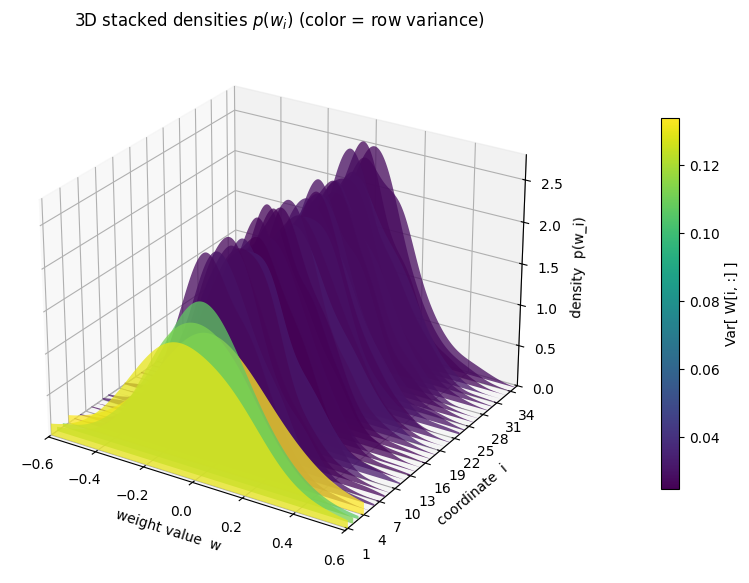

In [9]:
# 3D ridgeline of coordinate-wise p(w_i) from your saved model
# - loads W from your .pt
# - computes 1D KDE for each row i of W[i,:]
# - stacks the densities in 3D "behind each other"
# - color encodes row variance to make changes pop

import os, glob, math
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
import matplotlib as mpl

# ---------------- Loading helpers ----------------
def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a

# ---------------- Minimal 1D Gaussian KDE ----------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).reshape(-1)
    G = np.asarray(grid, dtype=np.float64).reshape(-1)
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if n == 1:
        bw = 1e-3 if bandwidth is None else float(bandwidth)
    else:
        if bandwidth is None:
            std = np.std(x, ddof=1)
            bw = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
        else:
            bw = float(bandwidth)
        bw = max(bw, 1e-12)
    z = (G[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * bw * math.sqrt(2.0 * math.pi))
    return dens

# ---------------- Ridgeline 3D plot ----------------
def plot_coordinate_kdes_3d(W,
                            grid_points=401,
                            weight_range=None,
                            bandwidth=None,
                            normalize_rows=False,
                            y_step=1.0,
                            alpha=0.7,
                            elev=26,
                            azim=-60,
                            row_stride=1,
                            max_rows=None,
                            cmap_name="viridis"):
    """
    W: torch.Tensor of shape (d, N)
    normalize_rows=False keeps absolute density height (better to see variance).
    y_step: spacing between ridges along y (coordinate index).
    row_stride: take every k-th row to thin large d.
    max_rows: cap number of rows (from the top).
    """
    W = W.detach().cpu().numpy()
    d, N = W.shape

    # choose rows to display
    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # pick a robust symmetric range if not provided
    if weight_range is None:
        abs_vals = np.abs(W).ravel()
        q = np.quantile(abs_vals, 0.995) if abs_vals.size else 1.0
        hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.size else 1.0))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)

    grid = np.linspace(lo, hi, grid_points)

    # densities + per-row variance
    dens = []
    variances = []
    for i in rows:
        di = gaussian_kde_1d(W[i, :], grid, bandwidth=bandwidth)
        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m
        dens.append(di)
        variances.append(np.var(W[i, :], ddof=1))
    dens = np.asarray(dens)                 # (R, G)
    variances = np.asarray(variances)       # (R,)

    # colors by variance
    vmin, vmax = float(np.min(variances)), float(np.max(variances))
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.get_cmap(cmap_name)

    # build PolyCollection (filled ridges)
    verts = []
    colors = []
    for r, di in zip(rows, dens):
        # polygon in x-z; close to baseline at z=0
        verts.append(list(zip(grid, di)) + [(grid[-1], 0.0), (grid[0], 0.0)])
        colors.append(cmap(norm(variances[(rows == r).argmax()])))

    poly = PolyCollection(verts, facecolors=colors, edgecolors="none", alpha=alpha)

    # add to 3D axes, stacking along y
    fig = plt.figure(figsize=(12, 7))
    ax = fig.add_subplot(111, projection='3d')
    ys = (np.arange(len(rows)) * y_step)    # y positions for each ridge
    ax.add_collection3d(poly, zs=ys, zdir='y')

    # set axes limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5)
    zmax = float(np.max(dens)) if dens.size else 1.0
    ax.set_zlim(0.0, zmax * 1.05)

    # labels/ticks
    ax.set_xlabel("weight value  w")
    ax.set_ylabel("coordinate  i")
    ax.set_zlabel("density  p(w_i)")
    # y tick labels as original i-indices (1-based for readability)
    tick_every = max(1, len(rows)//10)
    tick_idx = np.arange(0, len(rows), tick_every)
    ax.set_yticks(ys[tick_idx])
    ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])

    # viewpoint
    ax.view_init(elev=elev, azim=azim)

    # colorbar for variance
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.02)
    cbar.set_label("Var[ W[i, :] ]")

    ax.set_title("3D stacked densities $p(w_i)$ (color = row variance)")
    plt.tight_layout()
    plt.show()
    return fig

# ---------------- Usage ----------------
# Option A: point to a specific model file
MODEL_FILE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"  # e.g. "/path/to/final_model_....pt"

# Option B: pick the newest 'final_model_*.pt' from a directory
MODEL_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"

if MODEL_FILE is None:
    MODEL_FILE = find_latest_model(MODEL_DIR, prefix="final_model_", ext=".pt")

print("Loading:", MODEL_FILE)
W, a = load_WA_from_state_dict(MODEL_FILE)
print("W shape:", tuple(W.shape))

# Draw the 3D ridgeline (absolute densities; best to see variance changes)
_ = plot_coordinate_kdes_3d(
    W,
    grid_points=401,
    weight_range=None,     # or set e.g. (-0.6, 0.6)
    bandwidth=None,        # Scott's rule per row
    normalize_rows=False,  # keep absolute height (variance shows as width/peak)
    y_step=0.8,            # spacing between ridges
    alpha=0.75,
    elev=26, azim=-58,
    row_stride=1,          # >1 to thin if d is large
    max_rows=None,         # cap rows if needed
    cmap_name="viridis"
)


Loading: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt
W shape: (35, 512)


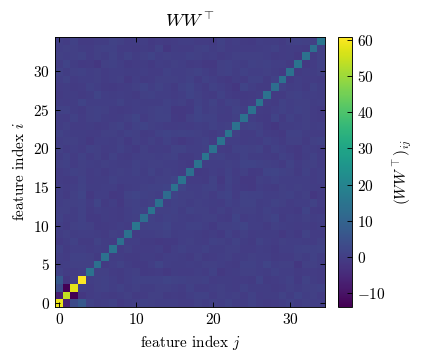

/tmp/ipykernel_1811257/1348016155.py:218: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


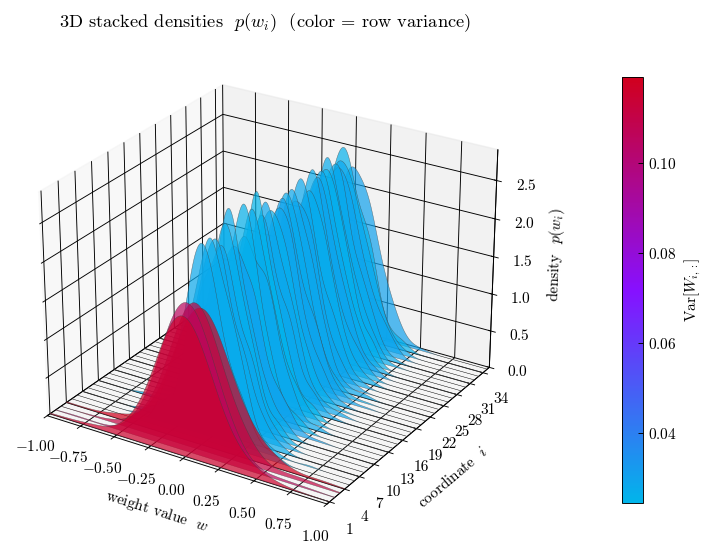

In [45]:
# === Styled 3D ridgeline for p(w_i) + WW^T heatmap (with robust slim_plotters import) ===
import os, sys, glob, math
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------
def import_slim_plotters():
    # Common places to try — add your custom absolute path(s) here if needed
    candidates = [
        "/home/goring/mean_field_langevin/plot_utils",
        "/home/goring/mean_field_langevin/plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]

    # 1) Try direct module path by adding the directory containing slim_plotters.py
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            try:
                import slim_plotters as sp  # noqa
                return sp
            except Exception as e:
                print(f"[note] Found in {d} but import failed: {e!r}")

    # 2) Try package-style imports (requires __init__.py in the folder)
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass

    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
        + " (or update the 'candidates' list above)."
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE

# Apply your theme (switch to theme='dark' if you like)
apply(theme="light", serif=True)

# -----------------------------------------------------------------------------
# Loading helpers
# -----------------------------------------------------------------------------
def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a

# -----------------------------------------------------------------------------
# Minimal 1D Gaussian KDE (no SciPy dependency)
# -----------------------------------------------------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).reshape(-1)
    G = np.asarray(grid, dtype=np.float64).reshape(-1)
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if n == 1:
        bw = 1e-3 if bandwidth is None else float(bandwidth)
    else:
        if bandwidth is None:
            std = np.std(x, ddof=1)
            bw = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
        else:
            bw = float(bandwidth)
        bw = max(bw, 1e-12)
    z = (G[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * bw * math.sqrt(2.0 * math.pi))
    return dens

# -----------------------------------------------------------------------------
# Palette → colormap
# -----------------------------------------------------------------------------
def cycle_linear_cmap(name="varmap", stops=None):
    if stops is None:
        # low → mid → high variance
        stops = [color("blue"), color("purple"), color("red")]
    return LinearSegmentedColormap.from_list(name, stops, N=256)

# -----------------------------------------------------------------------------
# Styled WW^T heatmap
# -----------------------------------------------------------------------------
def plot_WWT_heatmap(W):
    C = (W @ W.T).detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(4.0, 3.4))
    im = ax.imshow(C, origin="lower", aspect="equal")
    ax.set_title(r"$W W^\top$")
    ax.set_xlabel("feature index $j$")
    ax.set_ylabel("feature index $i$")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$(WW^\top)_{ij}$")
    plt.tight_layout()
    plt.show()
    return fig

# -----------------------------------------------------------------------------
# Styled 3D ridgeline for p(w_i)
# -----------------------------------------------------------------------------
def plot_coordinate_kdes_3d(
    W,
    grid_points=401,
    weight_range=None,
    bandwidth=None,
    normalize_rows=False,   # keep absolute heights to reflect variance
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,           # >1 to thin if d is large
    max_rows=None
):
    W_np = W.detach().cpu().numpy()
    d, N = W_np.shape

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # robust symmetric range if not provided
    if weight_range is None:
        abs_vals = np.abs(W_np).ravel()
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)

    grid = np.linspace(lo, hi, grid_points)

    dens, variances = [], []
    for i in rows:
        di = gaussian_kde_1d(W_np[i, :], grid, bandwidth=bandwidth)
        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m
        dens.append(di)
        variances.append(np.var(W_np[i, :], ddof=1))
    dens = np.asarray(dens)
    variances = np.asarray(variances)

    # color by variance using your palette
    cmap = cycle_linear_cmap()
    vmin, vmax = float(np.min(variances)), float(np.max(variances))
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    verts, colors = [], []
    for di, v in zip(dens, variances):
        poly = list(zip(grid, di)) + [(grid[-1], 0.0), (grid[0], 0.0)]
        verts.append(poly)
        colors.append(cmap(norm(v)))

    polycoll = PolyCollection(
        verts, facecolors=colors, edgecolors=COLORS["greyblack"], linewidths=0.3, alpha=alpha
    )

    fig = plt.figure(figsize=(10.0, 6.0))
    ax = fig.add_subplot(111, projection='3d')
    ys = np.arange(len(rows)) * y_step
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5)
    zmax = float(np.max(dens)) if dens.size else 1.0
    ax.set_zlim(0.0, zmax * 1.05)

    # labels/ticks (styled by your rcParams)
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(r"density  $p(w_i)$")
    tick_every = max(1, len(rows)//10)
    tick_idx = np.arange(0, len(rows), tick_every)
    ax.set_yticks(ys[tick_idx])
    ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$")

    ax.set_title("3D stacked densities  $p(w_i)$  (color = row variance)")
    plt.tight_layout()
    plt.show()
    return fig

# -----------------------------------------------------------------------------
# Usage
# -----------------------------------------------------------------------------
# Option A: direct .pt file (set to your path) OR leave None and use Option B
MODEL_FILE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"

# Option B: newest final_model_*.pt in this directory
MODEL_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"

if not MODEL_FILE:
    MODEL_FILE = find_latest_model(MODEL_DIR, prefix="final_model_", ext=".pt")

print("Loading:", MODEL_FILE)
W, a = load_WA_from_state_dict(MODEL_FILE)
print("W shape:", tuple(W.shape))

# 1) WW^T heatmap
_ = plot_WWT_heatmap(W)

# 2) 3D ridgeline for p(w_i)
_ = plot_coordinate_kdes_3d(
    W,
    grid_points=4001,
    weight_range=(-1,1),     # or set a fixed range like (-0.6, 0.6)
    bandwidth=None,        # Scott's rule per row
    normalize_rows=False,  # keep absolute heights to reflect variance
    y_step=0.85,
    alpha=0.7,
    elev=26,
    azim=-58,
    row_stride=1,          # use 2/3/... to thin if d is large
    max_rows=None
)


Loading: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt
W shape: (35, 512)


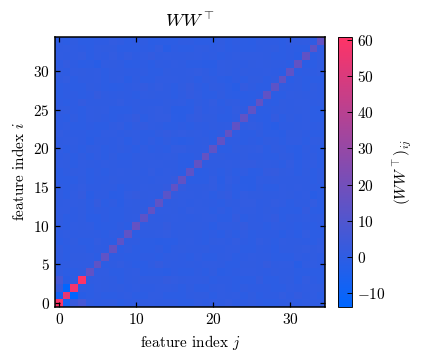

/tmp/ipykernel_1834245/2741477989.py:289: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


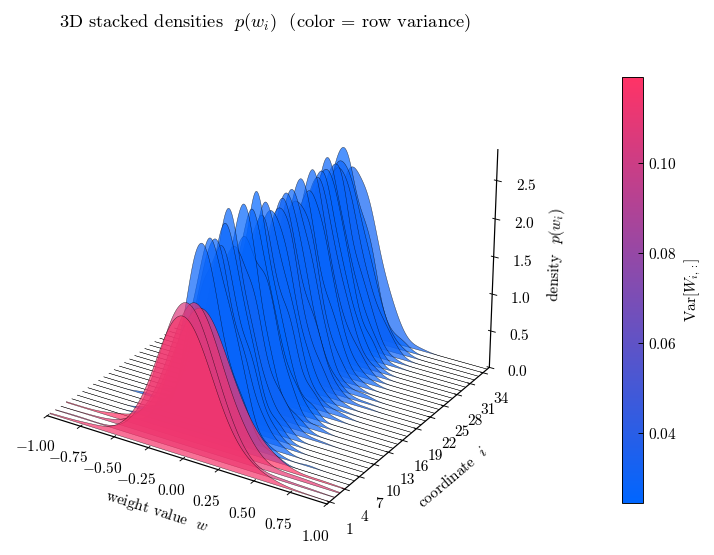

In [ ]:
# === Styled 3D ridgeline for p(w_i) + WW^T heatmap (custom hex gradient, custom vmin/vmax, clean boxed look) ===
import os, sys, glob, math
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------
def import_slim_plotters():
    # Common places to try — add your custom absolute path(s) here if needed
    candidates = [
        "/home/goring/mean_field_langevin/plot_utils",
        "/home/goring/mean_field_langevin/plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]

    # 1) Try direct module path by adding the directory containing slim_plotters.py
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            try:
                import slim_plotters as sp  # noqa
                return sp
            except Exception as e:
                print(f"[note] Found in {d} but import failed: {e!r}")

    # 2) Try package-style imports (requires __init__.py in the folder)
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass

    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
        + " (or update the 'candidates' list above)."
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE

# Apply your theme (switch to theme='dark' if you like)
apply(theme="light", serif=True)

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------
def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")

def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    # Hide the grey panes
    try:
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
    except Exception:
        pass
    # Also kill gridlines via _axinfo (mplot3d internals)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        # Emphasize axis (coordinate) lines
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass
    # Make the surrounding box lines a touch darker
    try:
        ax.w_xaxis.set_pane_color((1, 1, 1, 0))
        ax.w_yaxis.set_pane_color((1, 1, 1, 0))
        ax.w_zaxis.set_pane_color((1, 1, 1, 0))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# Loading helpers
# -----------------------------------------------------------------------------
def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a

# -----------------------------------------------------------------------------
# Minimal 1D Gaussian KDE (no SciPy dependency)
# -----------------------------------------------------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).reshape(-1)
    G = np.asarray(grid, dtype=np.float64).reshape(-1)
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if n == 1:
        bw = 1e-3 if bandwidth is None else float(bandwidth)
    else:
        if bandwidth is None:
            std = np.std(x, ddof=1)
            bw = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
        else:
            bw = float(bandwidth)
        bw = max(bw, 1e-12)
    z = (G[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * bw * math.sqrt(2.0 * math.pi))
    return dens

# -----------------------------------------------------------------------------
# Palette → colormap (customizable with hex stops)
# -----------------------------------------------------------------------------
def linear_cmap_from_hex(stops_hex=None, name="custommap"):
    """
    Build a linear segmented colormap from a list of hex color stops.
    - stops_hex: list like ['#0066ff', '#ff3366'] or with a middle ['#0066ff','#8a3ffc','#ff3366'].
    """
    if stops_hex is None:
        # Default to original palette idea (blue → purple → red) via slim_plotters
        stops_hex = [color("blue"), color("purple"), color("red")]
    return LinearSegmentedColormap.from_list(name, stops_hex, N=256)

# -----------------------------------------------------------------------------
# Styled WW^T heatmap (custom cmap + vmin/vmax + boxed look)
# -----------------------------------------------------------------------------


# -----------------------------------------------------------------------------
# Styled 3D ridgeline for p(w_i) (custom cmap stops + vmin/vmax for variance + boxed look)
# -----------------------------------------------------------------------------
def plot_coordinate_kdes_3d(
    W,
    grid_points=401,
    weight_range=None,
    bandwidth=None,
    normalize_rows=False,   # keep absolute heights to reflect variance
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,           # >1 to thin if d is large
    max_rows=None,
    cmap_stops_hex=None,    # list of hex colors for gradient (start/stop or start/mid/stop)
    var_vmin=None,          # min variance mapped to colormap (if None, computed)
    var_vmax=None           # max variance mapped to colormap (if None, computed)
):
    W_np = W.detach().cpu().numpy()
    d, N = W_np.shape

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # robust symmetric range if not provided
    if weight_range is None:
        abs_vals = np.abs(W_np).ravel()
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)

    grid = np.linspace(lo, hi, grid_points)

    dens, variances = [], []
    for i in rows:
        di = gaussian_kde_1d(W_np[i, :], grid, bandwidth=bandwidth)
        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m
        dens.append(di)
        variances.append(np.var(W_np[i, :], ddof=1))
    dens = np.asarray(dens)
    variances = np.asarray(variances)

    # color by variance using your custom palette
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="varmap")
    vmin_auto, vmax_auto = float(np.min(variances)), float(np.max(variances))
    vmin_use = vmin_auto if var_vmin is None else float(var_vmin)
    vmax_use = vmax_auto if var_vmax is None else float(var_vmax)
    if not np.isfinite(vmin_use): vmin_use = vmin_auto
    if not np.isfinite(vmax_use): vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di, v in zip(dens, variances):
        poly = list(zip(grid, di)) + [(grid[-1], 0.0), (grid[0], 0.0)]
        verts.append(poly)
        facecols.append(cmap(norm(v)))

    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )

    fig = plt.figure(figsize=(10.0, 6.0))
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')
    ys = np.arange(len(rows)) * y_step
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens)) if dens.size else 1.0
    ax.set_zlim(0.0, zmax * 1.05)

    # labels/ticks (styled by your rcParams)
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(r"density  $p(w_i)$")
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$")

    # Clean boxed style (no grey panes, no grid; keep coordinate lines)
    style_3d_axes_box(ax)

    ax.set_title("3D stacked densities  $p(w_i)$  (color = row variance)")
    plt.tight_layout()
    plt.show()
    return fig

# -----------------------------------------------------------------------------
# Usage
# -----------------------------------------------------------------------------
# Option A: direct .pt file (set to your path) OR leave None and use Option B
MODEL_FILE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"

# Option B: newest final_model_*.pt in this directory
MODEL_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"

if not MODEL_FILE:
    MODEL_FILE = find_latest_model(MODEL_DIR, prefix="final_model_", ext=".pt")

print("Loading:", MODEL_FILE)
W, a = load_WA_from_state_dict(MODEL_FILE)
print("W shape:", tuple(W.shape))

# ---- Customize your colors & ranges here ----
# Example: start/stop hex for both plots (you can add a middle color if you like)
CMAP_STOPS = ["#FD0139", "#0E26C4"]       # or e.g. ["#0066ff", "#8a3ffc", "#ff3366"]

# Heatmap value range (colorbar); set to None to auto scale
HEAT_VMIN = None
HEAT_VMAX = None

# Ridgeline variance → color mapping; set to None to auto scale
VAR_VMIN = None
VAR_VMAX = None

# 1) WW^T heatmap

# 2) 3D ridgeline for p(w_i)
_ = plot_coordinate_kdes_3d(
    W,
    grid_points=4001,
    weight_range=(-1, 1),     # or set a fixed range like (-0.6, 0.6)
    bandwidth=None,           # Scott's rule per row
    normalize_rows=False,     # keep absolute heights to reflect variance
    y_step=0.85,
    alpha=0.7,
    elev=26,
    azim=-58,
    row_stride=1,             # use 2/3/... to thin if d is large
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    var_vmin=VAR_VMIN,
    var_vmax=VAR_VMAX
)


Loading: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt
W shape: (35, 512)


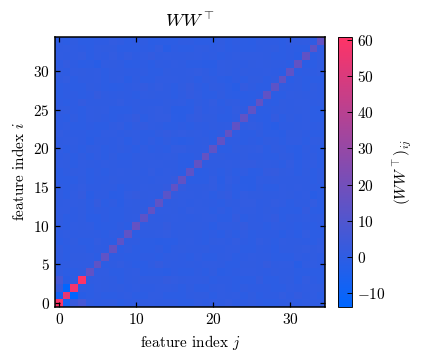

/tmp/ipykernel_1834245/1452630123.py:293: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


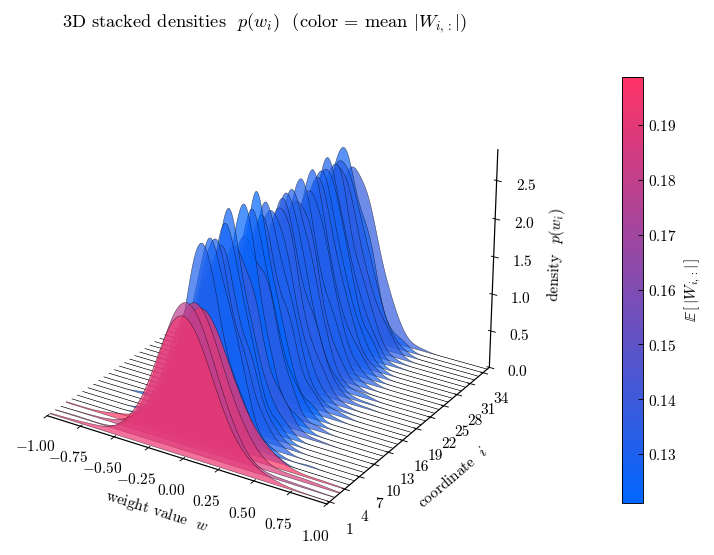

In [3]:
# === Styled 3D ridgeline for p(w_i) + WW^T heatmap
#     (color = mean |W_{i,:}| with custom hex gradient + manual vmin/vmax, clean boxed look) ===
import os, sys, glob, math
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------------------------------------------------------
# Rationale
# -----------------------------------------------------------------------------
# We color each ridgeline (row i of W) by the mean weight magnitude:
#     mean_abs_i = E_j[ |W_{i j}| ]
# This is a direct, intuitive measure of feature/coordinate importance.
# (Variance is closely related, but mean |.| is often easier to interpret and
# less sensitive to outliers.)

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------
def import_slim_plotters():
    # Common places to try — add your custom absolute path(s) here if needed
    candidates = [
        "/home/goring/mean_field_langevin/plot_utils",
        "/home/goring/mean_field_langevin/plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]

    # 1) Try direct module path by adding the directory containing slim_plotters.py
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            try:
                import slim_plotters as sp  # noqa
                return sp
            except Exception as e:
                print(f"[note] Found in {d} but import failed: {e!r}")

    # 2) Try package-style imports (requires __init__.py in the folder)
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass

    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
        + " (or update the 'candidates' list above)."
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE

# Apply your theme (switch to theme='dark' if you like)
apply(theme="light", serif=True)

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------
def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")

def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    # Hide grey panes
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis.pane.set_visible(False)
        except Exception:
            pass
        # Kill gridlines via internals
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        # Emphasize axis (coordinate) lines
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass

# -----------------------------------------------------------------------------
# Loading helpers
# -----------------------------------------------------------------------------
def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a

# -----------------------------------------------------------------------------
# Minimal 1D Gaussian KDE (no SciPy dependency)
# -----------------------------------------------------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).reshape(-1)
    G = np.asarray(grid, dtype=np.float64).reshape(-1)
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if n == 1:
        bw = 1e-3 if bandwidth is None else float(bandwidth)
    else:
        if bandwidth is None:
            std = np.std(x, ddof=1)
            bw = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
        else:
            bw = float(bandwidth)
        bw = max(bw, 1e-12)
    z = (G[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * bw * math.sqrt(2.0 * math.pi))
    return dens

# -----------------------------------------------------------------------------
# Palette → colormap (customizable with hex stops)
# -----------------------------------------------------------------------------
def linear_cmap_from_hex(stops_hex=None, name="custommap"):
    """
    Build a linear segmented colormap from a list of hex color stops.
    - stops_hex: list like ['#0066ff', '#ff3366'] or with a middle ['#0066ff','#8a3ffc','#ff3366'].
    """
    if stops_hex is None:
        # Default to original palette idea (blue → purple → red) via slim_plotters
        stops_hex = [color("blue"), color("purple"), color("red")]
    return LinearSegmentedColormap.from_list(name, stops_hex, N=256)

# -----------------------------------------------------------------------------
# Styled WW^T heatmap (custom cmap + vmin/vmax + boxed look)
# -----------------------------------------------------------------------------
def plot_WWT_heatmap(W, cmap_stops_hex=None, vmin=None, vmax=None):
    C = (W @ W.T).detach().cpu().numpy()
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="heatmapmap")

    fig, ax = plt.subplots(figsize=(4.0, 3.4))
    fig.patch.set_facecolor("white")

    im = ax.imshow(C, origin="lower", aspect="equal", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(r"$W W^\top$")
    ax.set_xlabel("feature index $j$")
    ax.set_ylabel("feature index $i$")

    style_axes_box(ax)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$(WW^\top)_{ij}$")

    plt.tight_layout()
    plt.show()
    return fig

# -----------------------------------------------------------------------------
# Styled 3D ridgeline for p(w_i)
#   - color by mean weight magnitude per row:  mean_abs_i = E_j[ |W_{i j}| ]
#   - customizable cmap stops (hex) and manual vmin/vmax for color mapping
# -----------------------------------------------------------------------------
def plot_coordinate_kdes_3d(
    W,
    grid_points=401,
    weight_range=None,
    bandwidth=None,
    normalize_rows=False,   # keep absolute heights to reflect spread
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,           # >1 to thin if d is large
    max_rows=None,
    cmap_stops_hex=None,    # list of hex colors for gradient (start/stop or start/mid/stop)
    mag_vmin=None,          # min mean-|.| mapped to colormap (if None, computed)
    mag_vmax=None           # max mean-|.| mapped to colormap (if None, computed)
):
    W_np = W.detach().cpu().numpy()
    d, N = W_np.shape

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # robust symmetric range if not provided
    if weight_range is None:
        abs_vals = np.abs(W_np).ravel()
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)

    grid = np.linspace(lo, hi, grid_points)

    dens, mean_abs_vals = [], []
    for i in rows:
        di = gaussian_kde_1d(W_np[i, :], grid, bandwidth=bandwidth)
        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m
        dens.append(di)
        mean_abs_vals.append(np.mean(np.abs(W_np[i, :])))

    dens = np.asarray(dens)
    mean_abs_vals = np.asarray(mean_abs_vals, dtype=float)

    # Color by mean |W_{i,:}|
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="meanmagmap")
    auto_min, auto_max = float(np.min(mean_abs_vals)), float(np.max(mean_abs_vals))
    vmin_use = auto_min if mag_vmin is None else float(mag_vmin)
    vmax_use = auto_max if mag_vmax is None else float(mag_vmax)
    if not np.isfinite(vmin_use): vmin_use = auto_min
    if not np.isfinite(vmax_use): vmax_use = auto_max
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di, mabs in zip(dens, mean_abs_vals):
        poly = list(zip(grid, di)) + [(grid[-1], 0.0), (grid[0], 0.0)]
        verts.append(poly)
        facecols.append(cmap(norm(mabs)))

    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )

    fig = plt.figure(figsize=(10.0, 6.0))
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')
    ys = np.arange(len(rows)) * y_step
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens)) if dens.size else 1.0
    ax.set_zlim(0.0, zmax * 1.05)

    # labels/ticks (styled by your rcParams)
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(r"density  $p(w_i)$")
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # colorbar for mean |W_{i,:}|
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathbb{E}\,[\,|W_{i,:}|\,]$")

    # Clean boxed style (no grey panes, no grid; keep coordinate lines)
    style_3d_axes_box(ax)

    ax.set_title("3D stacked densities  $p(w_i)$  (color = mean $|W_{i,:}|$)")
    plt.tight_layout()
    plt.show()
    return fig

# -----------------------------------------------------------------------------
# Usage
# -----------------------------------------------------------------------------
# Option A: direct .pt file (set to your path) OR leave None and use Option B
MODEL_FILE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"

# Option B: newest final_model_*.pt in this directory
MODEL_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"

if not MODEL_FILE:
    MODEL_FILE = find_latest_model(MODEL_DIR, prefix="final_model_", ext=".pt")

print("Loading:", MODEL_FILE)
W, a = load_WA_from_state_dict(MODEL_FILE)
print("W shape:", tuple(W.shape))

# ---- Customize your colors & ranges here ----
# Example: start/stop hex for both plots (you can add a middle color if you like)
CMAP_STOPS = ["#0066ff", "#ff3366"]       # or e.g. ["#0066ff", "#8a3ffc", "#ff3366"]

# Heatmap value range (colorbar); set to None to auto scale
HEAT_VMIN = None
HEAT_VMAX = None

# Ridgeline color mapping range for mean |W_{i,:}|; set to None to auto scale
MAG_VMIN = None
MAG_VMAX = None

# 1) WW^T heatmap
_ = plot_WWT_heatmap(W, cmap_stops_hex=CMAP_STOPS, vmin=HEAT_VMIN, vmax=HEAT_VMAX)

# 2) 3D ridgeline for p(w_i) with color = mean |W_{i,:}|
_ = plot_coordinate_kdes_3d(
    W,
    grid_points=4001,
    weight_range=(-1, 1),     # or set a fixed range like (-0.6, 0.6)
    bandwidth=None,           # Scott's rule per row
    normalize_rows=False,     # keep absolute heights to reflect spread
    y_step=0.85,
    alpha=0.7,
    elev=26,
    azim=-58,
    row_stride=1,             # use 2/3/... to thin if d is large
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    mag_vmin=MAG_VMIN,
    mag_vmax=MAG_VMAX
)


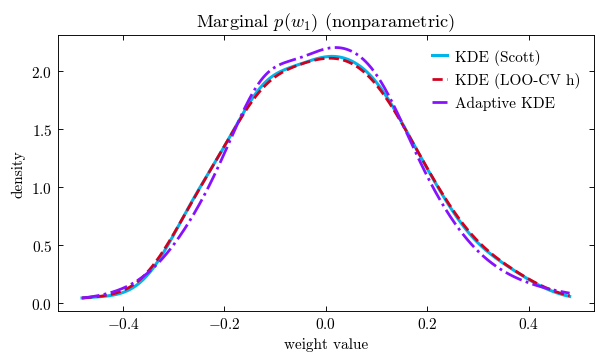

In [4]:
import numpy as np, math
import torch, matplotlib.pyplot as plt

# ---------- Utilities ----------
def freedman_diaconis_bin_width(x):
    x = np.ravel(np.asarray(x, dtype=float))
    n = x.size
    if n < 2:
        return 1.0
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    if iqr <= 0:
        iqr = np.std(x, ddof=1)
    if iqr <= 0:
        return 1.0
    return 2 * iqr * n ** (-1/3)

def gaussian_kernel(z):
    return np.exp(-0.5 * z * z) / math.sqrt(2.0 * math.pi)

# ---------- Fixed-bandwidth Gaussian KDE ----------
def kde_fixed(x, grid, bandwidth=None):
    x = np.ravel(np.asarray(x, float))
    grid = np.ravel(np.asarray(grid, float))
    n = x.size
    if n == 0:
        return np.zeros_like(grid)
    if bandwidth is None:
        std = np.std(x, ddof=1)
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    bandwidth = max(float(bandwidth), 1e-12)
    z = (grid[:, None] - x[None, :]) / bandwidth
    dens = gaussian_kernel(z).sum(axis=1) / (n * bandwidth)
    return dens

# ---------- LOO-CV bandwidth selection for Gaussian KDE ----------
def kde_loocv_opt_bandwidth(x, h_grid=None):
    x = np.ravel(np.asarray(x, float))
    n = x.size
    if n < 3:
        return 0.1
    std = np.std(x, ddof=1)
    h_scott = 1.06 * std * n ** (-1/5) if std > 0 else np.ptp(x) / (1.34 * n ** (1/5) + 1e-9)
    if h_scott <= 0 or not np.isfinite(h_scott):
        h_scott = max(1e-3, np.median(np.abs(x - np.median(x))) / 0.6745 * n ** (-1/5))
    if h_grid is None:
        h_grid = np.geomspace(0.25*h_scott, 4.0*h_scott, 25)

    X = x[:, None]
    best_h, best_ll = None, -np.inf
    for h in h_grid:
        if not np.isfinite(h) or h <= 0:
            continue
        Z = (X - X.T) / h                           # (n,n)
        K = gaussian_kernel(Z)                      # kernel matrix
        np.fill_diagonal(K, 0.0)                    # leave-one-out
        f_loo = K.sum(axis=1) / ((n - 1) * h)       # (n,)
        f_loo = np.clip(f_loo, 1e-300, None)
        ll = np.log(f_loo).sum()
        if ll > best_ll:
            best_ll, best_h = ll, h
    return float(best_h)

# ---------- Adaptive KDE (Abramson’s square-root law) ----------
def kde_adaptive(x, grid, h0=None, clip_lambda=(0.3, 3.0)):
    """
    Sample-point adaptive KDE:
      1) pilot density with bandwidth h0 (Scott if None)
      2) λ_i = sqrt(g / f_pilot(x_i)) with g = geometric mean of pilot densities
      3) f(x) = (1/n) Σ (1/(h0 λ_i)) K( (x - x_i)/(h0 λ_i) )
    """
    x = np.ravel(np.asarray(x, float))
    grid = np.ravel(np.asarray(grid, float))
    n = x.size
    if n == 0:
        return np.zeros_like(grid)
    if n == 1:
        h0 = 1e-3 if h0 is None else float(h0)
        return kde_fixed(x, grid, bandwidth=h0)

    # Pilot bandwidth
    if h0 is None:
        std = np.std(x, ddof=1)
        h0 = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h0 = max(float(h0), 1e-12)

    # Pilot LOO densities at sample points (reduces bias)
    X = x[:, None]
    Z = (X - X.T) / h0
    K = gaussian_kernel(Z)
    np.fill_diagonal(K, 0.0)
    f0 = K.sum(axis=1) / ((n - 1) * h0)
    f0 = np.clip(f0, 1e-300, None)

    # Local bandwidth factors
    g = math.exp(np.log(f0).mean())  # geometric mean
    lam = np.sqrt(g / f0)
    if clip_lambda is not None:
        lam = np.clip(lam, clip_lambda[0], clip_lambda[1])
    h_i = h0 * lam  # (n,)

    # Evaluate adaptive KDE on grid
    dens = np.zeros_like(grid, float)
    for xi, hi in zip(x, h_i):
        z = (grid - xi) / hi
        dens += gaussian_kernel(z) / hi
    dens /= n
    return dens

# ---------- Marginal p(w_i) wrappers ----------
def make_grid_from_W(W, grid_points=501, weight_range=None):
    W_np = W.detach().cpu().numpy()
    if weight_range is None:
        a = np.abs(W_np).ravel()
        hi = float(np.quantile(a, 0.995)) if a.size else 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    return np.linspace(lo, hi, grid_points)

def p_wi(W, i, grid=None, method="akde", bandwidth=None):
    """
    Estimate marginal p(w_i) from samples W[i,:].
    method: 'kde' (fixed), 'kde_cv' (LOO-selected h), 'akde' (adaptive).
    """
    Wi = W[i, :].detach().cpu().numpy()
    if grid is None:
        grid = make_grid_from_W(W)
    if method == "kde":
        return grid, kde_fixed(Wi, grid, bandwidth)
    elif method == "kde_cv":
        h = kde_loocv_opt_bandwidth(Wi) if bandwidth is None else bandwidth
        return grid, kde_fixed(Wi, grid, h)
    elif method == "akde":
        # use CV pilot if bandwidth is None
        h0 = kde_loocv_opt_bandwidth(Wi) if bandwidth is None else bandwidth
        return grid, kde_adaptive(Wi, grid, h0)
    else:
        raise ValueError("method must be one of {'kde','kde_cv','akde'}")

# ---------- Quick demo (set W beforehand) ----------
# Example: compare estimates for a single coordinate i0
def demo_single_coordinate(W, i0=0, grid_points=601):
    grid = make_grid_from_W(W, grid_points=grid_points)
    g_kde,  f_kde  = p_wi(W, i0, grid=grid, method="kde")
    g_cv,   f_cv   = p_wi(W, i0, grid=grid, method="kde_cv")
    g_akde, f_akde = p_wi(W, i0, grid=grid, method="akde")

    plt.figure(figsize=(5.6, 3.4))
    plt.plot(g_kde,  f_kde,  lw=2.0, label="KDE (Scott)")
    plt.plot(g_cv,   f_cv,   lw=1.8, ls="--", label="KDE (LOO-CV h)")
    plt.plot(g_akde, f_akde, lw=1.8, ls="-.", label="Adaptive KDE")
    plt.title(fr"Marginal $p(w_{{{i0+1}}})$ (nonparametric)")
    plt.xlabel("weight value")
    plt.ylabel("density")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# Uncomment after you've defined/loaded W:
demo_single_coordinate(W, i0=0)


Loading: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_5000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt
Shapes: {'W': torch.Size([35, 512]), 'a': torch.Size([512])}


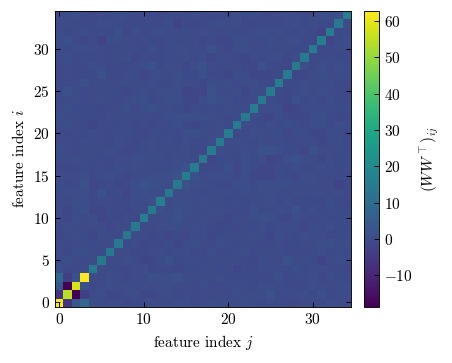

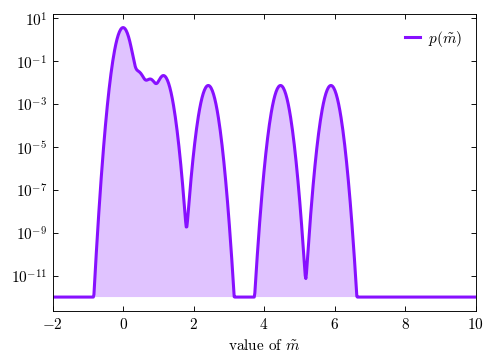

In [22]:
# === WW^T heatmap + unconditional p(m~ = a * J_S(w)) with slim-style controls ===
import os, sys, glob, math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ----------------------------------------------------------------------------- #
# robust import of your slim_plotters.py
# ----------------------------------------------------------------------------- #
def import_slim_plotters():
    candidates = [
        "/home/goring/mean_field_langevin/plot_utils",
        "/home/goring/mean_field_langevin/plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            import slim_plotters as sp
            return sp
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass
    raise ModuleNotFoundError("slim_plotters.py not found — update candidate paths above.")

sp = import_slim_plotters()
apply, color, COLORS = sp.apply, sp.color, sp.COLORS
apply(theme="light", serif=True)  # or theme="dark"

# ----------------------------------------------------------------------------- #
# IO helpers
# ----------------------------------------------------------------------------- #
def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach()
        a = sd['a'].detach()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach()
        a = st['a'].detach()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach()
        a = sd[key_a].detach()
    if a.ndim > 1:
        a = a.view(-1)
    return W.float().cpu(), a.float().cpu()

# ----------------------------------------------------------------------------- #
# Monte Carlo estimator for J_S(w) (S = {0,1,2,3} by default)
# ----------------------------------------------------------------------------- #
@torch.no_grad()
def estimate_JS_for_all_neurons(W, S=(0,1,2,3), num_samples=200_000, batch_size=100_000,
                                device=None, seed=123):
    d, N = W.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(seed)
    Wd = W.to(device, non_blocking=True)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0
    B, P = batch_size, num_samples
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True)   # (b,1)
        Z = F.relu(X @ Wd)                              # (b,N)
        accum += (Z * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------------------------------------------------------- #
# Simple Gaussian KDE (no SciPy)
# ----------------------------------------------------------------------------- #
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1)
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens

# ----------------------------------------------------------------------------- #
# Plot 1: WW^T heatmap (unchanged)
# ----------------------------------------------------------------------------- #
def plot_WWT_heatmap(W):
    C = (W @ W.T).detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(4.0, 3.4))
    im = ax.imshow(C, origin="lower", aspect="equal")
    ax.set_xlabel("feature index $j$")
    ax.set_ylabel("feature index $i$")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$(WW^\top)_{ij}$")
    plt.tight_layout()
    plt.show()
    return fig

# ----------------------------------------------------------------------------- #
# Plot 2: SAME as your good one, but with style controls (hex color, aspect, ranges)
# - x is linear
# - y is log (semilogy)
# - filled area to a positive floor (for log)
# - no title by default; ticks inward on all sides
# ----------------------------------------------------------------------------- #
def plot_mtilde_distribution_styled(
    a, JS, *,
    grid_points=801,
    weight_range=None,         # (lo, hi) or None for robust auto
    color_hex="#8710FF",       # curve/fill color (hex)
    linewidth=2.0,
    fill_alpha=0.25,
    density_floor=1e-12,       # positive baseline for log fill
    show_legend=True,
    legend_label=r"$p(\tilde m)$",
    width=4.6,
    aspect=4.6/3.4,            # width / height
    x_range=None,
    y_range=None,
    show_title=False           # keep False to match your “no title”
):
    a_np  = a.detach().cpu().numpy().ravel()
    JS_np = JS.detach().cpu().numpy().ravel()
    mtilde = a_np * JS_np

    # grid (linear x)
    if weight_range is None:
        all_abs = np.abs(mtilde)
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max()))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    # KDE and log-safe clipping
    dens = gaussian_kde_1d(mtilde, grid)
    dens = np.clip(dens, density_floor, None)

    # figure with your rcParams
    fig, ax = plt.subplots(figsize=(width, width / aspect))
    ax.semilogy(grid, dens, color=color_hex, lw=linewidth, label=legend_label)
    ax.fill_between(grid, dens, density_floor, color=color_hex, alpha=fill_alpha, linewidth=0)

    # style: no title, inward ticks on all sides
    if show_title:
        ax.set_title(r"Distribution of $\tilde m = a\,J_S(w)$ across neurons")
    else:
        ax.set_title("")
    ax.tick_params(which='both', direction='in', top=True, right=True)

    ax.set_xlabel(r"value of $\tilde m$")
    ax.set_ylabel("")  # remove y-label to keep clean; log ticks still visible

    if show_legend:
        ax.legend(frameon=False, loc="upper right")

    if x_range is not None:
        ax.set_xlim(x_range)
    if y_range is not None:
        ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()
    return fig

# ----------------------------------------------------------------------------- #
# === Usage ===
# ----------------------------------------------------------------------------- #
MODEL_FILE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_5000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
MODEL_DIR  = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"
if not MODEL_FILE:
    MODEL_FILE = find_latest_model(MODEL_DIR, prefix="final_model_", ext=".pt")

print("Loading:", MODEL_FILE)
W, a = load_WA_from_state_dict(MODEL_FILE)
print("Shapes:", dict(W=W.shape, a=a.shape))

# 1) WW^T heatmap (optional)
_ = plot_WWT_heatmap(W)

# 2) J_S and p(mtilde) with your preferred style
JS = estimate_JS_for_all_neurons(
    W, S=(0,1,2,3),
    num_samples=200_000,
    batch_size=100_000,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=123
)

_ = plot_mtilde_distribution_styled(
    a, JS,
    grid_points=1801,
    weight_range=(-15.5, 15.5),          # or e.g. (-2.5, 2.5)
    color_hex="#8710FF",
    linewidth=2.0,
    fill_alpha=0.25,
    density_floor=1e-12,
    show_legend=True,
    legend_label=r"$p(\tilde m)$",
    width=4.6, aspect=1.35,     # pick your aspect ratio
    x_range=(-2,10),               # e.g. (-1.5, 2.8)
    y_range=None,               # e.g. (1e-12, 1e+1) on log scale
    show_title=False
)


Loading A: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_100_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt
Loading B: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt


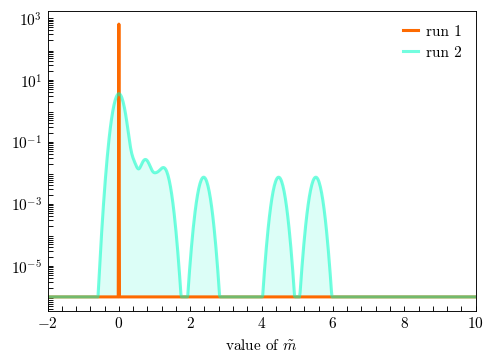

In [1]:
# === WW^T heatmap + unconditional p(m~ = a * J_S(w)) with slim-style controls (TWO MODELS overlay) ===
import os, sys, glob, math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ----------------------------------------------------------------------------- #
# robust import of your slim_plotters.py
# ----------------------------------------------------------------------------- #
def import_slim_plotters():
    candidates = [
        "/home/goring/mean_field_langevin/plot_utils",
        "/home/goring/mean_field_langevin/plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            import slim_plotters as sp
            return sp
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass
    raise ModuleNotFoundError("slim_plotters.py not found — update candidate paths above.")

sp = import_slim_plotters()
apply, color, COLORS = sp.apply, sp.color, sp.COLORS
apply(theme="light", serif=True)  # or theme="dark"

# ----------------------------------------------------------------------------- #
# IO helpers
# ----------------------------------------------------------------------------- #
def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach()
        a = sd['a'].detach()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach()
        a = st['a'].detach()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach()
        a = sd[key_a].detach()
    if a.ndim > 1:
        a = a.view(-1)
    return W.float().cpu(), a.float().cpu()

# ----------------------------------------------------------------------------- #
# Monte Carlo estimator for J_S(w) (S = {0,1,2,3} by default)
# ----------------------------------------------------------------------------- #
@torch.no_grad()
def estimate_JS_for_all_neurons(W, S=(0,1,2,3), num_samples=200_000, batch_size=100_000,
                                device=None, seed=123):
    d, N = W.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(seed)
    Wd = W.to(device, non_blocking=True)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0
    B, P = batch_size, num_samples
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True)   # (b,1)
        Z = F.relu(X @ Wd)                              # (b,N)
        accum += (Z * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------------------------------------------------------- #
# Simple Gaussian KDE (no SciPy)
# ----------------------------------------------------------------------------- #
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1)
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens



# ----------------------------------------------------------------------------- #
# Plot 2 (SINGLE model): unchanged styled version
# ----------------------------------------------------------------------------- #
# Drop-in replacement: two-model overlay WITH MINOR TICKS on x (linear) and y (log)
# Drop-in replacement: two-model overlay with minor ticks ONLY bottom/left
def plot_mtilde_distribution_two_models(
    a1, JS1, a2, JS2, *,
    grid_points=801,
    weight_range=None,         # (lo, hi) or None (auto from both)
    color_hex1="#8710FF",      # color for model 1
    color_hex2="#01B5EB",      # color for model 2
    alpha1=1.0, alpha2=0.55,   # opacity only
    linewidth=2.0,
    fill_alpha_scale=0.25,     # fill alpha = alpha*fill_alpha_scale
    density_floor=1e-12,
    label1="run 1", label2="run 2",
    width=4.6, aspect=1.35,
    x_range=None, y_range=None
):
    import numpy as np
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    m1 = a1.detach().cpu().numpy().ravel() * JS1.detach().cpu().numpy().ravel()
    m2 = a2.detach().cpu().numpy().ravel() * JS2.detach().cpu().numpy().ravel()

    if weight_range is None:
        all_abs = np.abs(np.concatenate([m1, m2]))
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0: hi = max(1.0, float(all_abs.max()))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    p1 = np.clip(gaussian_kde_1d(m1, grid), density_floor, None)
    p2 = np.clip(gaussian_kde_1d(m2, grid), density_floor, None)

    fig, ax = plt.subplots(figsize=(width, width / aspect))
    # curves + fill
    ax.semilogy(grid, p1, color=color_hex1, lw=linewidth, alpha=alpha1, label=label1)
    ax.fill_between(grid, p1, density_floor, color=color_hex1, alpha=alpha1*fill_alpha_scale, linewidth=0)

    ax.semilogy(grid, p2, color=color_hex2, lw=linewidth, alpha=alpha2, label=label2)
    ax.fill_between(grid, p2, density_floor, color=color_hex2, alpha=alpha2*fill_alpha_scale, linewidth=0)

    # labels & legend
    ax.set_title("")
    ax.set_xlabel(r"value of $\tilde m$")
    ax.set_ylabel("")
    ax.legend(frameon=False, loc="upper right")

    # ---- MINOR TICKS: only bottom & left ----
    # linear x minors
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    # log y minors (2..9)
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())

    # ticks bottom/left only (no top/right)
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)  # shorter minor ticks

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()
    return fig




# ----------------------------------------------------------------------------- #
# === Usage ===
# ----------------------------------------------------------------------------- #
MODEL_A = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_100_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
MODEL_B = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"

print("Loading A:", MODEL_A)
WA, aA = load_WA_from_state_dict(MODEL_A)
print("Loading B:", MODEL_B)
WB, aB = load_WA_from_state_dict(MODEL_B)

# optional: heatmap for one model

JS_A = estimate_JS_for_all_neurons(WA, S=(0,1,2,3), num_samples=500_000, batch_size=100_000,
                                   device="cuda" if torch.cuda.is_available() else "cpu", seed=123)
JS_B = estimate_JS_for_all_neurons(WB, S=(0,1,2,3), num_samples=200_000, batch_size=100_000,
                                   device="cuda" if torch.cuda.is_available() else "cpu", seed=124)
_ = plot_mtilde_distribution_two_models(
    aA, JS_A, aB, JS_B,
    grid_points=1801,
    weight_range=(-15.5, 15.5),   # or None
    color_hex1="#FD6A01",         # purple for run 1
    color_hex2="#01FDC5",         # blue for run 2
    alpha1=1.0, alpha2=0.55,
    linewidth=2.0,
    fill_alpha_scale=0.25,
    density_floor=1e-6,
    label1="run 1", label2="run 2",
    width=4.6, aspect=1.35,
    x_range=(-2, 10),             # or None
    y_range=None
)



Loading MF snapshot A: /home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__init_particles.pt
Loading MF snapshot B: /home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__init_particles.pt


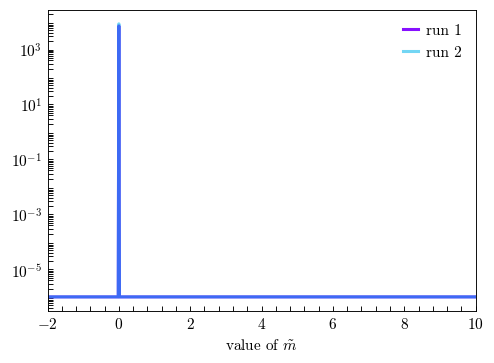